#Churn Problem of Maastricht Telecom

# Intro: Churn Problem of Maastricht Telecom

The problem of churn is a problem when a number of individuals move out of a collective group. It is one of the main problems that determine the steady-state level of customers in any type of business.

Recently a large number of customers has left Maastricht Telecom. To address this problem Maastricht Telecom provides customer data to solve two important tasks:

1. Descriptive task: Characterize loyal and churn customers and propose a focused customer retention program. (This can be done through visualization, descriptive models etc. )

2. Predictive task: Find a model that identifies churn customers. Then:
  * Select 300 customers using that model from a separate test set and report the number of true churn customers among them.
  * Calculate the expected costs for Maastricht Telecom for one month when using your model on the test set if:
    * every customer predicted as churn will get a gift of 10 euro and
    * every true churn customer predicted as loyal will cause a loss of 64 euros (an average month subscription).

---
---

<!-- [My Self Evaluation]() -->

[My Drive for the LAB](https://drive.google.com/drive/folders/1al3qykmDlTaBGZBJxPlRKZ8POdKWpY1G?usp=sharing)

---
---


# Data

The data consists of two files: churn-train.csv and churn-test.csv. The first data churn-train.csv you can use to train and validate your classification models. Once you have selected the best model you can test it using the second data churn-test.csv. (Do not use in any way churn-test.csv for training your classification models).

The data is represented by types of variables:

**A. Demographic info about customers**:
* gender,
* Senior Citizen (age range < 67) ,
* Partner (yes, no),
* Dependents (yes, no).

**B. Customer account information**:
* tenure (how long they've been a customer in months),
* Contract (month, year, 2 years),
* Paperless Billing (yes, no),
* Payment Method (electronic check, mailed check, bank transfer, credit card),
* Monthly Charges (in euros),
* Total Charges (in euros).

**C. Services that each customer has signed up for**:
* Phone Service (yes, no),
* Multiple Lines (no phone service, yes, no)
* Internet Service (no, DSL, Fiber Optic)
* Online Security (no Internet service, yes, no)
* Online Backup (no Internet service, yes, no)
* Device Protection (no Internet service, yes, no),
* Tech Support (no Internet service, yes, no)
* Streaming TV (no Internet service, yes, no)
* Streaming Movies (no Internet service, yes, no)

**D. Customers who left within the last month**:
* Churn (yes, no)

# 1. Notebook Preparation

## 1.1 Necessary imports, filepaths and functions

In [ ]:
####################################
####### IMPORTS & INSTALLS #########
####################################

# !pip install -q ydata-profiling
# !pip install -U -q dataprep
!pip install -q nbconvert pdfkit
!apt-get install -q wkhtmltopdf

# Standard library imports
import os
import logging
# import IPython
import warnings
import itertools
from collections import Counter

# Basic
import math
import numpy as np
import pandas as pd
from pandas.plotting import table

# EDA Libraries
# from ydata_profiling import ProfileReport
# from dataprep.eda import create_report
# from dataprep.eda import plot
# from dataprep.eda import plot_correlation


# Visuals
import matplotlib.pyplot as plt
import seaborn as sns

# Imblearn
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as imPipeline, make_pipeline as make_pipeline_imb
from imblearn.under_sampling import RandomUnderSampler

# Sklearn
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.feature_selection import RFE, SelectKBest, chi2, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, auc, classification_report, confusion_matrix,
                             f1_score, make_scorer, precision_score, recall_score,
                             roc_auc_score, roc_curve)
from sklearn.model_selection import (GridSearchCV, RandomizedSearchCV, StratifiedKFold,
                                     learning_curve, train_test_split, validation_curve)
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.utils import resample

# Google Colab imports
from google.colab import drive

# PDF
import pdfkit

#======================================================================================================

####################################
############# SETUPS ###############
####################################

# Mount drive
drive.mount('/content/drive'
            , force_remount=True
            )

# Setting pandas option - uncomment if you need to display maximum columns
# pd.set_option('display.max_columns', None)

# Ignore warnings
warnings.filterwarnings("ignore")

# Sns setup
sns.color_palette("rocket", as_cmap=True)
sns.set_style("whitegrid")
#======================================================================================================

####################################
########### FILE PATHS #############
####################################

main_directory_path = "./drive/MyDrive/Assignment_DM/LAB_Resit/"                  # To set a main path
data_path = main_directory_path + "Dataset/"                                      # To load the datasets
images_path = main_directory_path + "Images/"                                     # To save the figures

Reading package lists...
Building dependency tree...
Reading state information...
wkhtmltopdf is already the newest version (0.12.6-2).
0 upgraded, 0 newly installed, 0 to remove and 30 not upgraded.
Mounted at /content/drive


## 1.2 My Functions

Function to save plots to my google drive

In [ ]:
def save_figure(title, path=images_path):
  file_path = os.path.join(path, title)
  if not os.path.exists(path):
    os.makedirs(path)
  plt.savefig(file_path)

Function to check for unique values

In [ ]:
def uniquevalues(dataframe):
  for col in dataframe.columns:
    unique_values = dataframe[col].unique()
    data_type = dataframe[col].dtype
    print(f"Column: {col}\n  Unique Values: {unique_values}\n  Data Type: {data_type}\n")

Function to plot the Histograms and Bars of the sets compared with 0s and 1s of Churn.

In [ ]:
def plot_histo_bars(df, extra='nodummies'):
    for column in df.columns:
        if column == 'Churn':
            continue

        plt.figure(figsize=(10, 6))

        if df[column].dtype == 'object' or df[column].nunique() < 10:
            sns.countplot(data=df, x=column, hue='Churn', palette='rocket')
            plt.title(f'Count of Categories in {column} by Churn')
        else:
            sns.histplot(data=df, x=column, hue='Churn', kde=True, palette='rocket', bins=60)
            plt.title(f'Distribution for {column} by Churn')

        plt.xlabel(column)
        plt.ylabel('Count')

        if df[column].dtype == 'object' or df[column].nunique() < 10:
            for p in plt.gca().patches:
                plt.text(p.get_x() + p.get_width() / 2., p.get_height(), f'{int(p.get_height())}',
                         ha='center', va='bottom')

        save_figure(f"Histogram_{extra}_{column}")
        plt.show()

Plot model's importance or coefficients of features and the tree if the model is Decision tree.

In [ ]:
def model_important_features(model_name, model, X):
    if model_name == "logistic_regression":
        feature_importances = model.coef_[0]
    elif model_name == "decision_tree":
        feature_importances = model.feature_importances_

        #Plot tree
        plt.figure(figsize=(40, 40))
        plot_tree(model, filled=True, feature_names=X.columns[0:85], class_names=str(y_train_reshaped), fontsize=10)

        plt.title(f'Decision Tree for Churn\n')

        save_figure(f"{model_name}_churn.png")
        plt.show()

    features_df = pd.DataFrame({
        'Feature': X.columns[0:85],
        'Importance': feature_importances
    })

    sorted_features_df = features_df.sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(10, 14))
    sorted_features_df.set_index('Feature')['Importance'].plot(kind='barh')

    plt.title(f'{model_name} Feature Importances/Coef for CARAVAN')
    plt.xlabel('Value')
    plt.ylabel('Feature')

    plt.grid(axis='x')
    plt.tight_layout()

    save_figure(f"{model_name}_feature_importances_churn.png")
    plt.show()

The evaluation of this model for the validation set.

In [ ]:
def model_metrics(model_name, model, X_val, y_val_reshaped):

    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)[:, 1]

    print(f'Model: {model_name}')
    print(classification_report(y_val_reshaped, y_pred, target_names=['0', '1']))

    fpr, tpr, _ = roc_curve(y_val_reshaped, y_prob)
    plt.figure()
    plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc_score(y_val_reshaped, y_prob):.2f})')
    plt.plot([0, 1], [0, 1], color='navy', linestyle='--')

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])

    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Receiver Operating Characteristic (ROC) Curve for {model_name}')
    plt.legend(loc="lower right")

    save_figure(f"{model_name}_ROC_AUC.png")
    plt.show()


    conf_matrix = confusion_matrix(y_val_reshaped, y_pred)

    plt.figure(figsize=(6, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap=plt.cm.Blues,
                xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])

    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title(f'Confusion Matrix for {model_name}')

    save_figure(f"{model_name}_conf_matrix.png")
    plt.show()

Function to run the RandomizedSearchCV

In [ ]:
def random_cv(X,y,
              scoring,
              param_grid,
              number_of_iterations,
              cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)):

  # grid_search = GridSearchCV(pipeline, param_grid, scoring=scoring, cv=5)
  # grid_search = GridSearchCV(pipeline, param_grid, scoring=scoring, cv=cv, n_jobs=-1).fit(X, y)

  randomized_search = RandomizedSearchCV(pipeline,
                                         param_distributions=param_grid,
                                         n_iter=number_of_iterations,
                                         scoring=scoring,
                                         cv=cv,
                                         n_jobs=-1,
                                         random_state=42).fit(X, y)

  return randomized_search.best_estimator_, randomized_search.best_params_, randomized_search.cv_results_

Function to save information for all trained pipelines

In [ ]:
def upload_pipeline():
  best_pipelines.append({
    'scoring_method': scoring,
    'best_estimator': best_estimator,
    'best_params': best_params
  })
def upload_results():
  results_pipeline.append(results)

Function to plot the learning curve of the CV

In [ ]:
def plot_learning_curve(scoring,
                        best_estimator,
                        X_train, y_train,
                        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42)):

    train_sizes, train_scores, test_scores = learning_curve(
        best_estimator,
        X_train,
        y_train,
        cv=cv,
        n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10)
    )

    train_scores_mean = np.mean(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)

    plt.figure()
    plt.title(f"Learning Curve ({scoring})")
    plt.xlabel("Training examples")
    plt.ylabel(f"{scoring} Score")

    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="b", label="Cross-validation score")

    plt.legend(loc="best")
    plt.grid(True)

    save_figure(f"learning_curve_{scoring}.png")
    plt.show()

Function to chose features for each model (LogisticRegression and DecisionTree)

In [ ]:
# def feature_chosen(best_pipeline):

#   if isinstance(bestmed_steps['selector'], RFE):
#     features = best_pipeline.named_steps['selector'].ranking_
#     # print("Feature Ranking (RFE):", features)

#   elif isinstance(best_pipeline.named_steps['selector'], SelectKBest):
#     features = best_pipeline.named_steps['selector'].scores_
#     # print("Feature Scores (SelectKBest):", features)
#   return features_pipeline.na


def feature_chosen(best_pipeline):
    if 'selector' in best_pipeline.named_steps:
        if isinstance(best_pipeline.named_steps['selector'], RFE):
            features = best_pipeline.named_steps['selector'].ranking_
            # print("Feature Ranking (RFE):", features)
        elif isinstance(best_pipeline.named_steps['selector'], SelectKBest):
            features = best_pipeline.named_steps['selector'].scores_
            # print("Feature Scores (SelectKBest):", features)
        else:
            print("Selector is neither an instance of RFE nor SelectKBest")
            return None
    else:
        print("Selector not found in the pipeline")
        return None

    return features

The evaluation of the model

In [ ]:
def final_model_evaluation(scoring,model,X,y,ontitle):

  model.score(X, y)

  y_pred = model.predict(X)
  y_pred_proba = model.predict_proba(X)[:, 1]

  accuracy = accuracy_score(y, y_pred)
  precision = precision_score(y, y_pred)
  recall = recall_score(y, y_pred)
  f1 = f1_score(y, y_pred)
  roc_auc = roc_auc_score(y, y_pred_proba)

  print(f'Accuracy: {accuracy}')
  print(f'Precision: {precision}')
  print(f'Recall: {recall}')
  print(f'F1 Score: {f1}')
  print(f'ROC-AUC: {roc_auc}')

  fpr, tpr, thresholds = roc_curve(y, y_pred_proba)
  roc_auc = auc(fpr, tpr)

  plt.figure(figsize=(10,7))
  plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
  plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.05])

  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title(f'Receiver Operating Characteristic (ROC) for {scoring} {ontitle}')
  plt.legend(loc="lower right")

  save_figure(f"ROC_curve_{ontitle}_{scoring}.png")
  plt.show()

  conf_matrix = confusion_matrix(y, y_pred)

  plt.figure(figsize=(10,7))
  sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="YlGnBu",
              xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])

  plt.ylabel('Actual')
  plt.xlabel('Predicted')
  plt.title(f'Confusion Matrix for {scoring} {ontitle}')

  save_figure(f"confussion_matrix_{ontitle}_{scoring}.png")
  plt.show()

# 2. Data Understanding and Preparation

## 2.1 Load the dataset

Datasets

In [ ]:
dataset_ex = [''] #[".csv"]
datasets = [f for f in os.listdir(data_path) if f.endswith(".csv") and f not in dataset_ex]
datasets

['churn-train.csv', 'churn-test.csv']

Load the CSV files

In [ ]:
df = pd.read_csv(os.path.join(data_path, datasets[0]))
test_df = pd.read_csv(os.path.join(data_path, datasets[1]))

In [ ]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Male,0,Yes,Yes,61,No,'No phone service',DSL,Yes,No,Yes,No,No,No,Month-to-month,No,'Bank transfer (automatic)',33.60,2117.2,No
1,Male,0,Yes,Yes,72,Yes,Yes,'Fiber optic',No,Yes,Yes,Yes,No,No,'Two year',No,'Bank transfer (automatic)',90.45,6565.85,No
2,Female,0,No,No,5,Yes,Yes,'Fiber optic',No,No,No,No,Yes,No,Month-to-month,Yes,'Electronic check',84.00,424.75,No
3,Female,0,No,No,49,Yes,No,DSL,Yes,Yes,Yes,Yes,No,No,'Two year',No,'Bank transfer (automatic)',67.40,3306.85,No
4,Male,0,No,No,8,Yes,No,No,'No internet service','No internet service','No internet service','No internet service','No internet service','No internet service',Month-to-month,Yes,'Bank transfer (automatic)',19.70,168.9,No


In [ ]:
test_df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,'No phone service',DSL,No,Yes,No,No,No,No,Month-to-month,Yes,'Electronic check',29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,'One year',No,'Mailed check',56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,'Mailed check',53.85,108.15,Yes
3,Male,0,No,No,45,No,'No phone service',DSL,Yes,No,Yes,Yes,No,No,'One year',No,'Bank transfer (automatic)',42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,'Fiber optic',No,No,No,No,No,No,Month-to-month,Yes,'Electronic check',70.70,151.65,Yes


## 2.2 Auto-EDA Libraries

### 2.2.1 Dataprep report

In [ ]:
report = create_report(churn_df)
report

### 2.2.2 YData - Profile report

In [ ]:
profile = ProfileReport(churn_df, title='Churn_Problem')
profile.to_notebook_iframe()

## 2.3 "pre"-Preprocessing

Dimensionality of the Dataset

In [ ]:
print("Train set dimensionality:", df.shape, "\nTest set dimensionality:", test_df.shape)

Train set dimensionality: (4695, 20) 
Test set dimensionality: (2348, 20)


Train set:

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4695 entries, 0 to 4694
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            4695 non-null   object 
 1   SeniorCitizen     4695 non-null   int64  
 2   Partner           4695 non-null   object 
 3   Dependents        4695 non-null   object 
 4   tenure            4695 non-null   int64  
 5   PhoneService      4695 non-null   object 
 6   MultipleLines     4695 non-null   object 
 7   InternetService   4695 non-null   object 
 8   OnlineSecurity    4695 non-null   object 
 9   OnlineBackup      4695 non-null   object 
 10  DeviceProtection  4695 non-null   object 
 11  TechSupport       4695 non-null   object 
 12  StreamingTV       4695 non-null   object 
 13  StreamingMovies   4695 non-null   object 
 14  Contract          4695 non-null   object 
 15  PaperlessBilling  4695 non-null   object 
 16  PaymentMethod     4695 non-null   object 


Test set:

In [ ]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2348 entries, 0 to 2347
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            2348 non-null   object 
 1   SeniorCitizen     2348 non-null   int64  
 2   Partner           2348 non-null   object 
 3   Dependents        2348 non-null   object 
 4   tenure            2348 non-null   int64  
 5   PhoneService      2348 non-null   object 
 6   MultipleLines     2348 non-null   object 
 7   InternetService   2348 non-null   object 
 8   OnlineSecurity    2348 non-null   object 
 9   OnlineBackup      2348 non-null   object 
 10  DeviceProtection  2348 non-null   object 
 11  TechSupport       2348 non-null   object 
 12  StreamingTV       2348 non-null   object 
 13  StreamingMovies   2348 non-null   object 
 14  Contract          2348 non-null   object 
 15  PaperlessBilling  2348 non-null   object 
 16  PaymentMethod     2348 non-null   object 


### 2.3.1 Check for missing values.

In [ ]:
print('Does the Train set hasmissing values?\n', df.isnull().values.any(), '\nThe Test set?\n', test_df.isnull().values.any())

Does the Train set hasmissing values?
 False 
The Test set?
 False


### 2.3.2 Unique values

In [ ]:
unique_values_df = pd.DataFrame({'Train_unique_values': df.nunique(), 'Test_unique_values': test_df.nunique()}).reset_index()
unique_values_df = unique_values_df.rename(columns={'index': 'Column'})
unique_values_df = unique_values_df.set_index('Column')
print(unique_values_df)

                  Train_unique_values  Test_unique_values
Column                                                   
gender                              2                   2
SeniorCitizen                       2                   2
Partner                             2                   2
Dependents                          2                   2
tenure                             73                  73
PhoneService                        2                   2
MultipleLines                       3                   3
InternetService                     3                   3
OnlineSecurity                      3                   3
OnlineBackup                        3                   3
DeviceProtection                    3                   3
TechSupport                         3                   3
StreamingTV                         3                   3
StreamingMovies                     3                   3
Contract                            3                   3
PaperlessBilli

In [ ]:
print('===========================')
print('       TRAIN SET:')
print('===========================')
uniquevalues(df)
print('===========================')
print('        TEST SET:')
print('===========================')
uniquevalues(test_df)

       TRAIN SET:
Column: gender
  Unique Values: ['Male' 'Female']
  Data Type: object

Column: SeniorCitizen
  Unique Values: [0 1]
  Data Type: int64

Column: Partner
  Unique Values: ['Yes' 'No']
  Data Type: object

Column: Dependents
  Unique Values: ['Yes' 'No']
  Data Type: object

Column: tenure
  Unique Values: [61 72  5 49  8  3  9 67 46 55 33 62  1 14 18 64 69 71 66  2 11 47 35 32
 60 29 21 48 43 20 31 38 12  6 42 45 28  7 25 40 27 10  4 68 57 26 17 59
 30 50 15 70 53 56 24 39 13 41 44 34 23 52 16 36 65 58 37 63 22 19 51 54
  0]
  Data Type: int64

Column: PhoneService
  Unique Values: ['No' 'Yes']
  Data Type: object

Column: MultipleLines
  Unique Values: ["'No phone service'" 'Yes' 'No']
  Data Type: object

Column: InternetService
  Unique Values: ['DSL' "'Fiber optic'" 'No']
  Data Type: object

Column: OnlineSecurity
  Unique Values: ['Yes' 'No' "'No internet service'"]
  Data Type: object

Column: OnlineBackup
  Unique Values: ['No' 'Yes' "'No internet service'"]
  D

### 2.3.3 Columns that are objects to numeric

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
test_df['TotalCharges'] = pd.to_numeric(test_df['TotalCharges'], errors='coerce')

### 2.3.4 Columns with missing values

In [ ]:
missing_values_df = pd.DataFrame({'Train_missing_values': df.isna().sum(), 'Test_missing_values': test_df.isna().sum()}).reset_index()
missing_values_df = missing_values_df.rename(columns={'index': 'Column'})
missing_values_df = missing_values_df.set_index('Column')
print(missing_values_df)

                  Train_missing_values  Test_missing_values
Column                                                     
gender                               0                    0
SeniorCitizen                        0                    0
Partner                              0                    0
Dependents                           0                    0
tenure                               0                    0
PhoneService                         0                    0
MultipleLines                        0                    0
InternetService                      0                    0
OnlineSecurity                       0                    0
OnlineBackup                         0                    0
DeviceProtection                     0                    0
TechSupport                          0                    0
StreamingTV                          0                    0
StreamingMovies                      0                    0
Contract                             0  

Remove the rows with missing values

In [ ]:
df = df.dropna().reset_index(drop=True)
test_df = test_df.dropna().reset_index(drop=True)

Previous samples: 4695, 2348

In [ ]:
print('Does the Train set have missing values?\n', df.isnull().values.any(),'\nShape:', df.shape, '\nThe Test set?\n', test_df.isnull().values.any(),'\nShape:', test_df.shape)

Does the Train set have missing values?
 False 
Shape: (4689, 20) 
The Test set?
 False 
Shape: (2343, 20)


## 2.4 EDA

### 2.4.1 Numerical Column Analysis

In [ ]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
df[numeric_cols].describe(include='all').transpose()

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,4689.0,0.163361,0.369734,0.00,0.00,0.00,0.00,1.00
tenure,4689.0,32.347196,24.498419,1.00,9.00,29.00,55.00,72.00
MonthlyCharges,4689.0,64.314651,30.182483,18.25,35.00,70.10,89.75,118.75
TotalCharges,4689.0,2267.644594,2264.227662,18.85,398.55,1387.35,3744.05,8684.80


Variance

In [ ]:
print('Variance:')
df_variances = pd.DataFrame(df[numeric_cols].var())
df_variances.transpose()

Variance:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
0,0.136703,600.172518,910.982268,5.126727e+06


Covariance

In [ ]:
print('Covariance:')
df_covariances = pd.DataFrame(df[numeric_cols].cov())
df_covariances.transpose()

Covariance:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,0.136703,0.274114,2.442241,9.235706e+01
tenure,0.274114,600.172518,187.182209,4.575066e+04
MonthlyCharges,2.442241,187.182209,910.982268,4.485511e+04
TotalCharges,92.357059,45750.663876,44855.112250,5.126727e+06


Correlation

In [ ]:
print('Correlation:')
df_corr_matrix = df.corr()
df_corr_matrix

Correlation:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.030262,0.218849,0.110322
tenure,0.030262,1.000000,0.253146,0.824782
MonthlyCharges,0.218849,0.253146,1.000000,0.656352
TotalCharges,0.110322,0.824782,0.656352,1.000000


### 2.4.2 The target Column: Churn

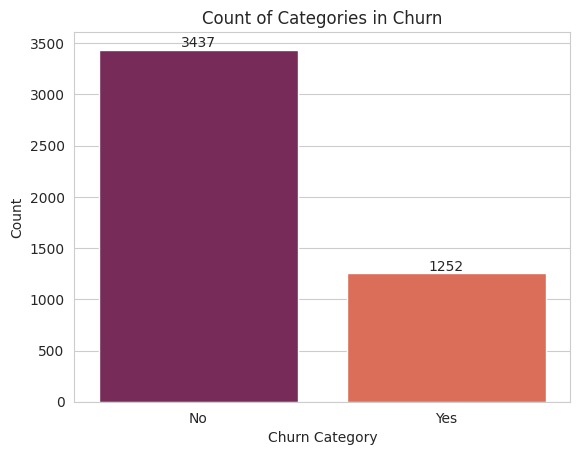

In [ ]:
sns.countplot(data=df, x='Churn', palette='rocket')
plt.title('Count of Categories in Churn')
plt.xlabel('Churn Category')
plt.ylabel('Count')

for p in plt.gca().patches:
    plt.text(p.get_x() + p.get_width() / 2., p.get_height(), f'{int(p.get_height())}',
             ha='center', va='bottom')

plt.show()

In [ ]:
chhurn_percentage = (df['Churn'].value_counts(normalize=True) * 100).round(1)
chhurn_percentage

No     73.3
Yes    26.7
Name: Churn, dtype: float64

## 2.5 Prepare the Categorical Data

We have to preprocess the data because has categorical data. What we are gonna do is to make the categorical data as 0s and 1s. The best is to make more features. For example: gender as gender_male and gender_female, etc... Except the target class.

In [ ]:
df.dtypes, test_df.dtypes

(gender               object
 SeniorCitizen         int64
 Partner              object
 Dependents           object
 tenure                int64
 PhoneService         object
 MultipleLines        object
 InternetService      object
 OnlineSecurity       object
 OnlineBackup         object
 DeviceProtection     object
 TechSupport          object
 StreamingTV          object
 StreamingMovies      object
 Contract             object
 PaperlessBilling     object
 PaymentMethod        object
 MonthlyCharges      float64
 TotalCharges        float64
 Churn                object
 dtype: object,
 gender               object
 SeniorCitizen         int64
 Partner              object
 Dependents           object
 tenure                int64
 PhoneService         object
 MultipleLines        object
 InternetService      object
 OnlineSecurity       object
 OnlineBackup         object
 DeviceProtection     object
 TechSupport          object
 StreamingTV          object
 StreamingMovies      objec

Firstly make the Churn with 1 if its True and 0 if its not.

In [ ]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
test_df['Churn'] = test_df['Churn'].map({'Yes': 1, 'No': 0})

Now convert the categorical columns into columns for each unique value of categorical column as 1 or 0 if its true or not.

In [ ]:
df_dummies = pd.get_dummies(df)
test_df_dummies = pd.get_dummies(test_df)

In [ ]:
df_dummies

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,...,StreamingMovies_Yes,Contract_'One year',Contract_'Two year',Contract_Month-to-month,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_'Bank transfer (automatic)',PaymentMethod_'Credit card (automatic)',PaymentMethod_'Electronic check',PaymentMethod_'Mailed check'
0,0,61,33.60,2117.20,0,0,1,0,1,0,...,0,0,0,1,1,0,1,0,0,0
1,0,72,90.45,6565.85,0,0,1,0,1,0,...,0,0,1,0,1,0,1,0,0,0
2,0,5,84.00,424.75,0,1,0,1,0,1,...,0,0,0,1,0,1,0,0,1,0
3,0,49,67.40,3306.85,0,1,0,1,0,1,...,0,0,1,0,1,0,1,0,0,0
4,0,8,19.70,168.90,0,0,1,1,0,1,...,0,0,0,1,0,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4684,0,24,84.80,1990.50,0,0,1,0,1,0,...,1,1,0,0,0,1,0,0,0,1
4685,0,72,103.20,7362.90,0,1,0,0,1,0,...,1,1,0,0,0,1,0,1,0,0
4686,0,11,29.60,346.45,0,1,0,0,1,0,...,0,0,0,1,0,1,0,0,1,0
4687,1,4,74.40,306.60,1,0,1,0,1,1,...,0,0,0,1,0,1,0,0,0,1


### 2.5.1 EDA

In [ ]:
print('Covariance:')
df_covariances = pd.DataFrame(df_dummies.cov())
df_covariances.transpose()

Covariance:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,...,StreamingMovies_Yes,Contract_'One year',Contract_'Two year',Contract_Month-to-month,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_'Bank transfer (automatic)',PaymentMethod_'Credit card (automatic)',PaymentMethod_'Electronic check',PaymentMethod_'Mailed check'
SeniorCitizen,0.136703,0.274114,2.442241,9.235706e+01,0.026764,-0.001732,0.001732,-0.004107,0.004107,0.035333,...,0.021921,-0.006202,-0.018838,0.025039,-0.029080,0.029080,-0.003494,-0.001853,0.030127,-0.024780
tenure,0.274114,600.172518,187.182209,4.575066e+04,-3.821819,0.033915,-0.033915,-4.653273,4.653273,-1.673782,...,3.484169,2.046644,5.832024,-7.878668,0.036706,-0.036706,2.357058,2.220800,-2.216075,-2.361783
MonthlyCharges,2.442241,187.182209,910.982268,4.485511e+04,2.519839,0.167698,-0.167698,-1.451879,1.451879,1.645810,...,9.265721,0.049915,-0.827880,0.777964,-5.333799,5.333799,0.460609,0.205486,4.124038,-4.790134
TotalCharges,92.357059,45750.663876,44855.112250,5.126727e+06,-199.205937,8.343241,-8.343241,-353.599197,353.599197,-47.942854,...,580.721279,155.566538,344.115685,-499.682224,-173.772756,173.772756,165.533804,157.147764,-42.095443,-280.586125
Churn,0.026764,-3.821819,2.519839,-1.992059e+02,0.195756,0.000015,-0.000015,0.033582,-0.033582,0.031684,...,0.011673,-0.032481,-0.055030,0.087511,-0.043115,0.043115,-0.022697,-0.022300,0.060806,-0.015809
gender_Female,-0.001732,0.033915,0.167698,8.343241e+00,0.000015,0.250047,-0.250047,-0.002134,0.002134,-0.000610,...,0.004245,-0.002257,0.002717,-0.000460,-0.001343,0.001343,0.001587,0.001377,-0.003651,0.000687
gender_Male,0.001732,-0.033915,-0.167698,-8.343241e+00,-0.000015,-0.250047,0.250047,0.002134,-0.002134,0.000610,...,-0.004245,0.002257,-0.002717,0.000460,0.001343,-0.001343,-0.001587,-0.001377,0.003651,-0.000687
Partner_No,-0.004107,-4.653273,-1.451879,-3.535992e+02,0.033582,-0.002134,0.002134,0.249603,-0.249603,0.098880,...,-0.028709,-0.018328,-0.055179,0.073508,-0.006762,0.006762,-0.022204,-0.015628,0.018001,0.019831
Partner_Yes,0.004107,4.653273,1.451879,3.535992e+02,-0.033582,0.002134,-0.002134,-0.249603,0.249603,-0.098880,...,0.028709,0.018328,0.055179,-0.073508,0.006762,-0.006762,0.022204,0.015628,-0.018001,-0.019831
Dependents_No,0.035333,-1.673782,1.645810,-4.794285e+01,0.031684,-0.000610,0.000610,0.098880,-0.098880,0.206763,...,0.011533,-0.014319,-0.037580,0.051899,-0.026242,0.026242,-0.011474,-0.006923,0.029963,-0.011565


In [ ]:
print('Correlation:')
df_corr_matrix = df_dummies.corr()
df_corr_matrix

Correlation:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,...,StreamingMovies_Yes,Contract_'One year',Contract_'Two year',Contract_Month-to-month,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_'Bank transfer (automatic)',PaymentMethod_'Credit card (automatic)',PaymentMethod_'Electronic check',PaymentMethod_'Mailed check'
SeniorCitizen,1.000000,0.030262,0.218849,0.110322,0.163611,-0.009370,0.009370,-0.022235,0.022235,0.210162,...,0.121963,-0.041157,-0.119625,0.136162,-0.159954,0.159954,-0.023120,-0.012226,0.172264,-0.157701
tenure,0.030262,1.000000,0.253146,0.824782,-0.352593,0.002768,-0.002768,-0.380186,0.380186,-0.150253,...,0.292559,0.204985,0.558942,-0.646598,0.003047,-0.003047,0.235378,0.221123,-0.191237,-0.226845
MonthlyCharges,0.218849,0.253146,1.000000,0.656352,0.188695,0.011111,-0.011111,-0.096283,0.096283,0.119919,...,0.631505,0.004058,-0.064402,0.051823,-0.359396,0.359396,0.037335,0.016607,0.288864,-0.373439
TotalCharges,0.110322,0.824782,0.656352,1.000000,-0.198849,0.007369,-0.007369,-0.312584,0.312584,-0.046566,...,0.527594,0.168583,0.356837,-0.443704,-0.156082,0.156082,0.178855,0.169298,-0.039304,-0.291590
Churn,0.163611,-0.352593,0.188695,-0.198849,1.000000,0.000068,-0.000068,0.151923,-0.151923,0.157486,...,0.054270,-0.180130,-0.292030,0.397670,-0.198179,0.198179,-0.125503,-0.122944,0.290546,-0.084075
gender_Female,-0.009370,0.002768,0.011111,0.007369,0.000068,1.000000,-1.000000,-0.008543,0.008543,-0.002681,...,0.017465,-0.011076,0.012757,-0.001849,-0.005462,0.005462,0.007762,0.006719,-0.015435,0.003232
gender_Male,0.009370,-0.002768,-0.011111,-0.007369,-0.000068,-1.000000,1.000000,0.008543,-0.008543,0.002681,...,-0.017465,0.011076,-0.012757,0.001849,0.005462,-0.005462,-0.007762,-0.006719,0.015435,-0.003232
Partner_No,-0.022235,-0.380186,-0.096283,-0.312584,0.151923,-0.008543,0.008543,1.000000,-1.000000,0.435259,...,-0.118209,-0.090015,-0.259321,0.295820,-0.027525,0.027525,-0.108728,-0.076301,0.076171,0.093399
Partner_Yes,0.022235,0.380186,0.096283,0.312584,-0.151923,0.008543,-0.008543,-1.000000,1.000000,-0.435259,...,0.118209,0.090015,0.259321,-0.295820,0.027525,-0.027525,0.108728,0.076301,-0.076171,-0.093399
Dependents_No,0.210162,-0.150253,0.119919,-0.046566,0.157486,-0.002681,0.002681,0.435259,-0.435259,1.000000,...,0.052176,-0.077267,-0.194044,0.229476,-0.117367,0.117367,-0.061734,-0.037140,0.139305,-0.059846


In [ ]:
sorted_corr_matrix = df_corr_matrix['Churn'].sort_values(ascending=False)
sorted_corr_matrix

Churn                                        1.000000
Contract_Month-to-month                      0.397670
OnlineSecurity_No                            0.340062
TechSupport_No                               0.321782
InternetService_'Fiber optic'                0.297279
PaymentMethod_'Electronic check'             0.290546
OnlineBackup_No                              0.269791
DeviceProtection_No                          0.253241
PaperlessBilling_Yes                         0.198179
MonthlyCharges                               0.188695
SeniorCitizen                                0.163611
Dependents_No                                0.157486
Partner_No                                   0.151923
StreamingMovies_No                           0.136113
StreamingTV_No                               0.122490
StreamingTV_Yes                              0.067979
StreamingMovies_Yes                          0.054270
MultipleLines_Yes                            0.050638
PhoneService_Yes            

### 2.5.2 Visualizations

#### Histograms for each variable

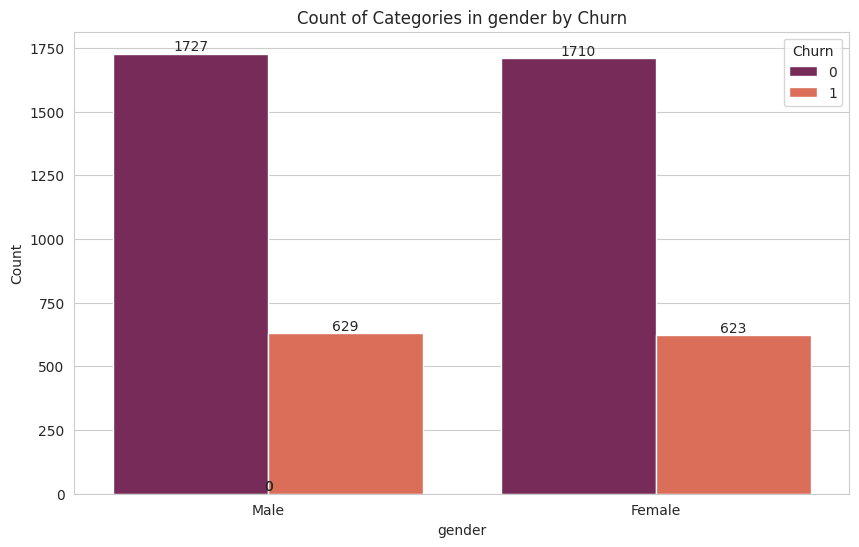

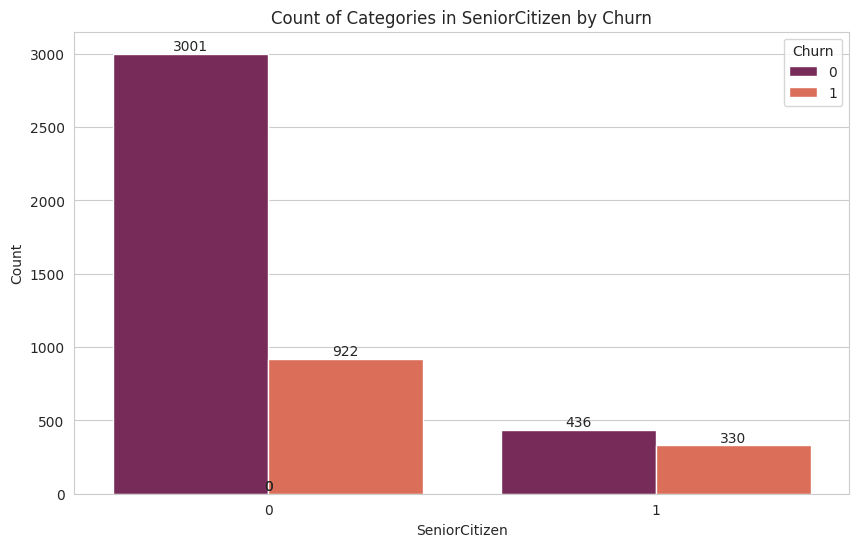

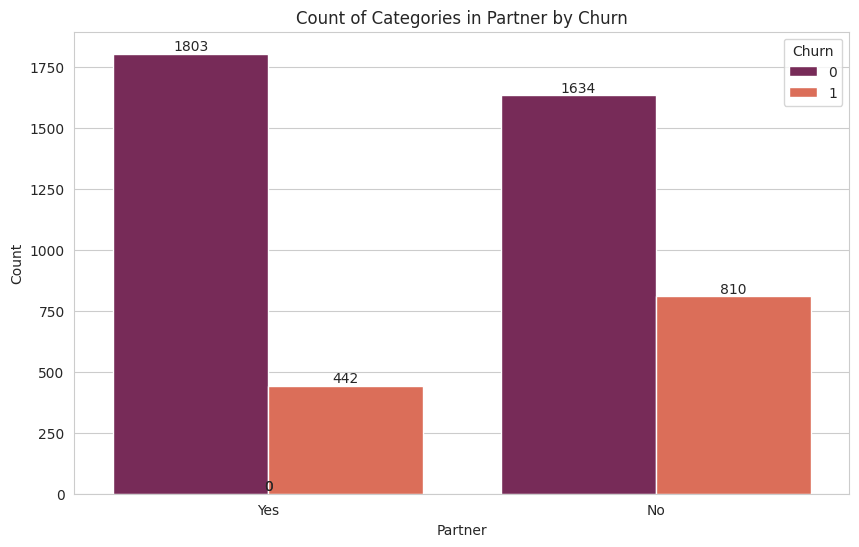

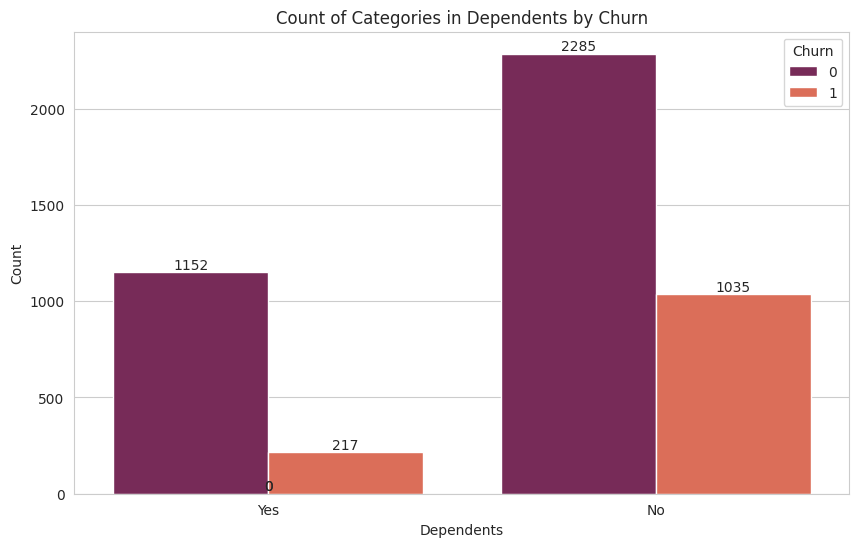

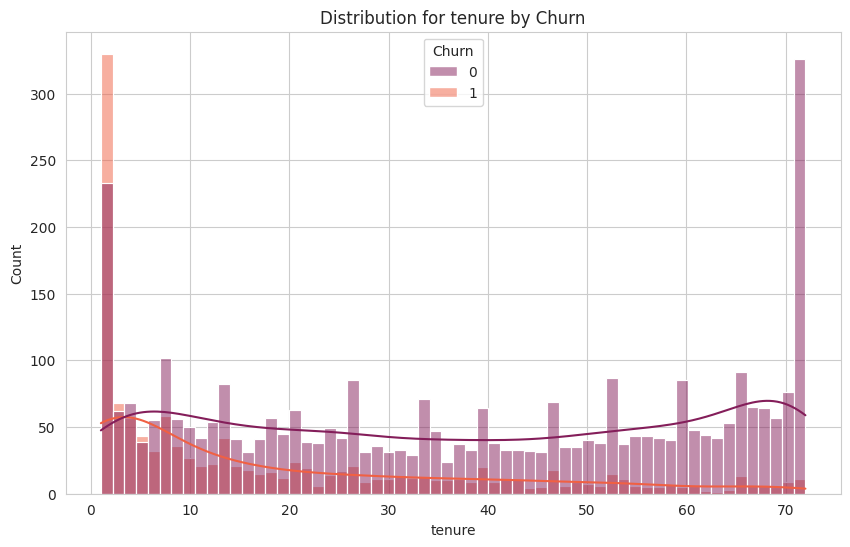

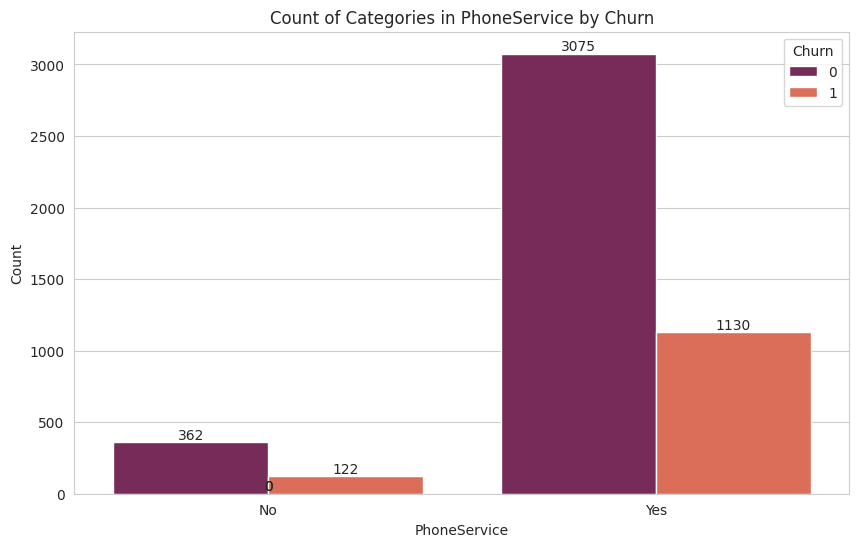

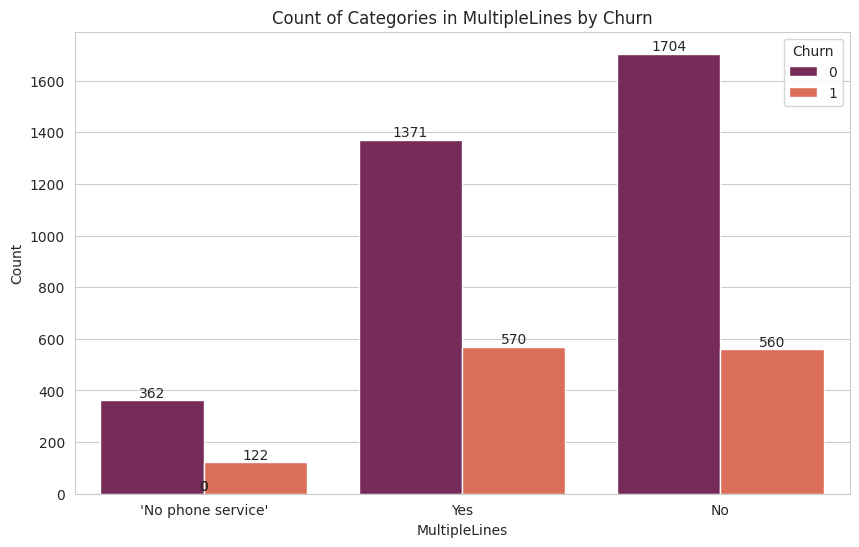

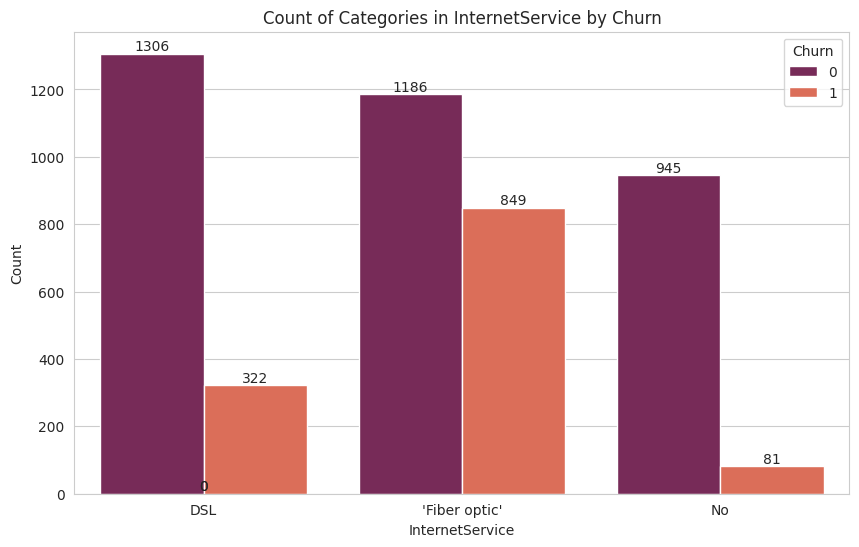

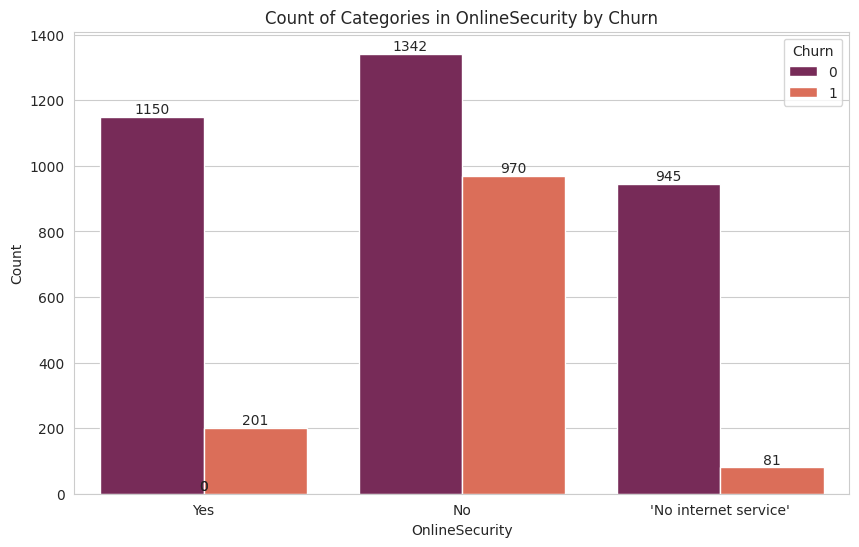

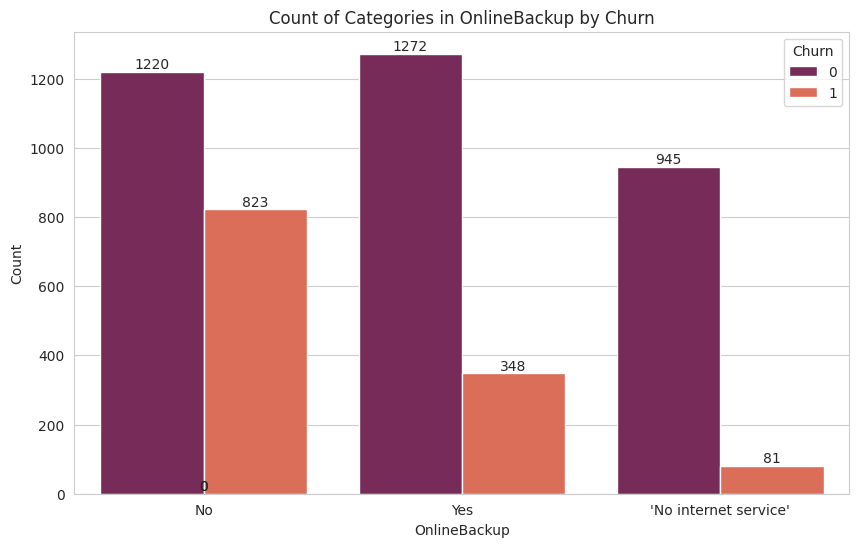

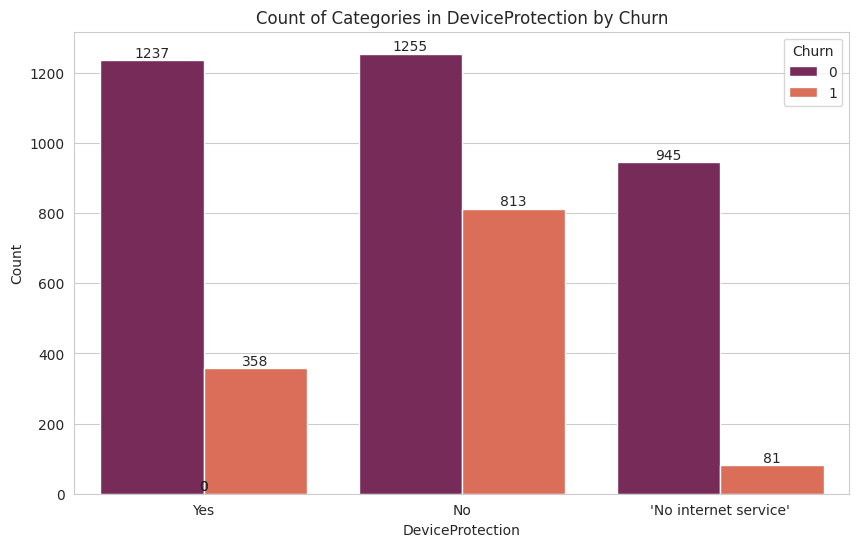

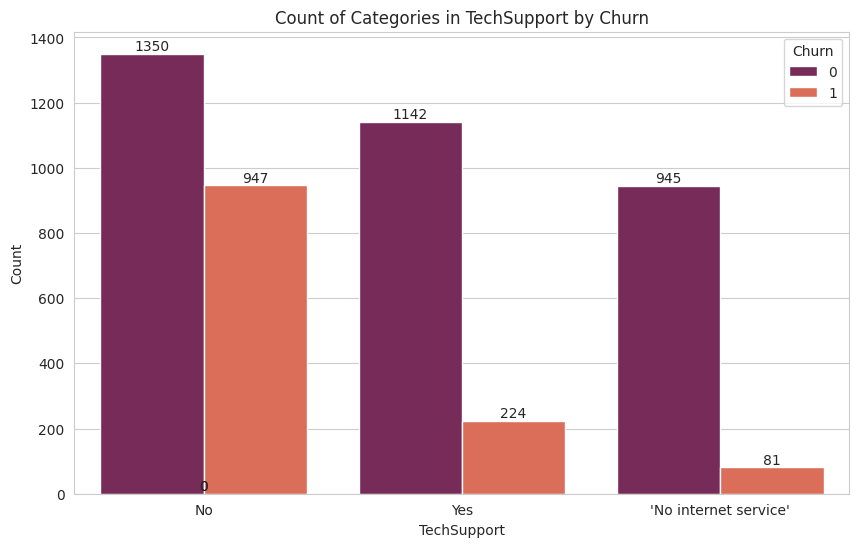

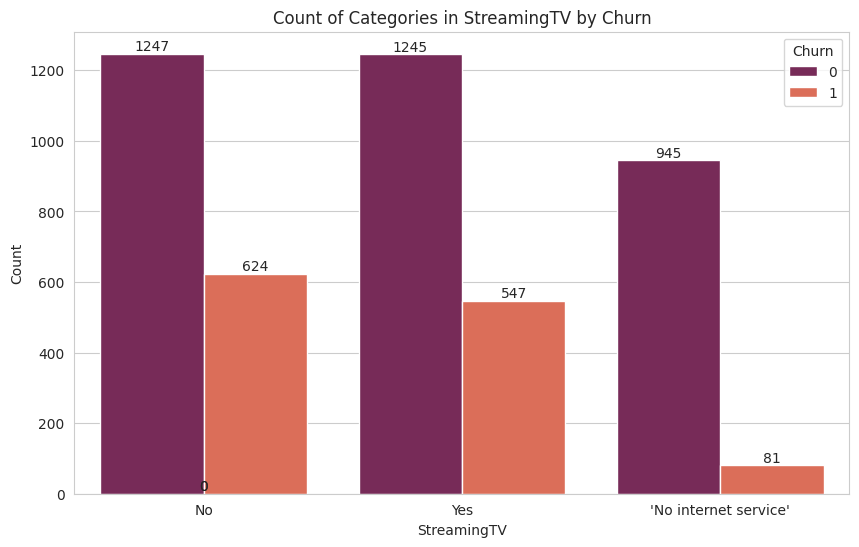

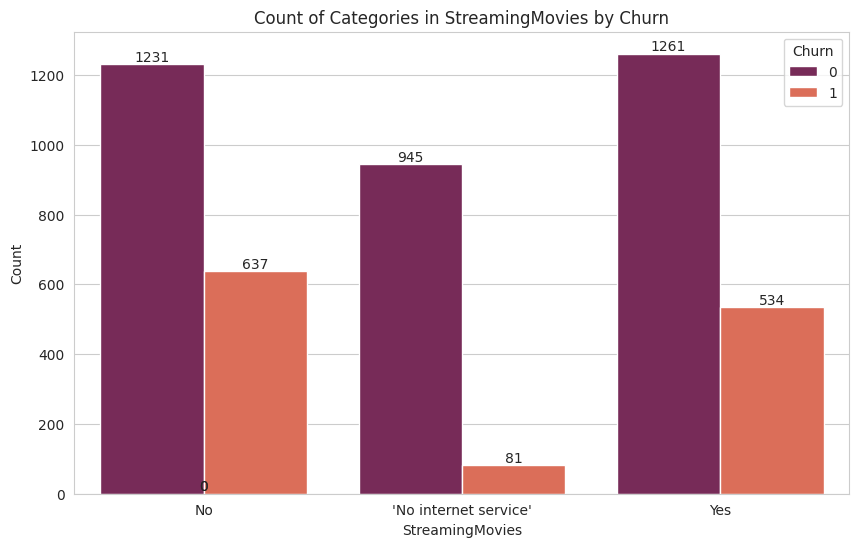

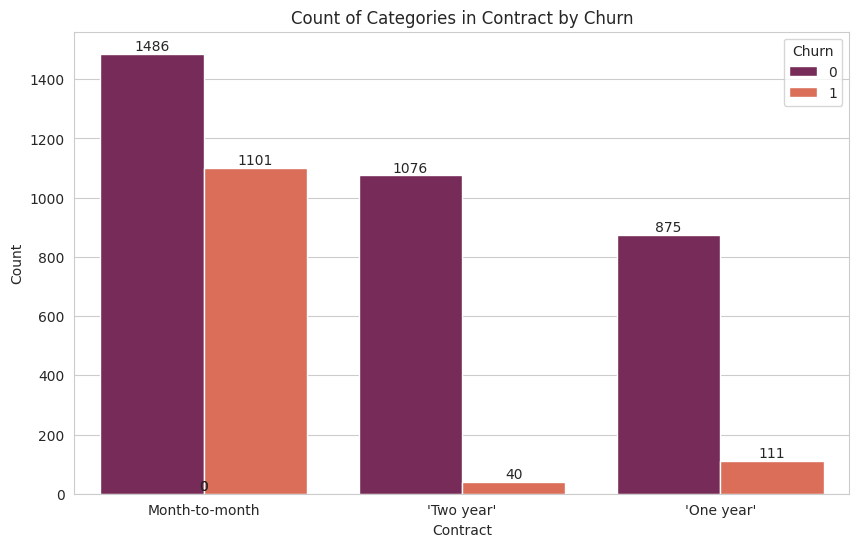

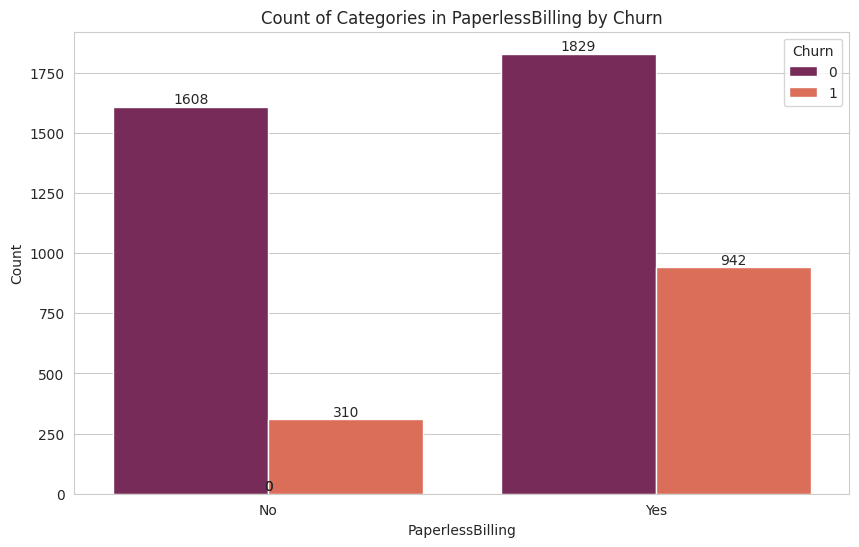

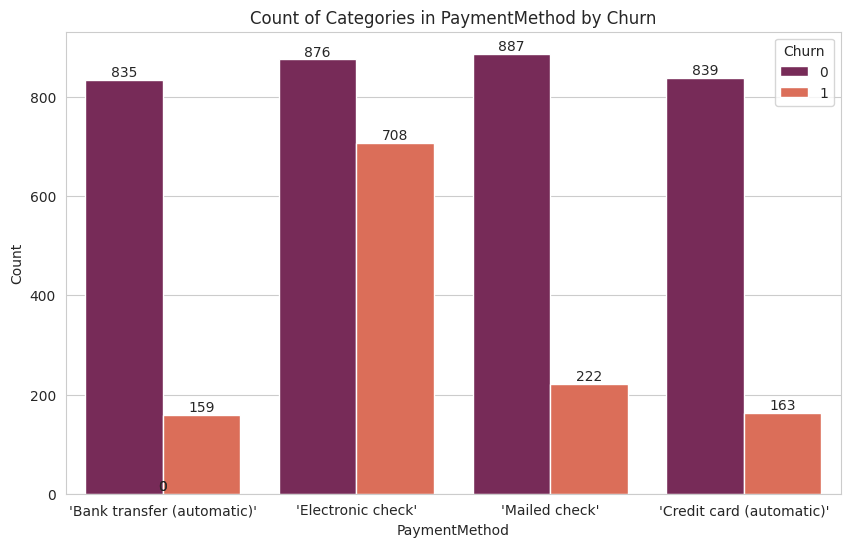

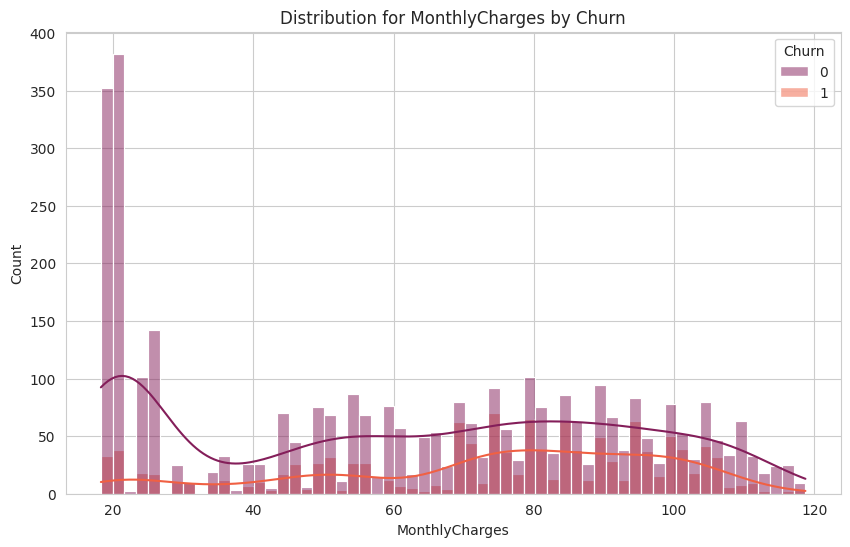

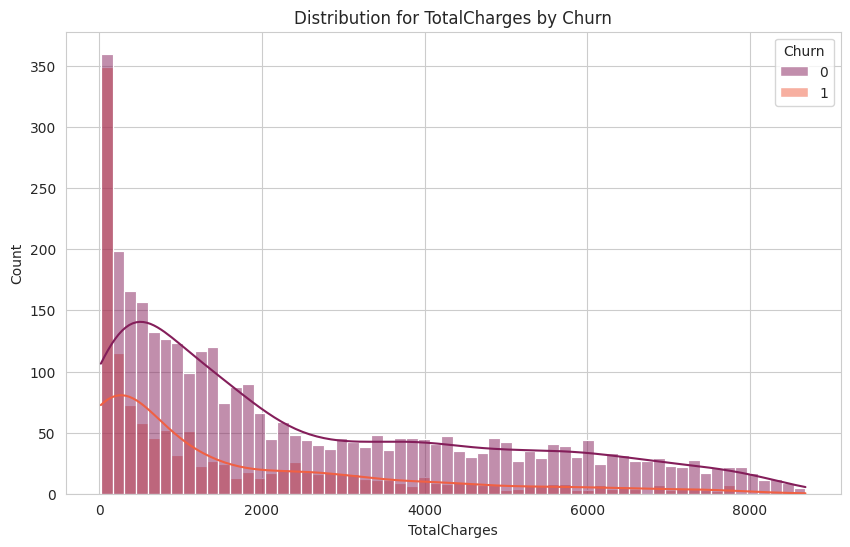

In [ ]:
plot_histo_bars(df)

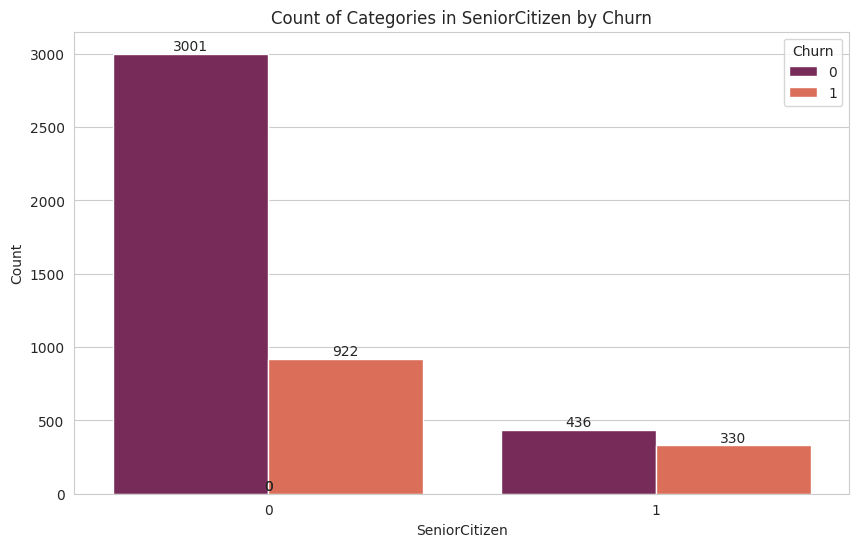

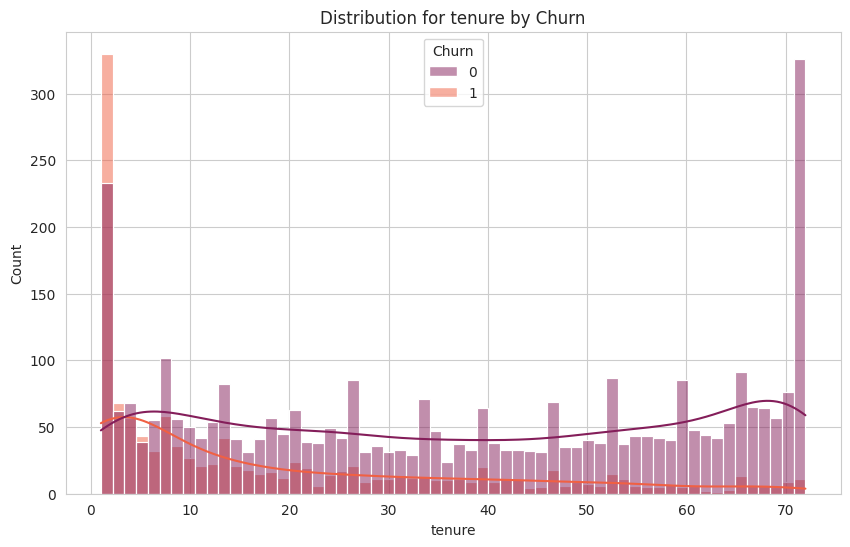

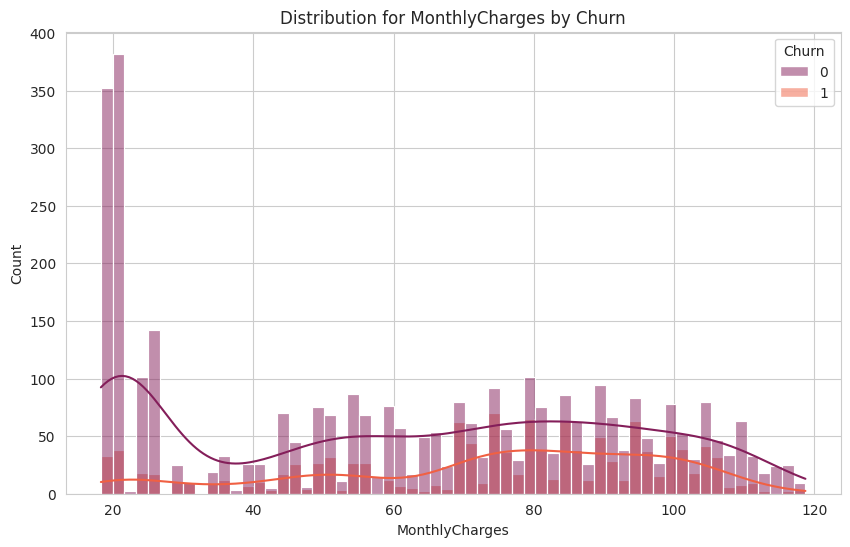

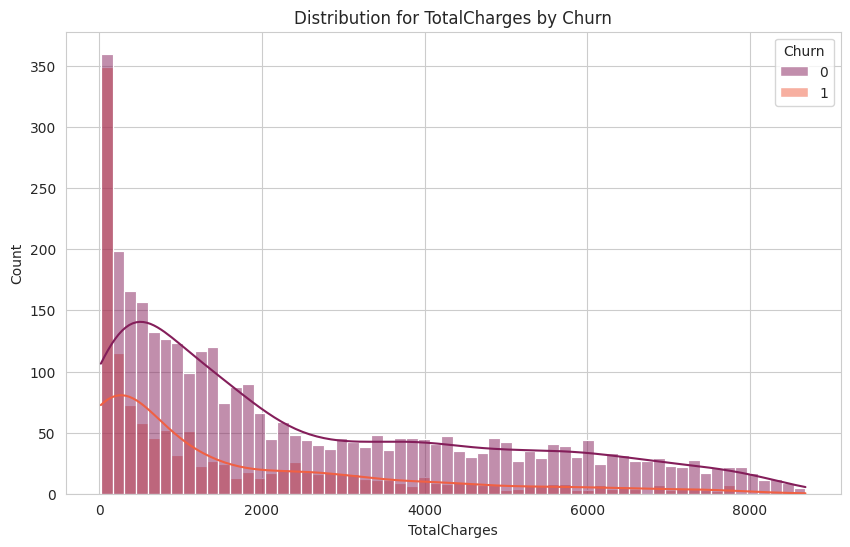

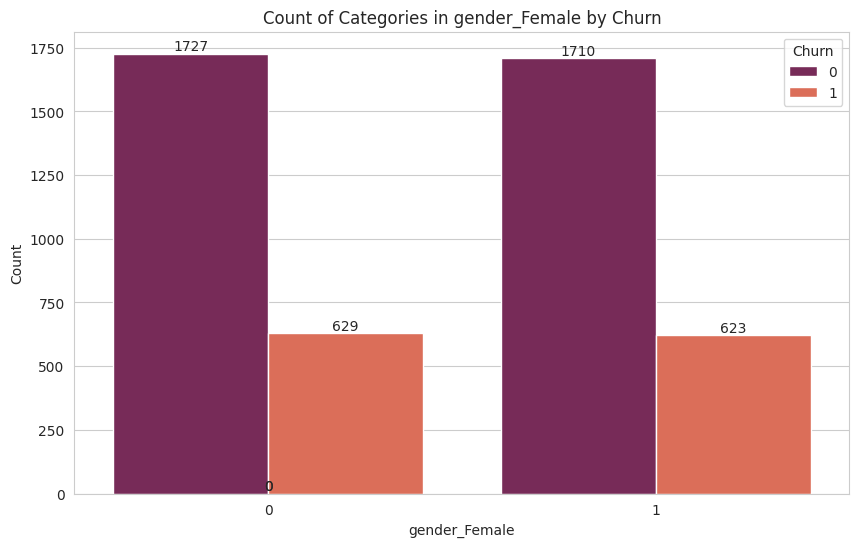

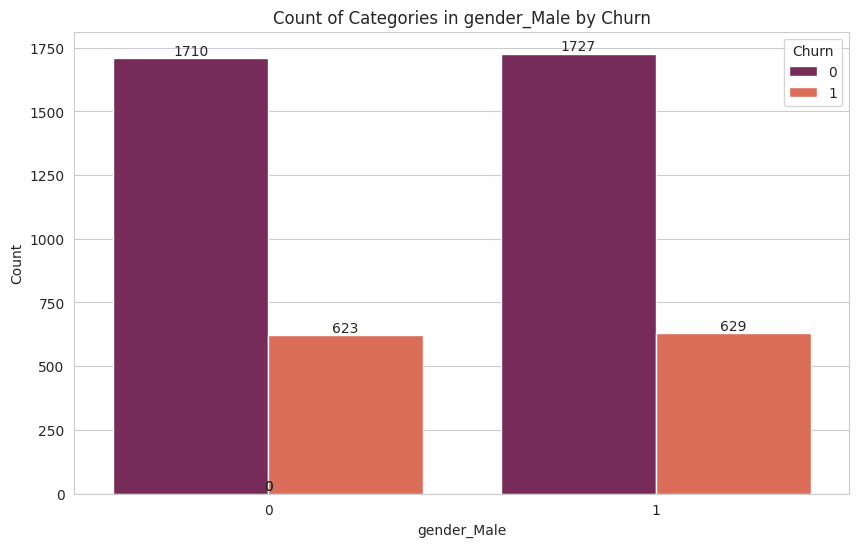

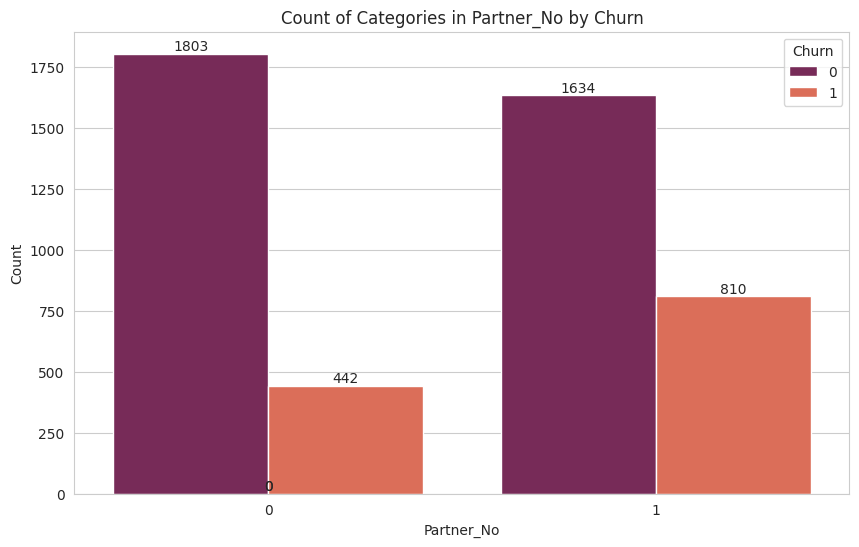

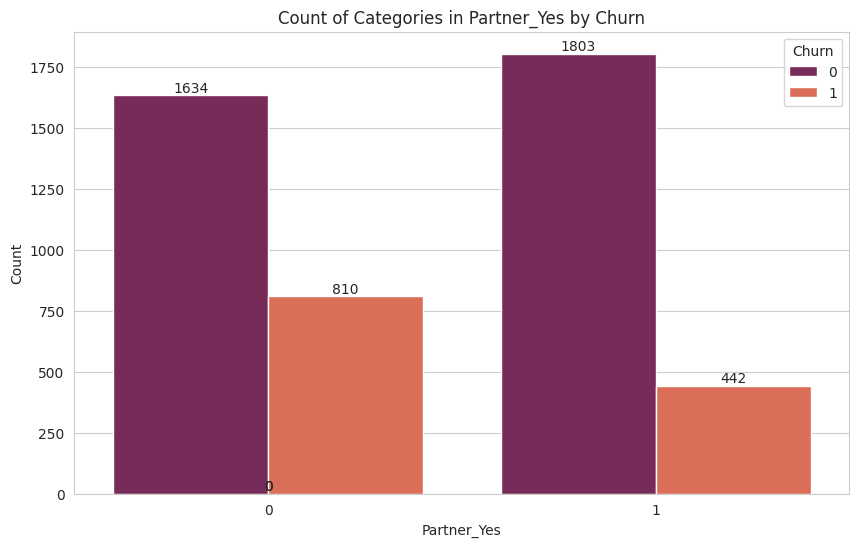

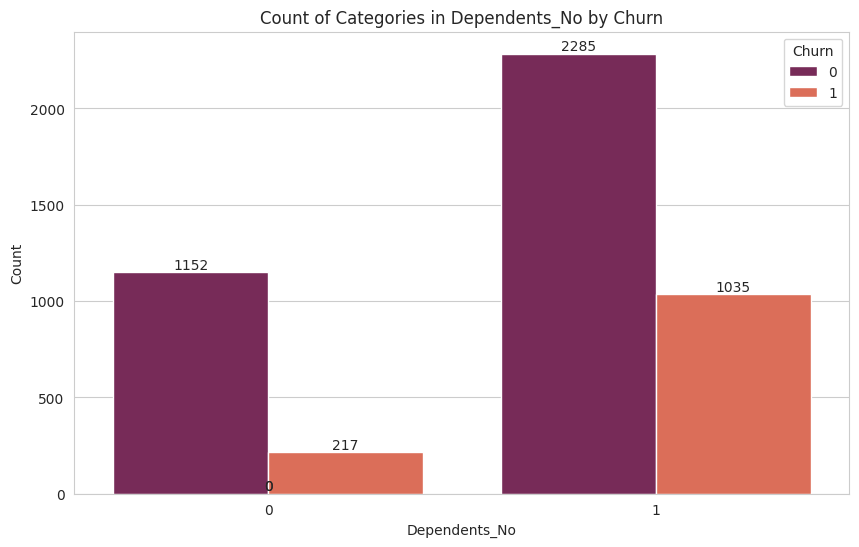

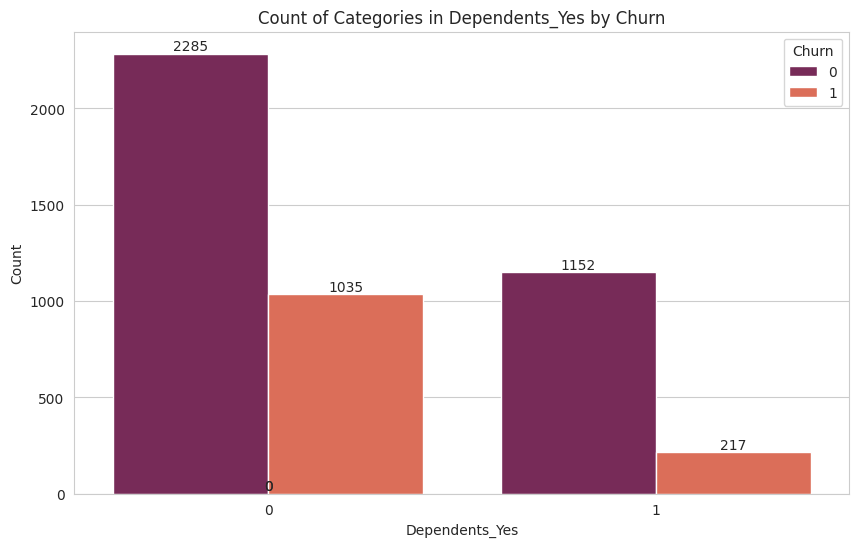

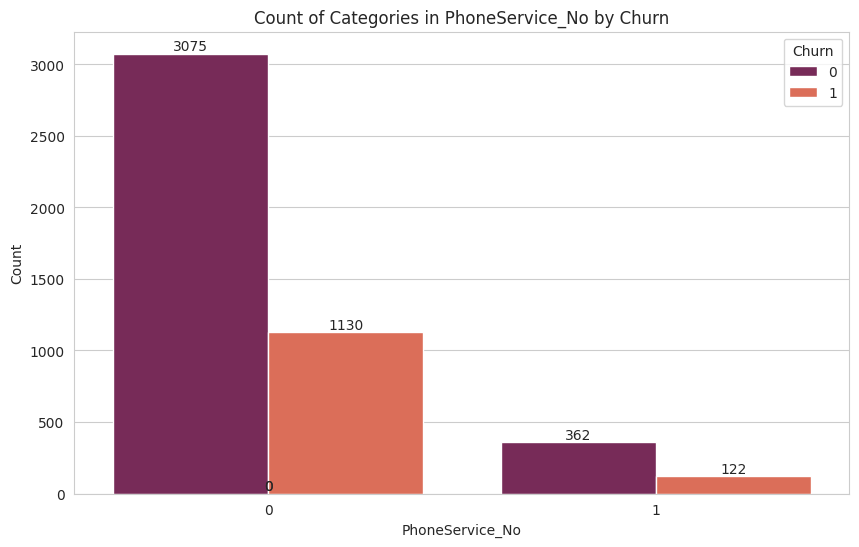

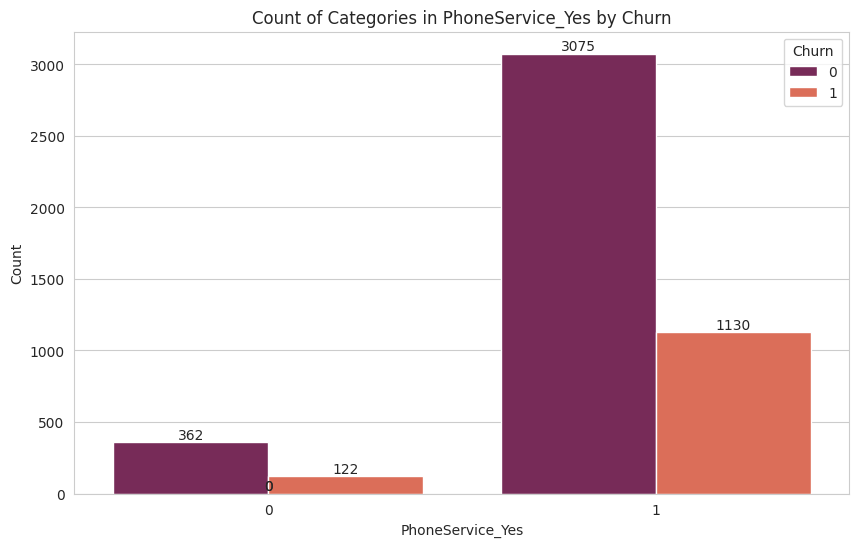

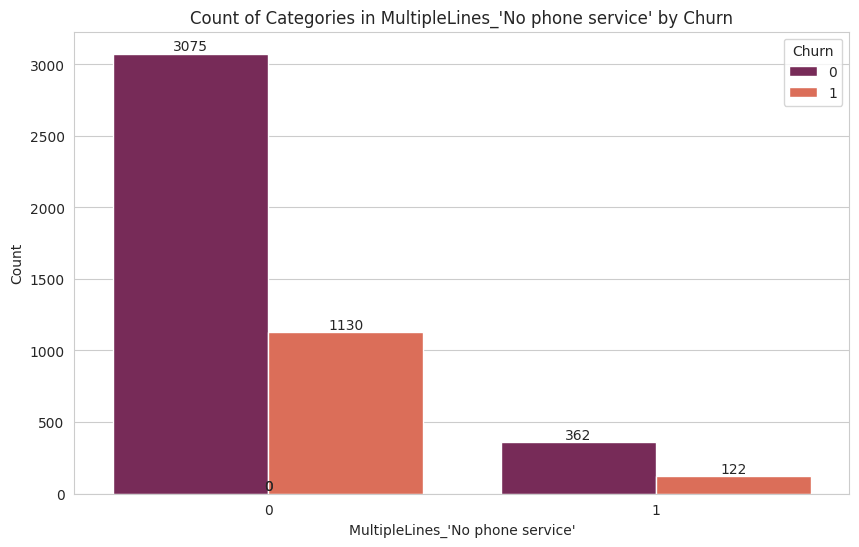

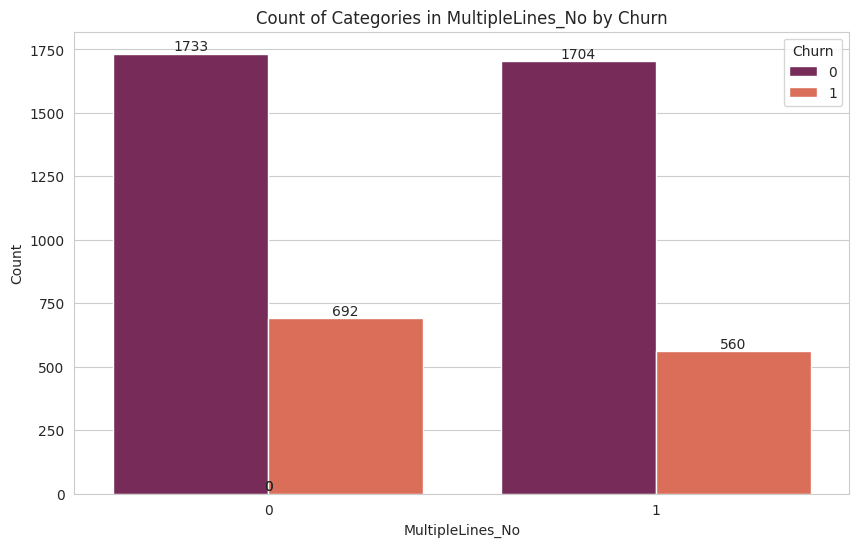

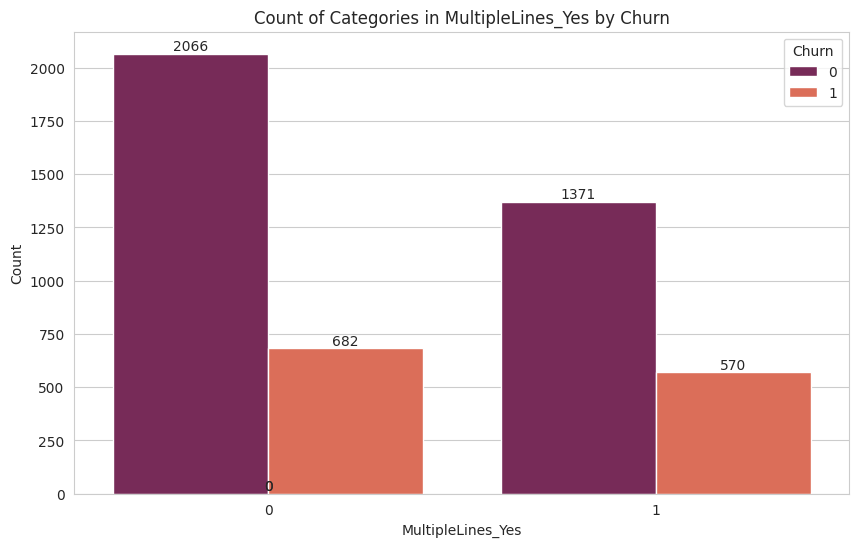

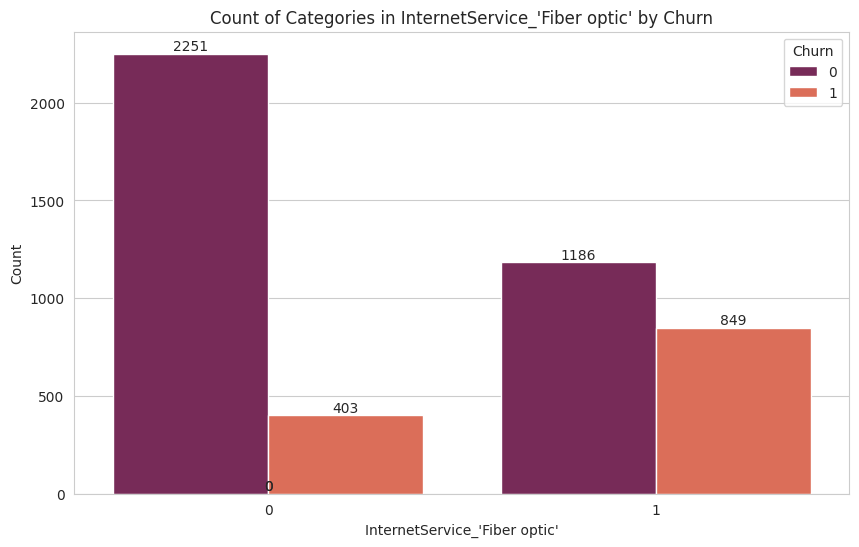

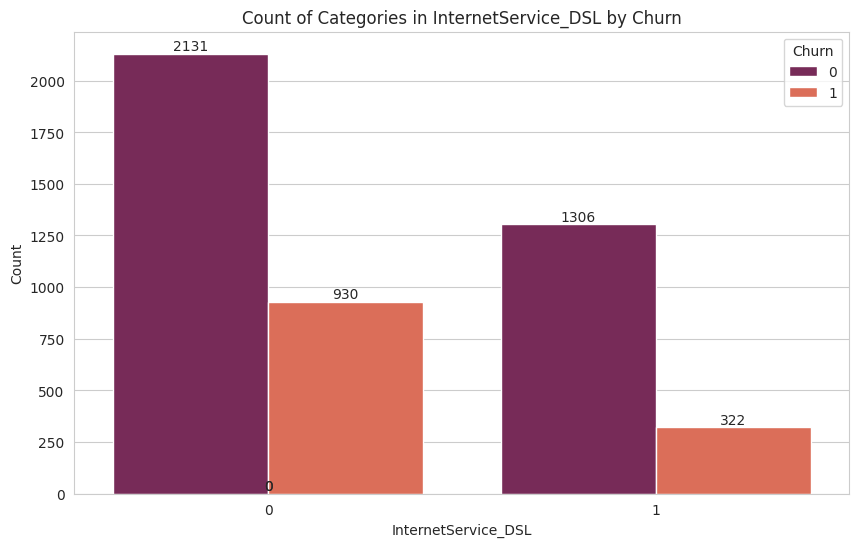

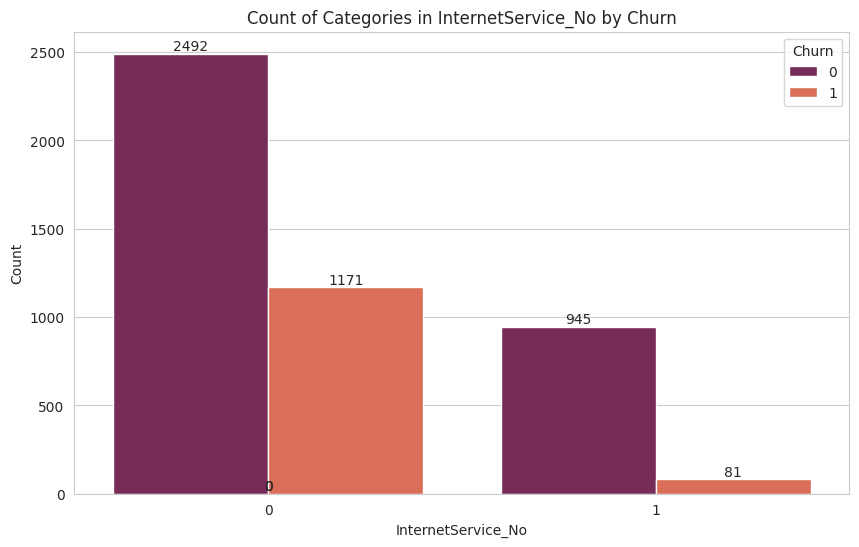

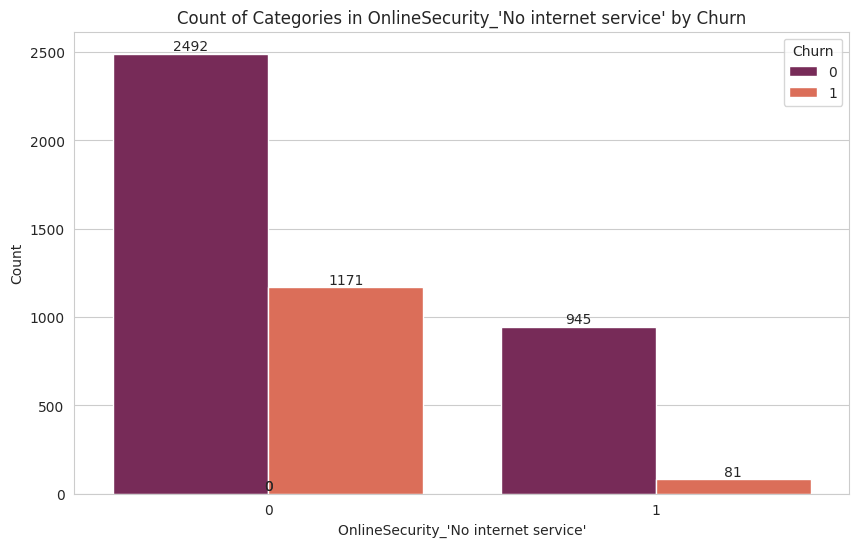

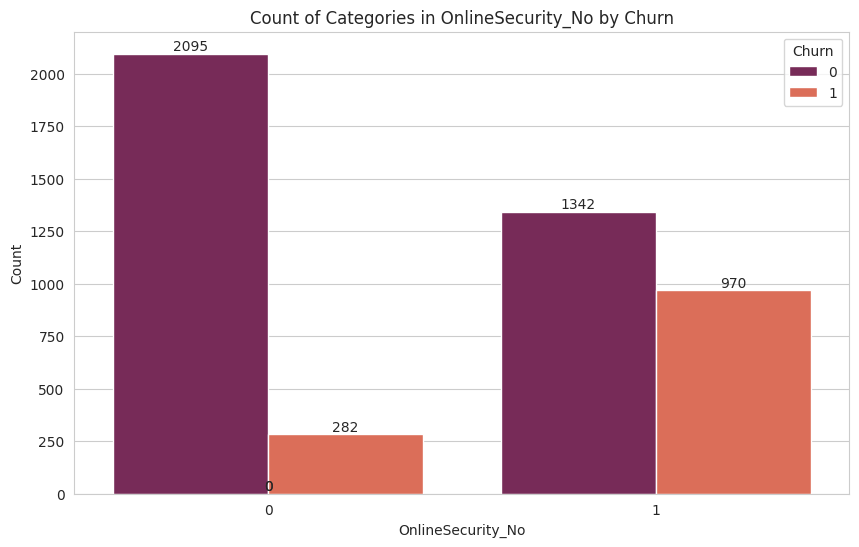

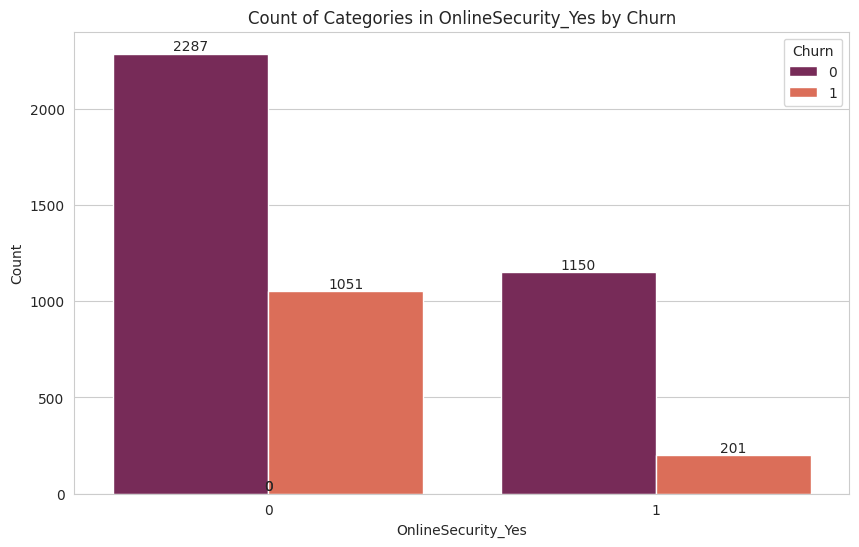

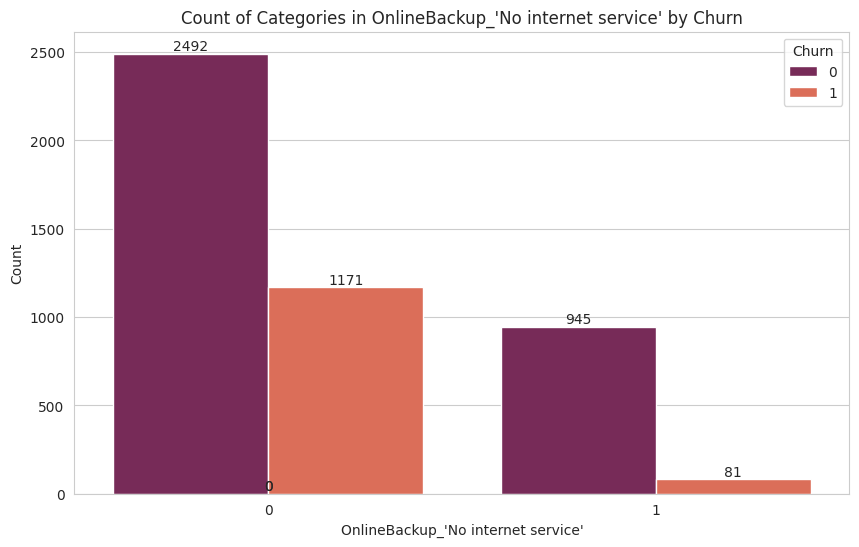

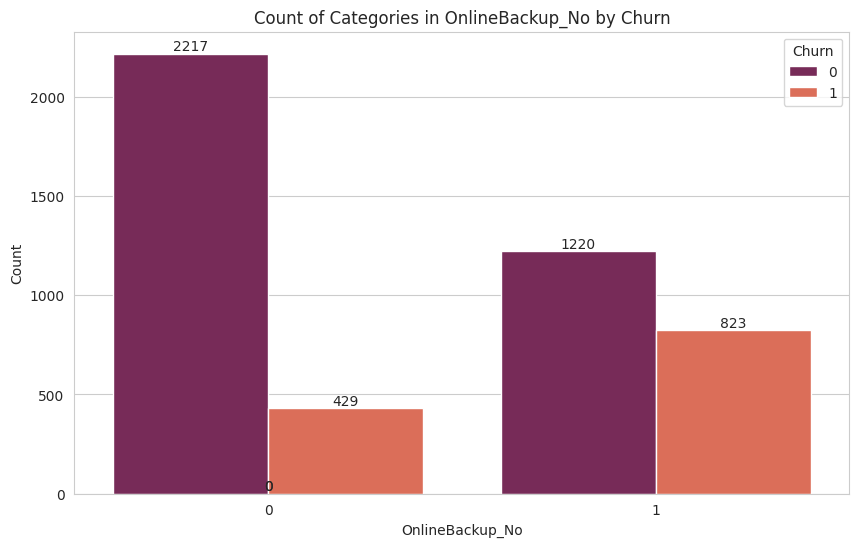

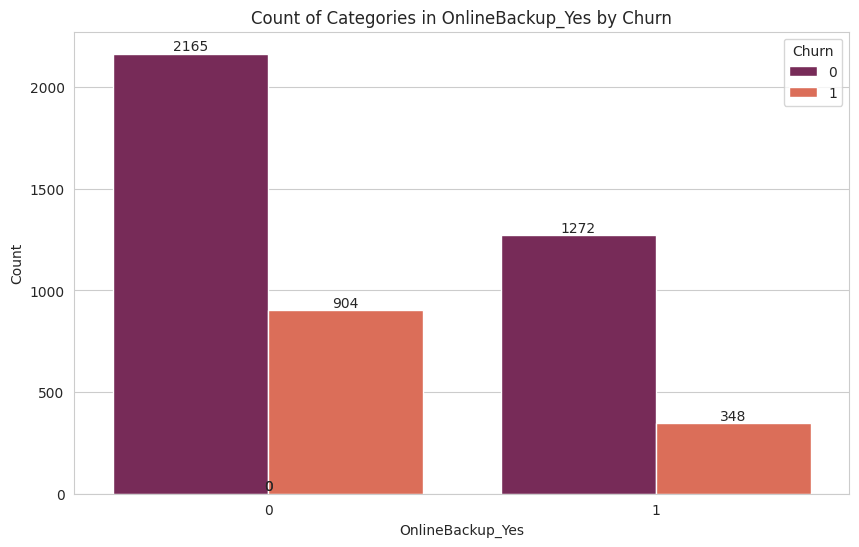

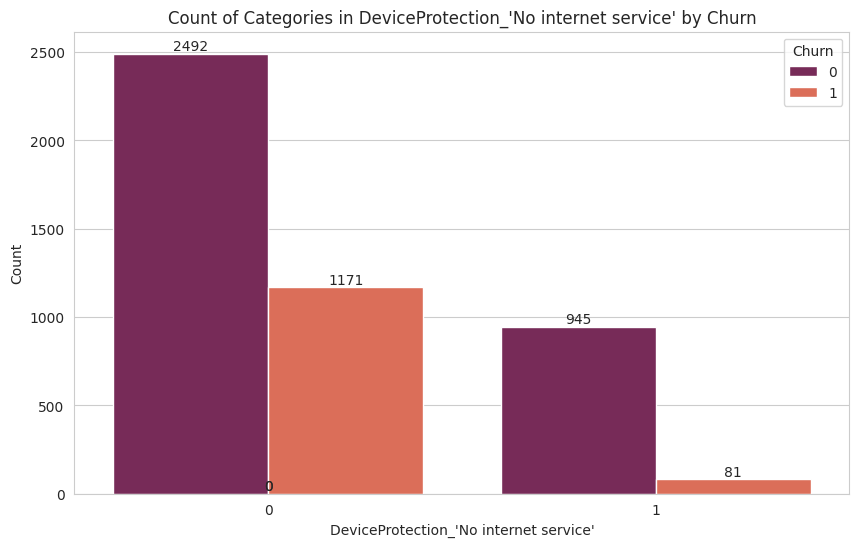

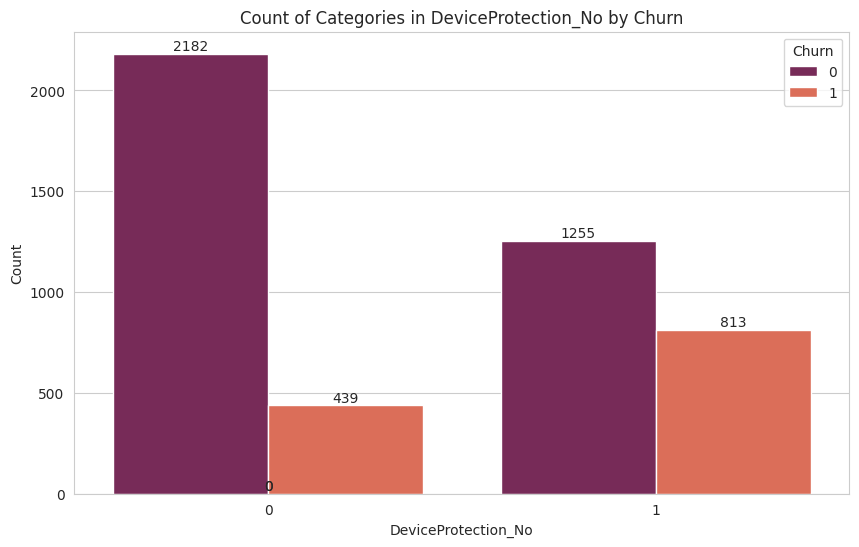

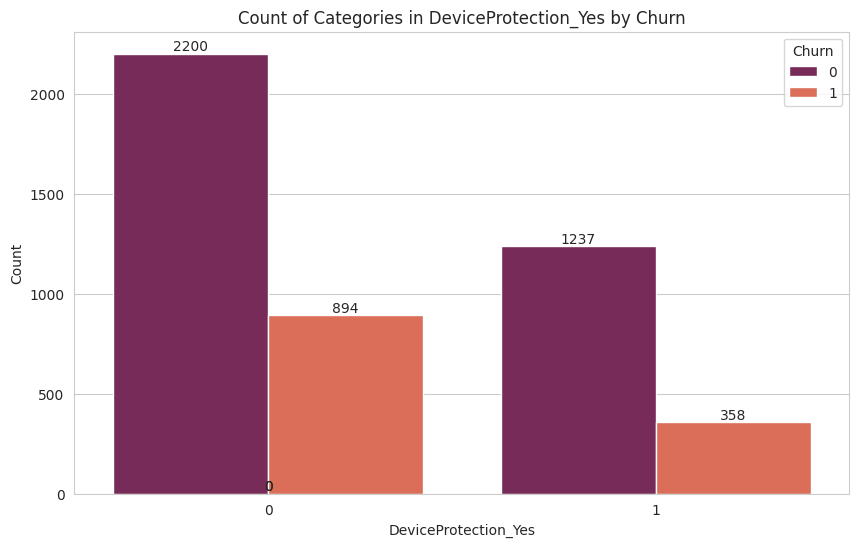

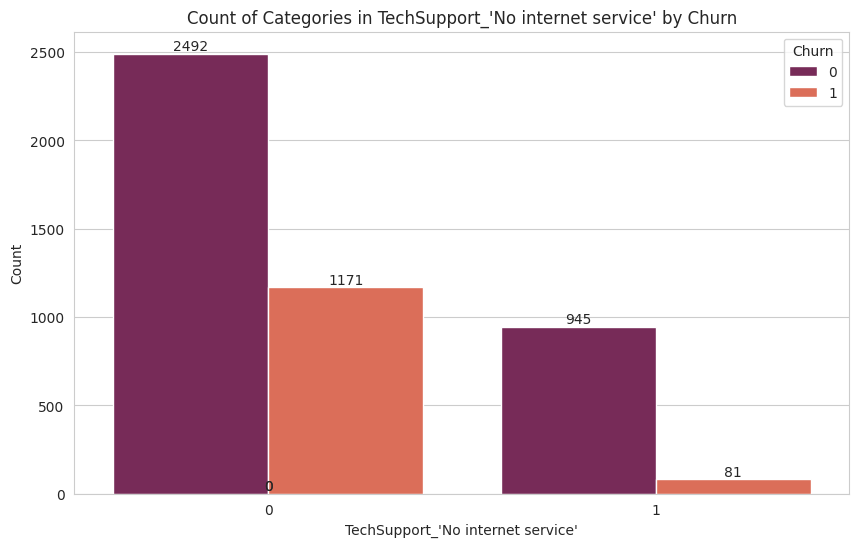

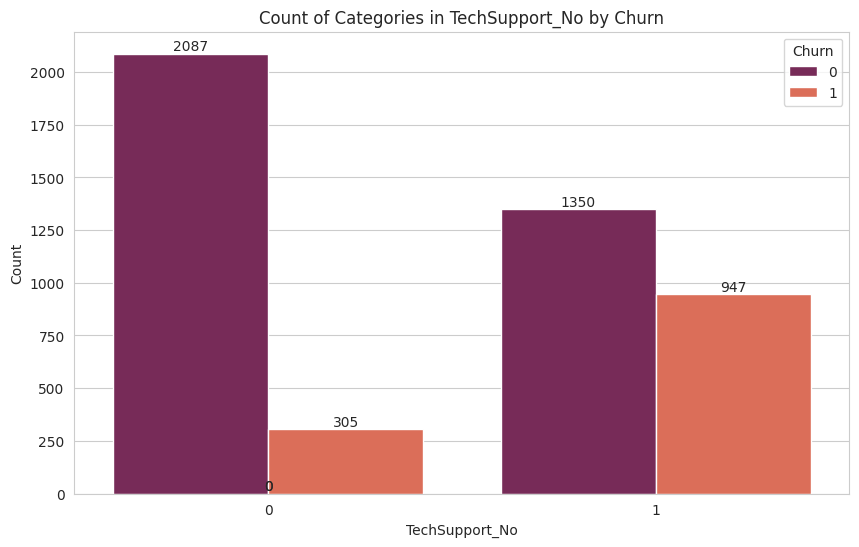

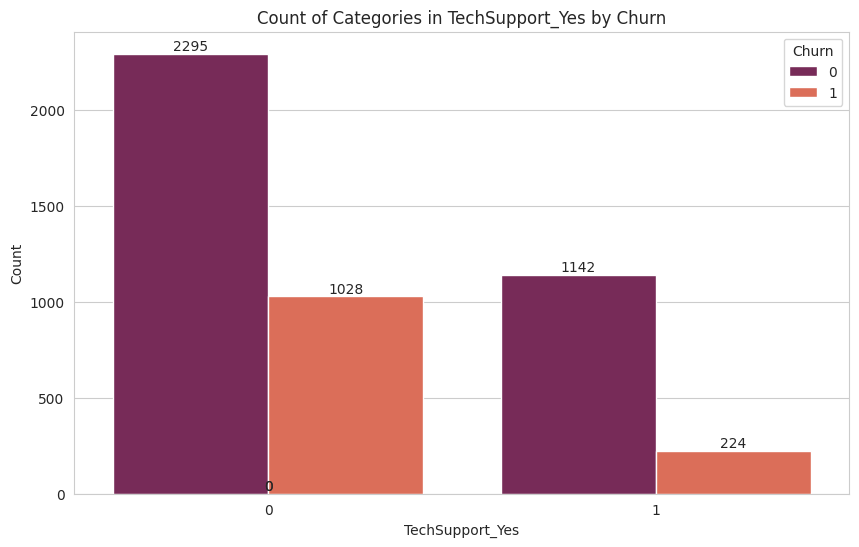

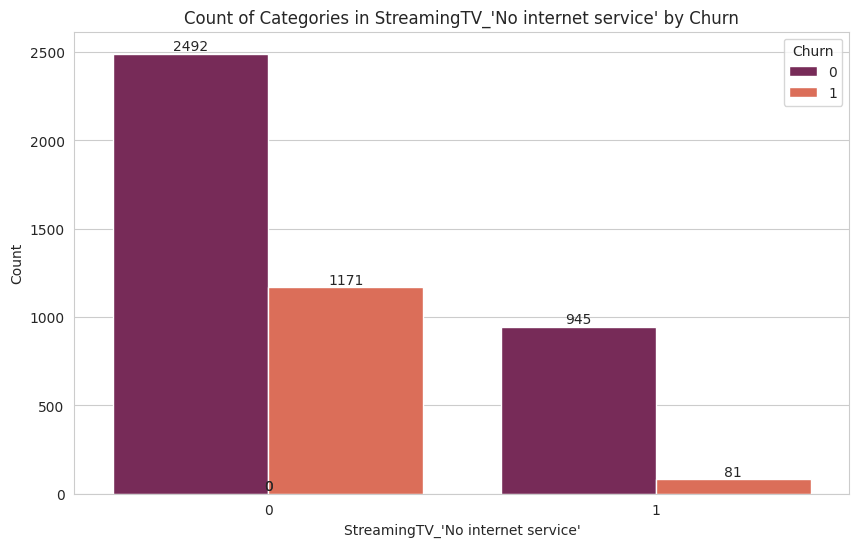

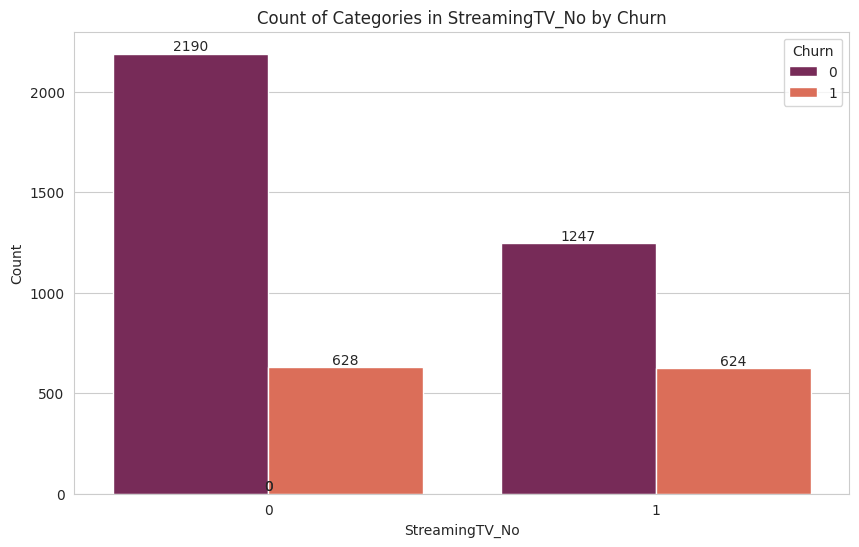

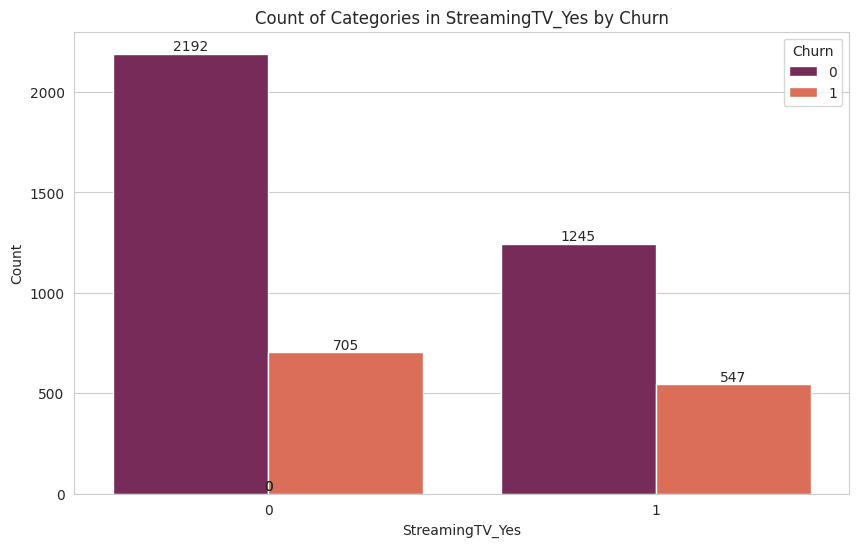

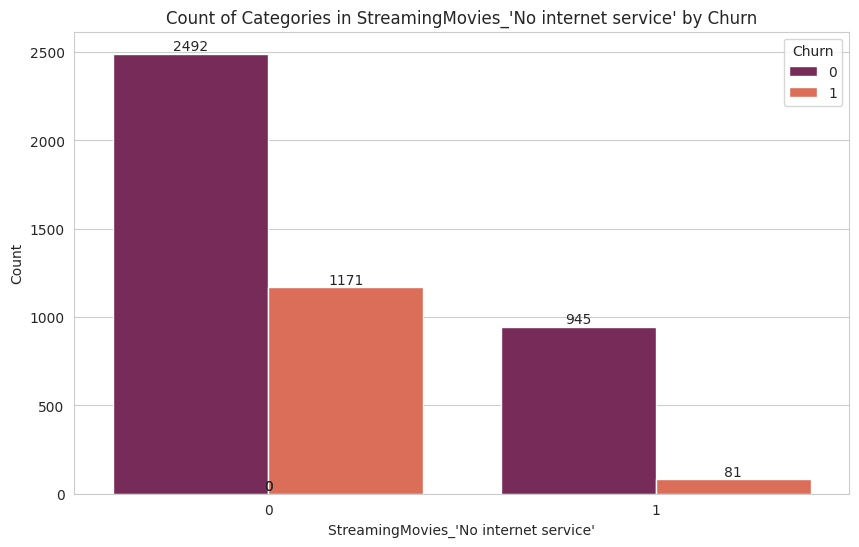

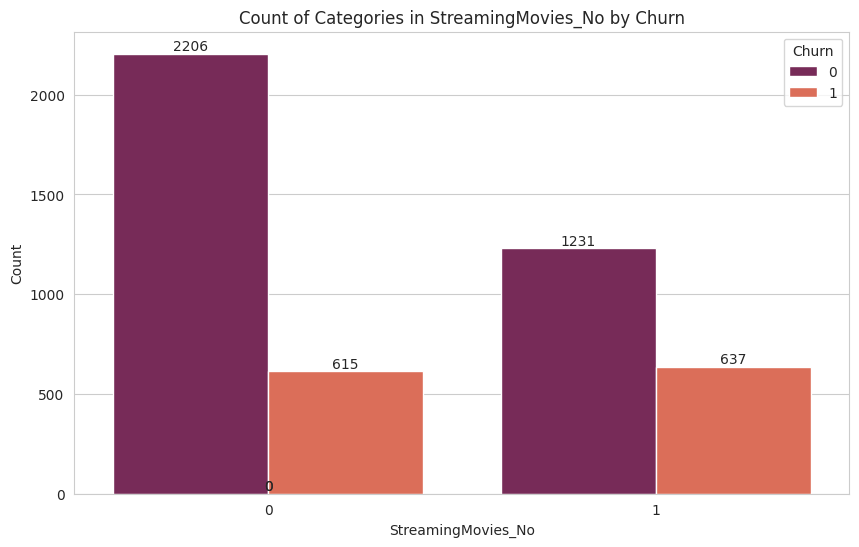

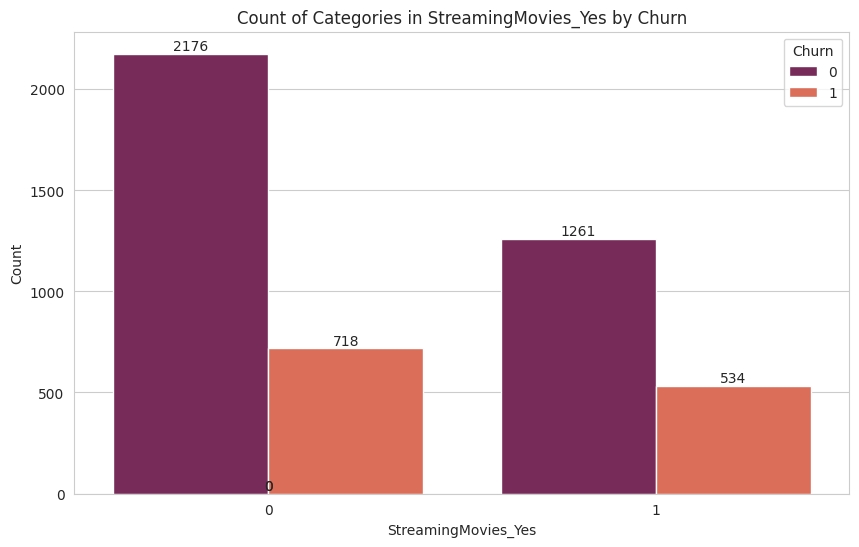

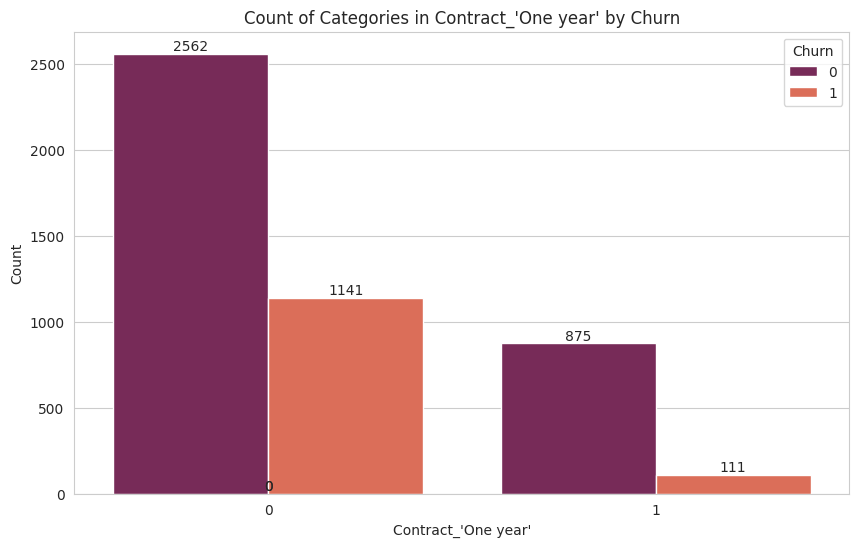

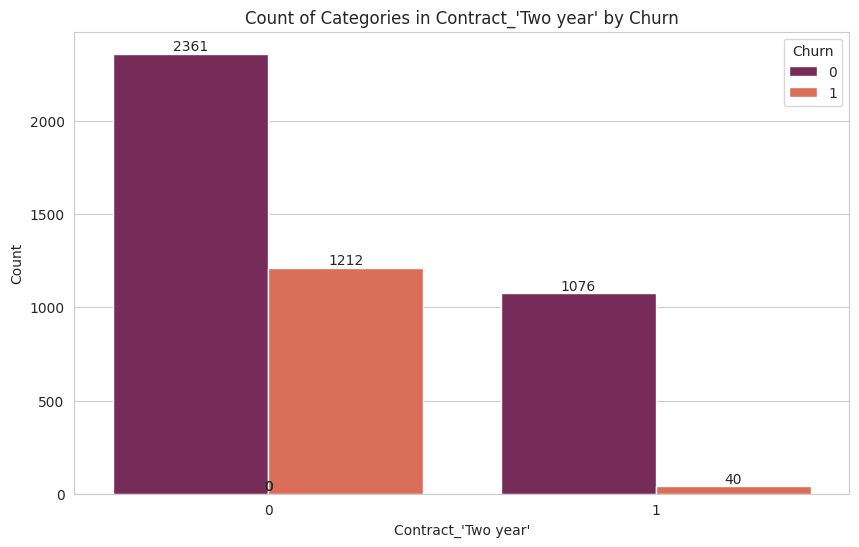

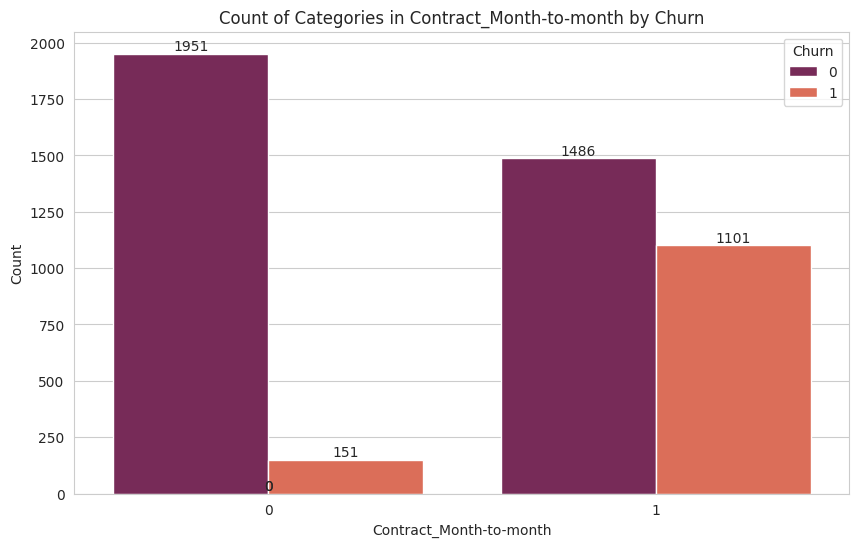

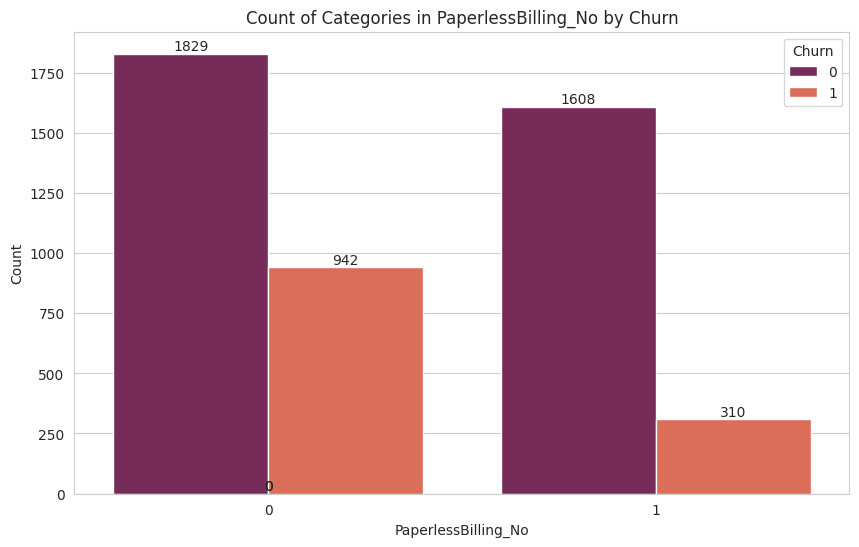

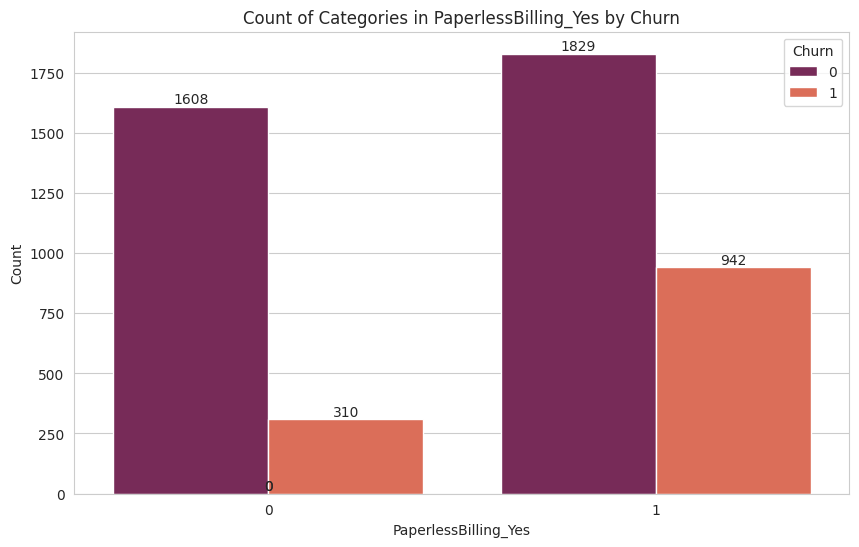

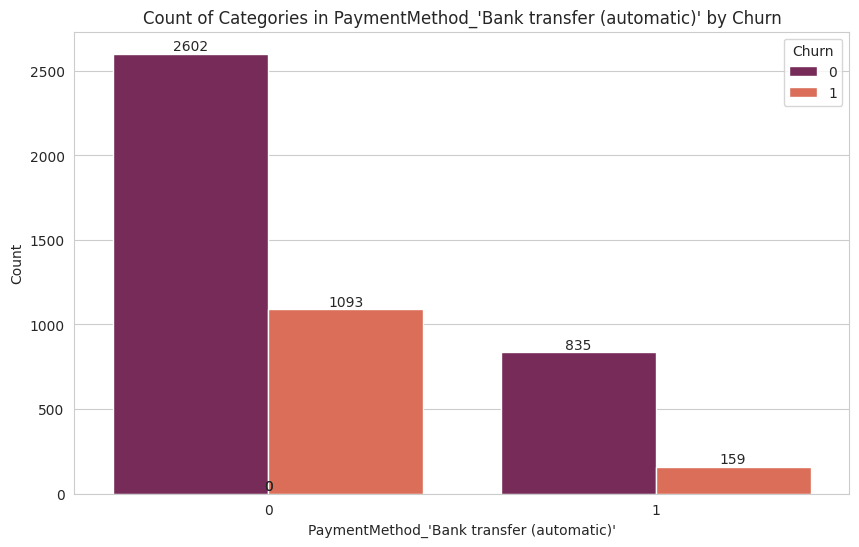

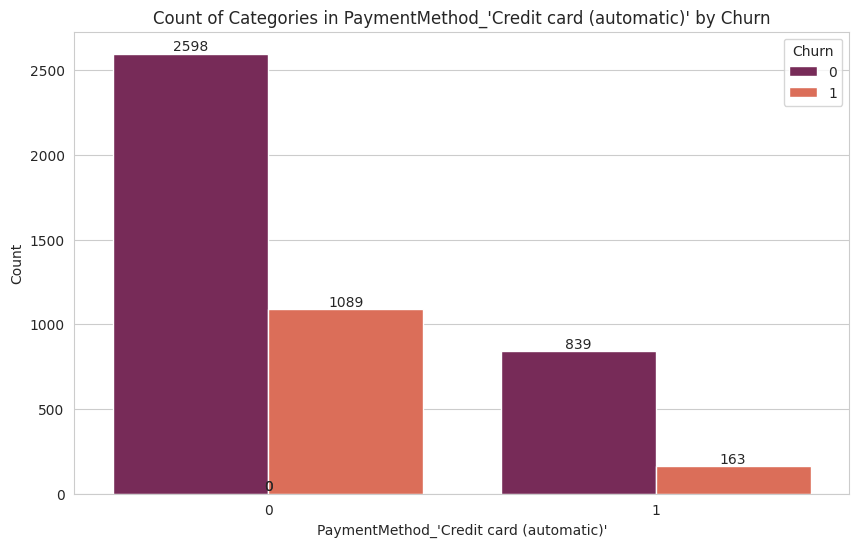

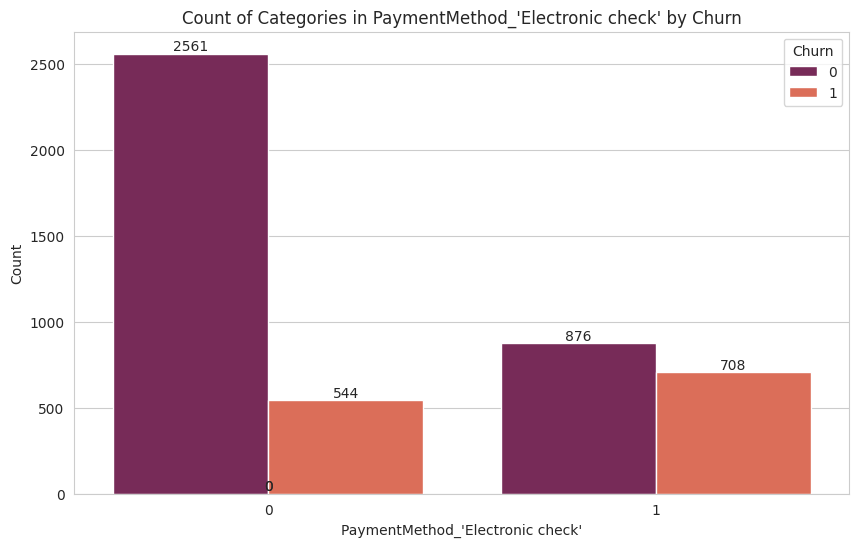

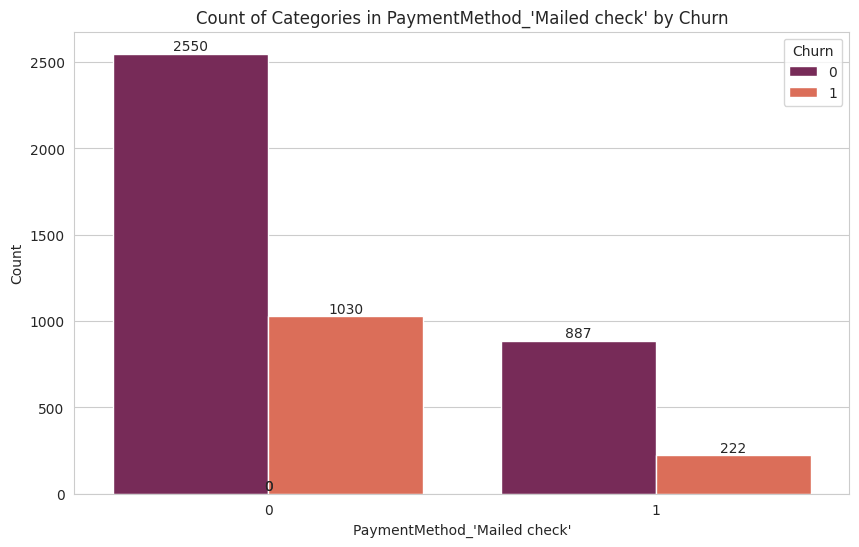

In [ ]:
plot_histo_bars(df_dummies,extra='withdummies')

#### Correlation

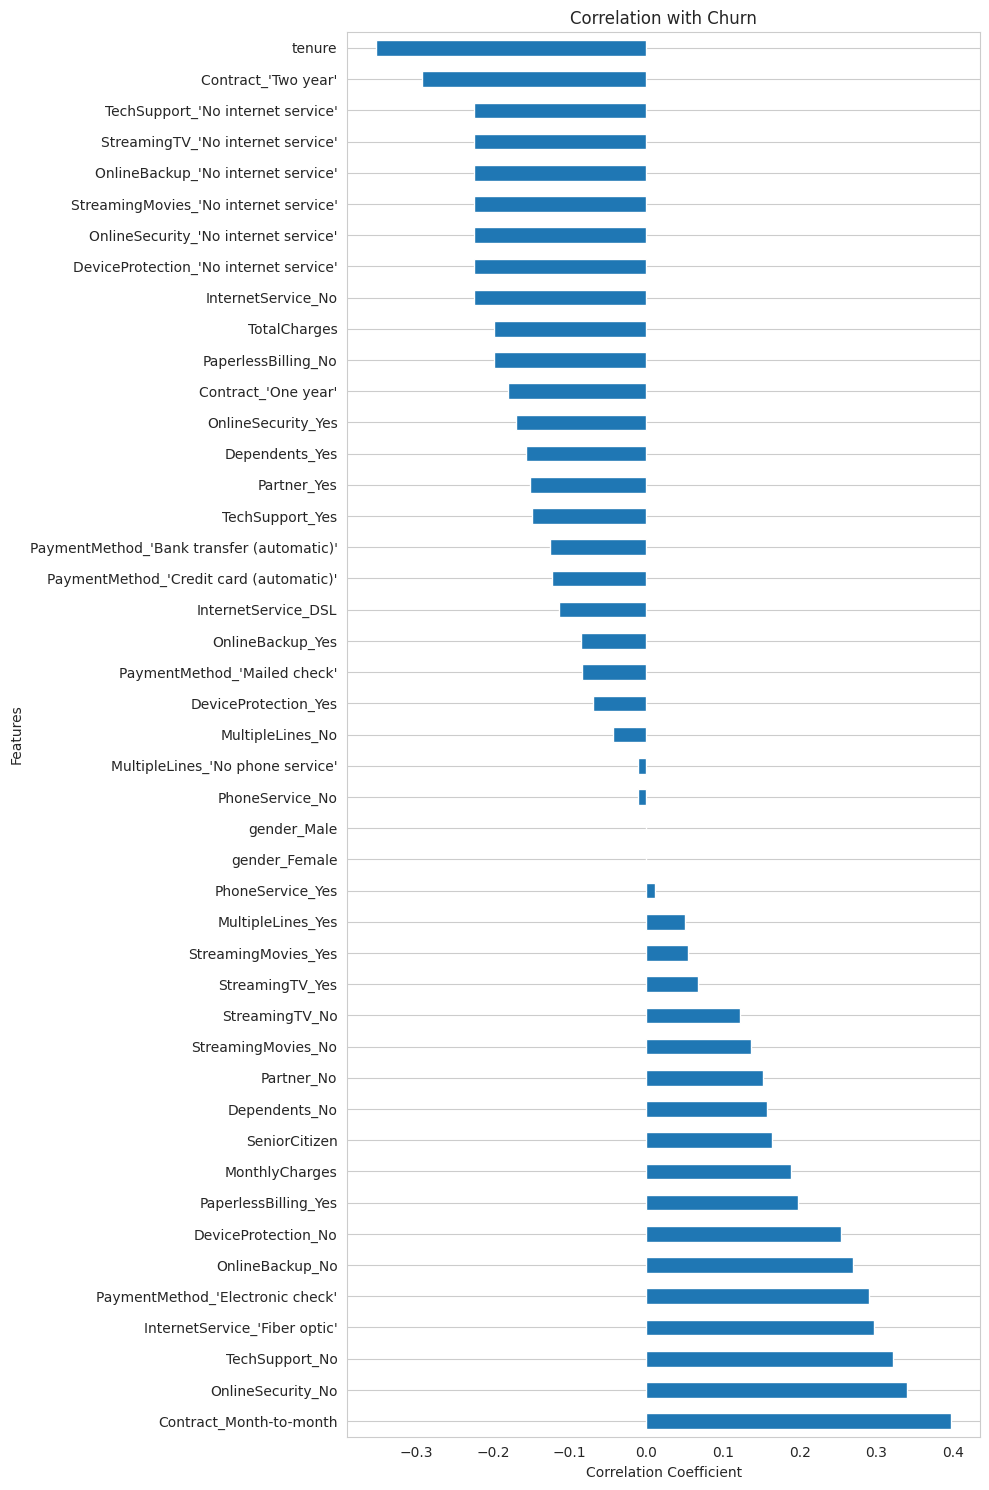

In [ ]:
plt.figure(figsize=(10, 15))
sorted_corr_matrix.drop('Churn').plot(kind='barh')

plt.title('Correlation with Churn')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')

plt.grid(axis='x')
plt.tight_layout()

save_figure("correlation_churn")
plt.show()

#### Correlation Heatmap

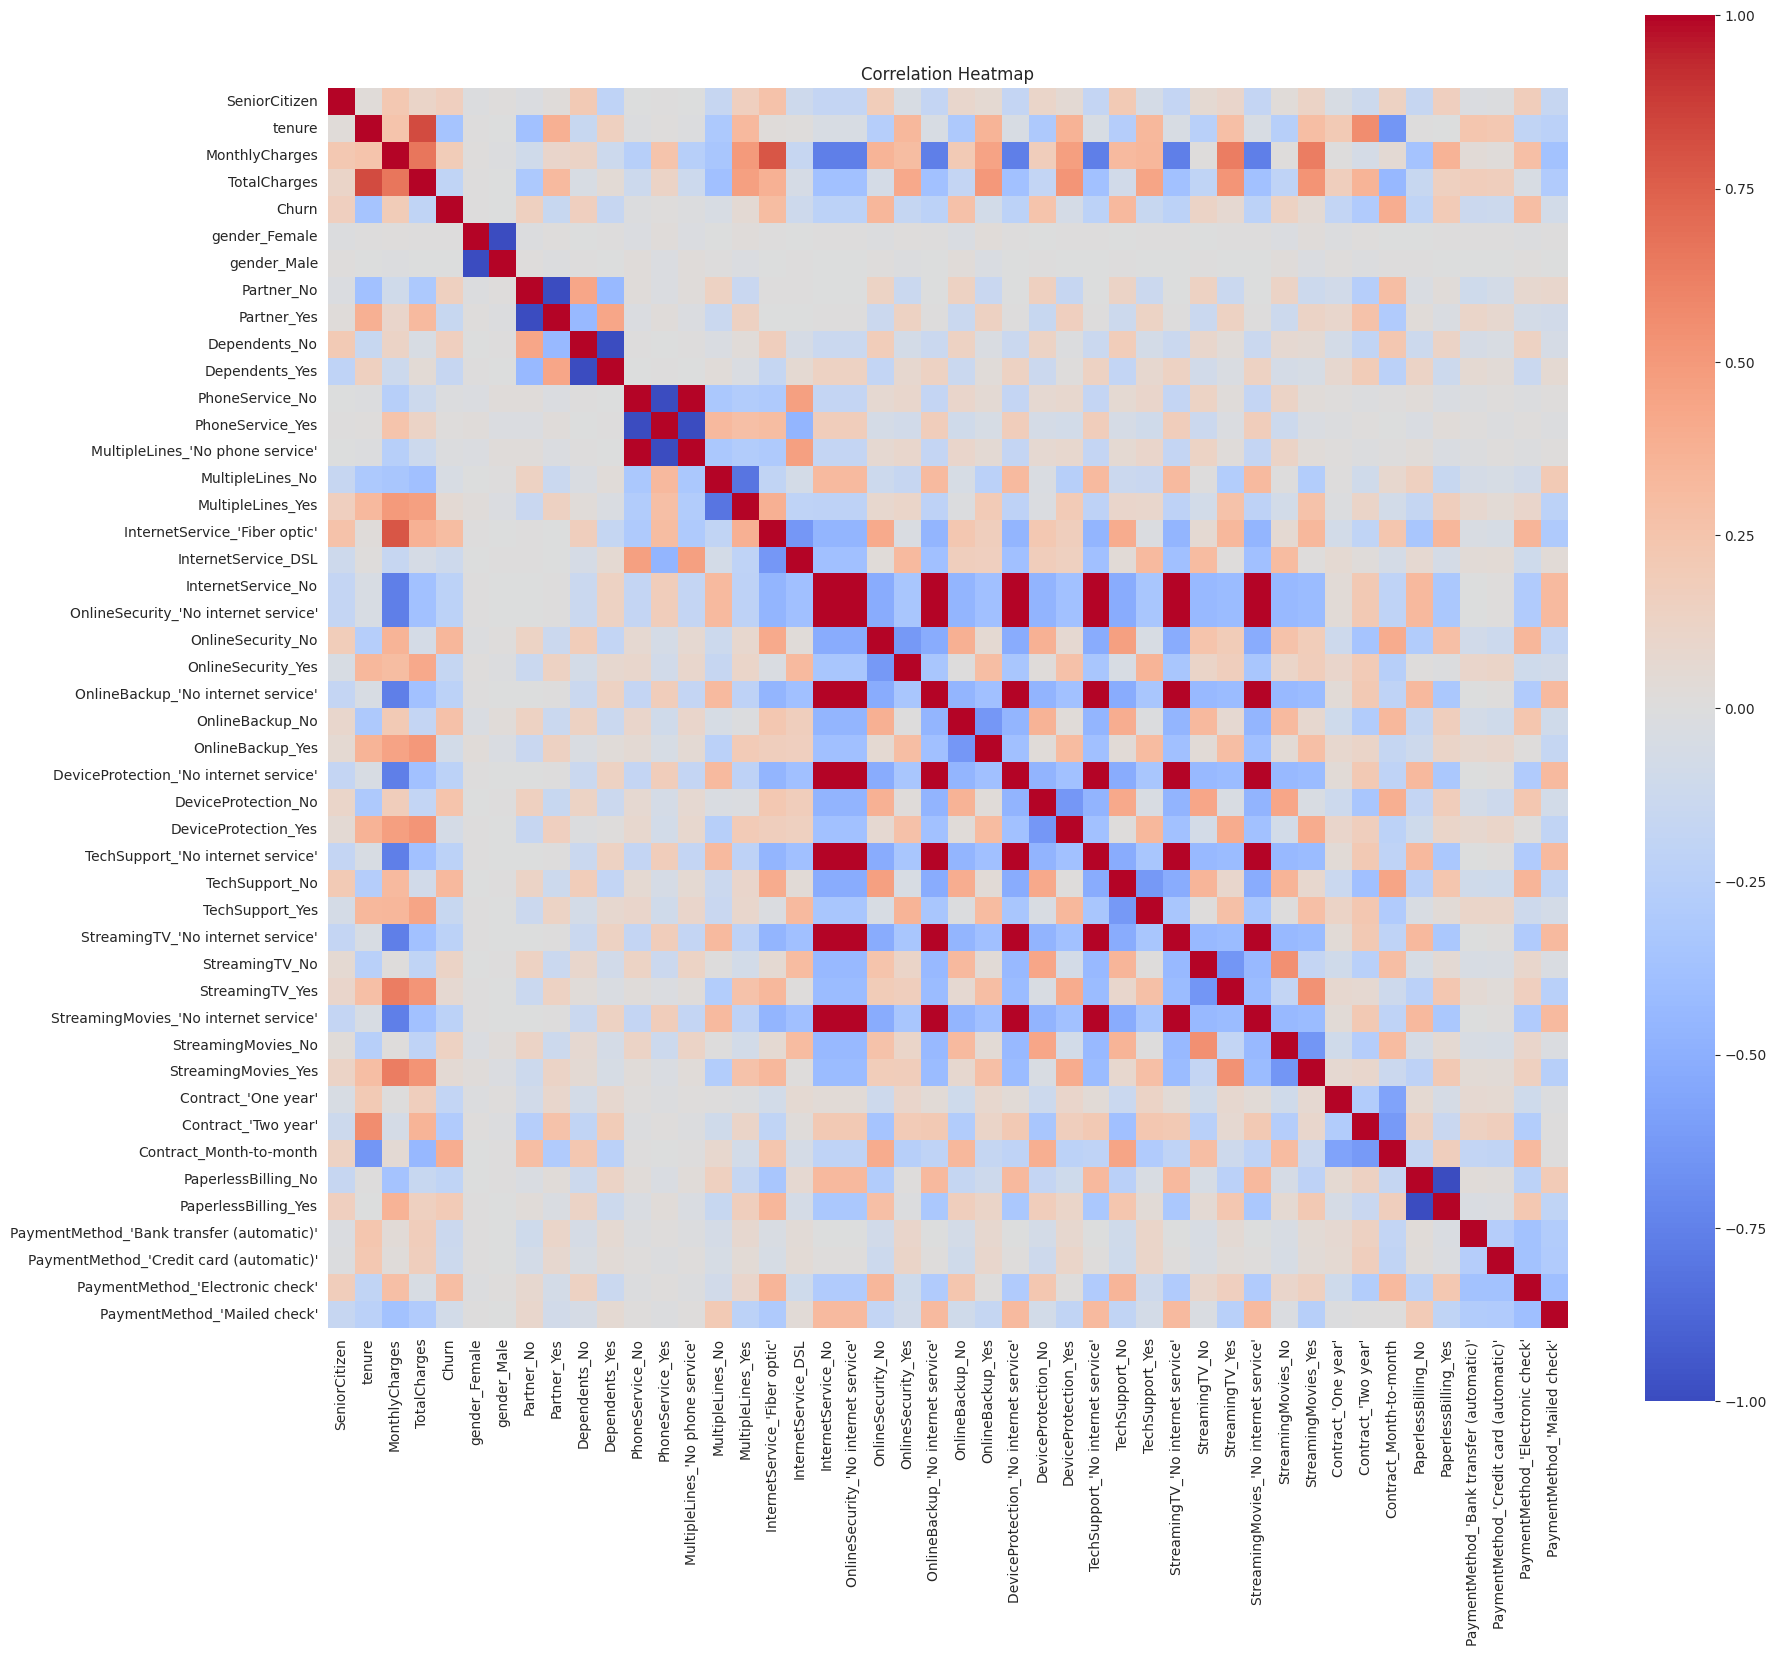

In [ ]:
plt.figure(figsize=(20,18))
sns.heatmap(df_corr_matrix, annot=False, fmt='.2f', cmap='coolwarm', cbar=True, square=True)
plt.title('Correlation Heatmap')
save_figure("correlation_heatmap")
plt.show()

# 3. Modeling

Lets try 2 models

## 3.1 Split the Dataset into Train and Validation sets.

In [ ]:
y = df_dummies['Churn']
X = df_dummies.drop('Churn', axis=1)

Standardize the dataset

In [ ]:
scaler = StandardScaler()
X_standardized = scaler.fit_transform(X)

Train split the dataset

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X_standardized, y, test_size=0.2, random_state=42, stratify=y)
X_train.shape, X_val.shape

((3751, 45), (938, 45))

## 3.2 Evaluation of the Models

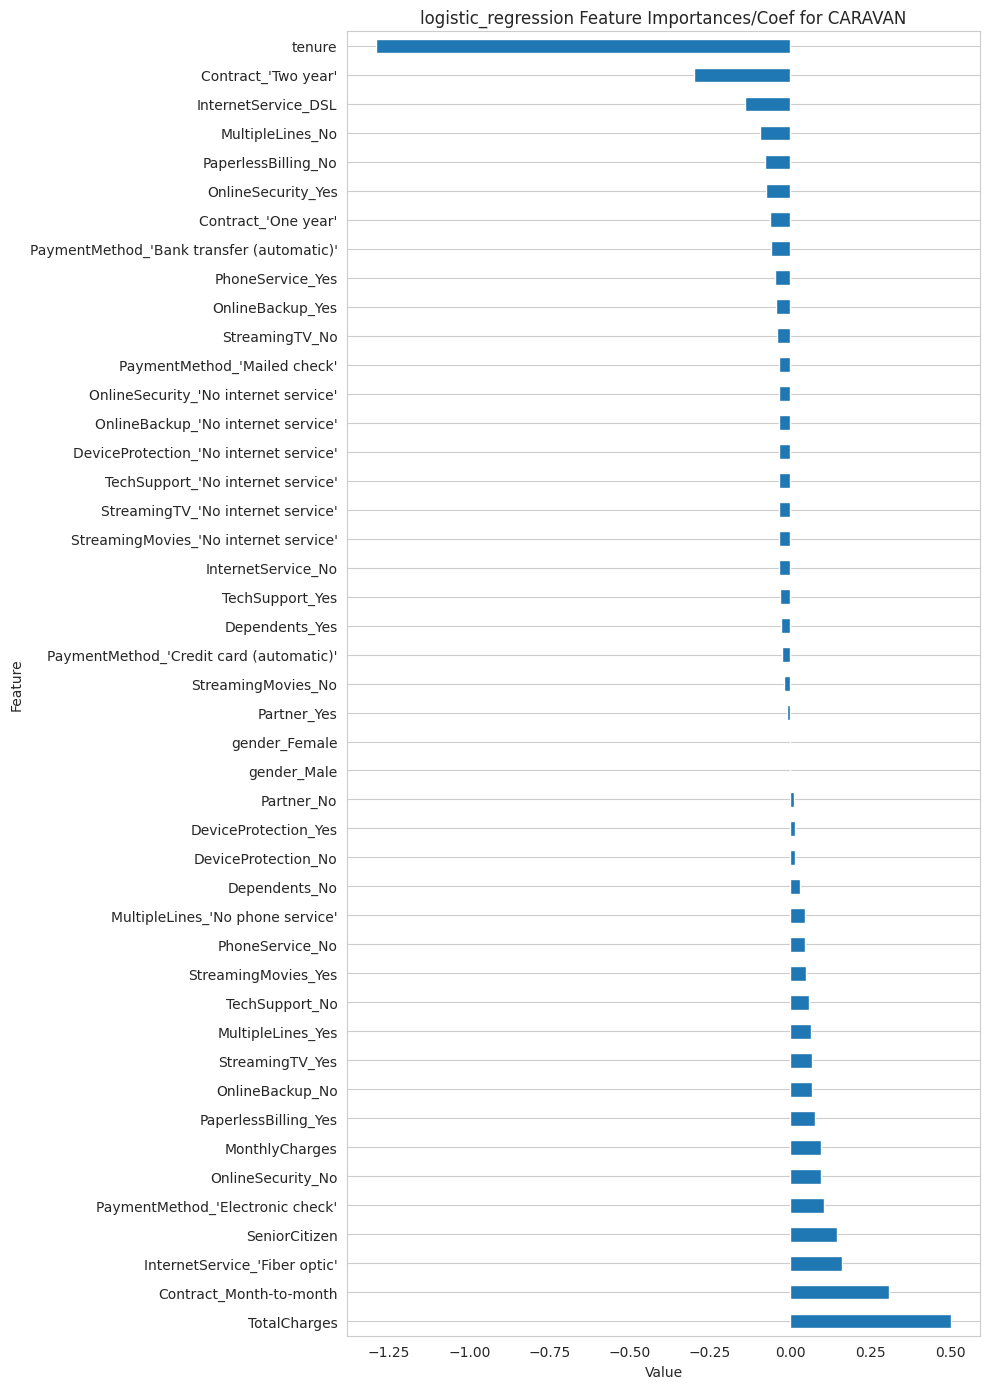

Model: logistic_regression
              precision    recall  f1-score   support

           0       0.85      0.89      0.87       688
           1       0.65      0.58      0.61       250

    accuracy                           0.81       938
   macro avg       0.75      0.73      0.74       938
weighted avg       0.80      0.81      0.80       938



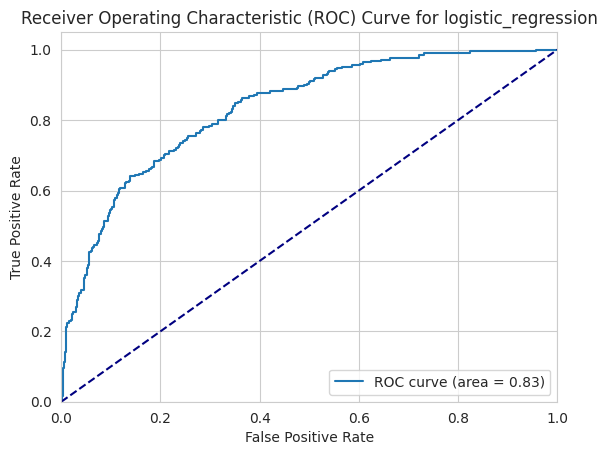

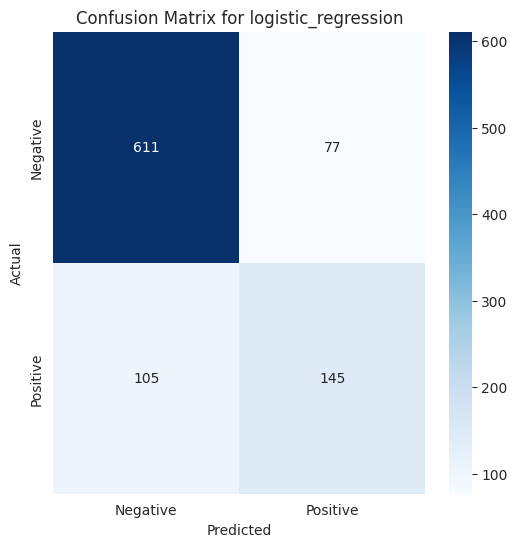

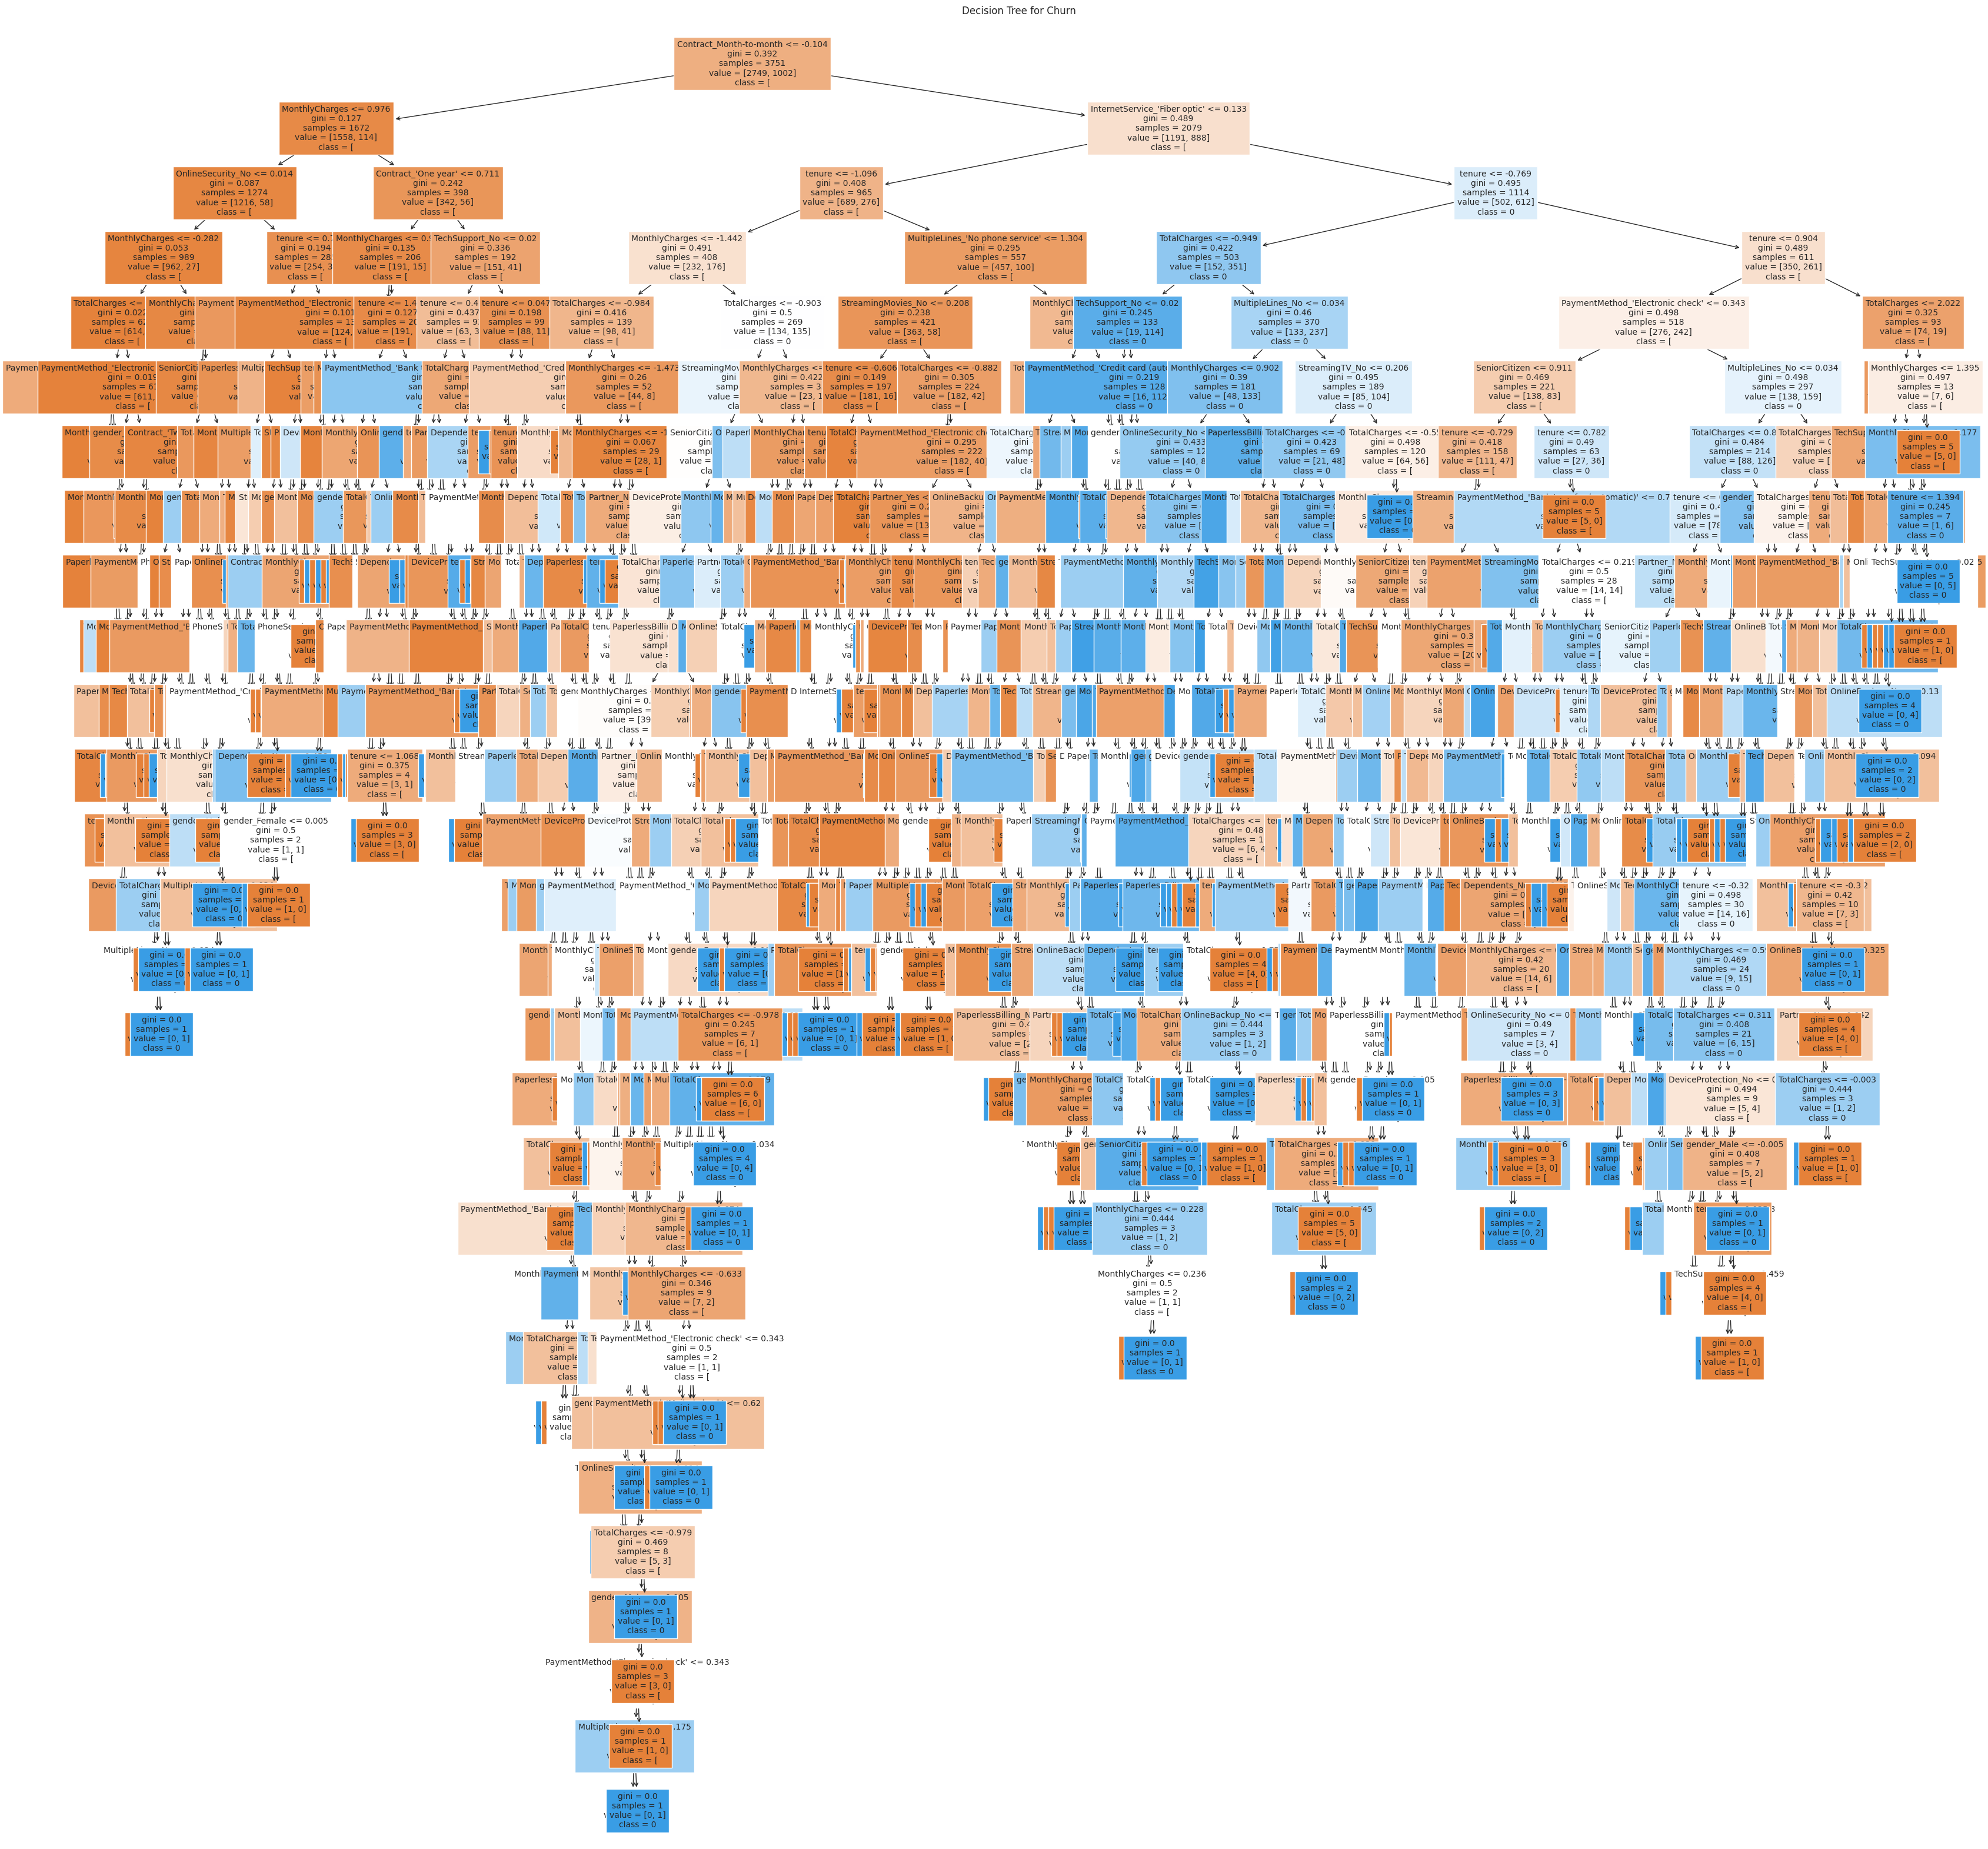

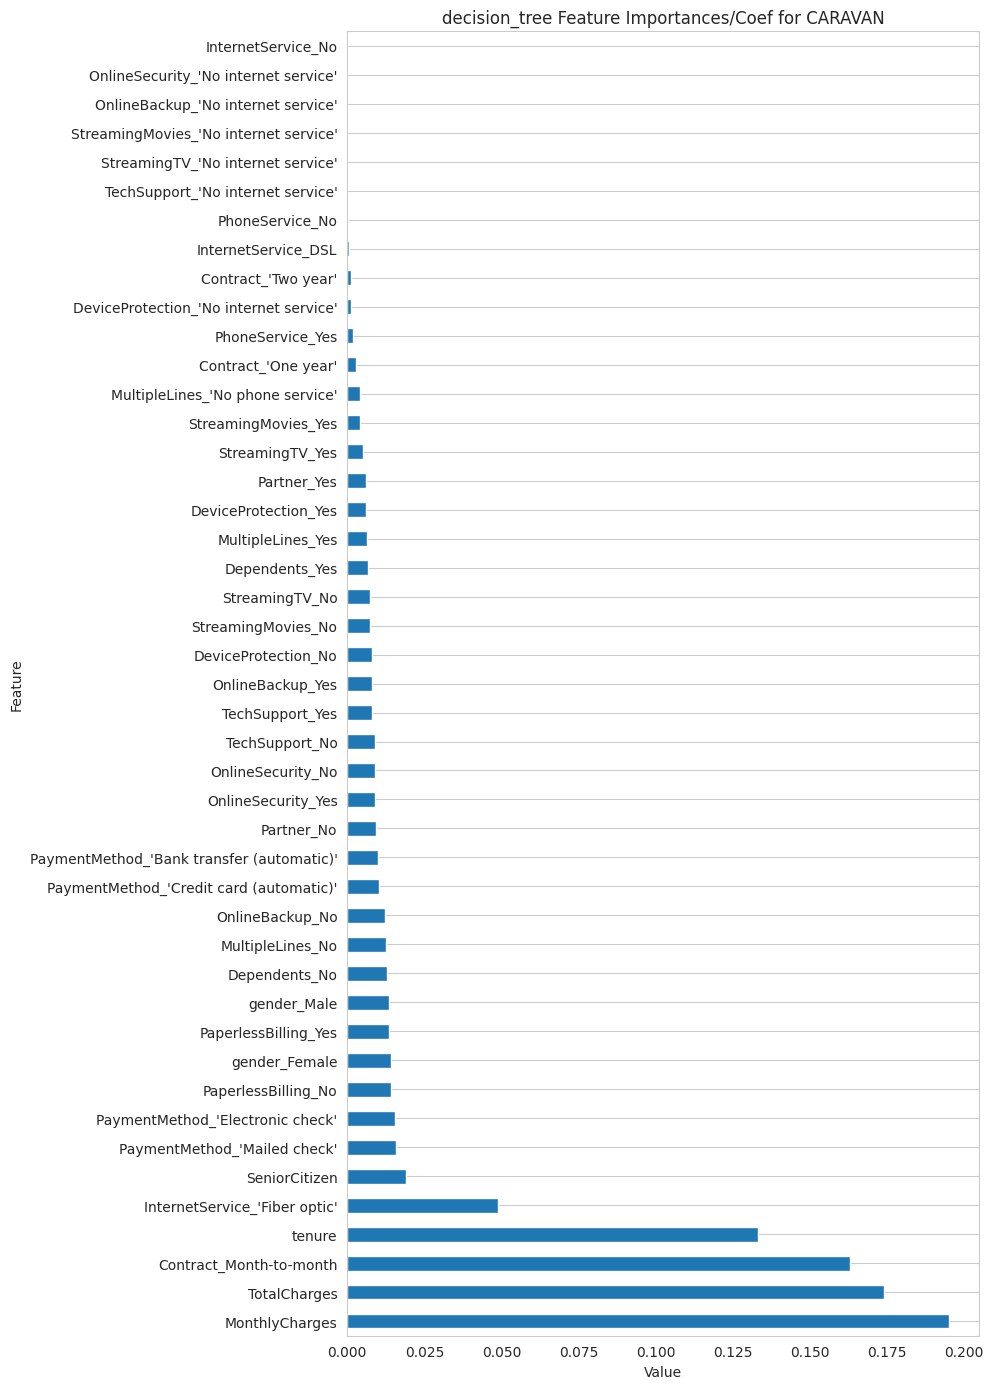

Model: decision_tree
              precision    recall  f1-score   support

           0       0.81      0.79      0.80       688
           1       0.47      0.50      0.49       250

    accuracy                           0.72       938
   macro avg       0.64      0.65      0.64       938
weighted avg       0.72      0.72      0.72       938



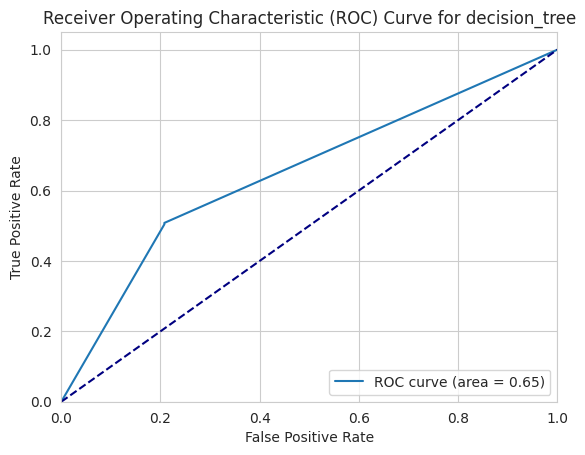

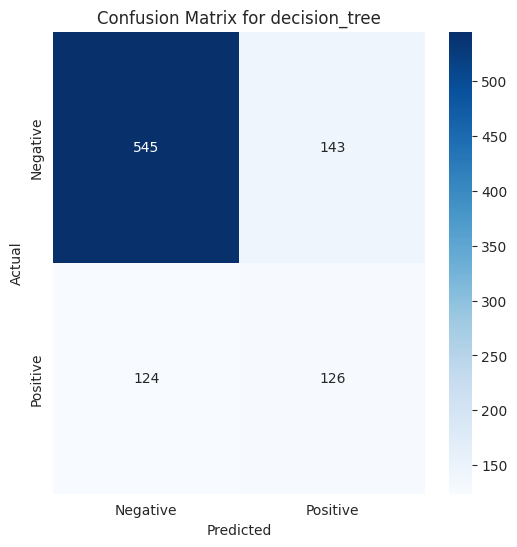

In [ ]:
models = {
    "logistic_regression": LogisticRegression(max_iter=1000),
    "decision_tree": DecisionTreeClassifier()
}

y_train_reshaped = np.array(y_train).reshape(-1,)
y_val_reshaped = np.array(y_val).reshape(-1,)

for model_name, model in models.items():
    model.fit(X_train, y_train_reshaped)
    model_important_features(model_name, model, X)
    model_metrics(model_name, model, X_val, y_val_reshaped)

# 4. Complete Pipelines

In [ ]:
y = df_dummies['Churn']
X = df_dummies.drop('Churn', axis=1)
attribute_names = X.columns

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train.shape, X_val.shape

((3751, 45), (938, 45))

## 4.1 PIPELINE

In [ ]:
# Models
models = {
    "logistic_regression": LogisticRegression(random_state=42, max_iter=1000),
    "decision_tree": DecisionTreeClassifier(random_state=42)
}

# Steps
steps = [
    ('resampler', SMOTE()),  # placeholder
    ('scaler', StandardScaler()),  # placeholder
    ('selector', SelectKBest(score_func=chi2)),  # placeholder
    ('classifier', models["decision_tree"])  # placeholder
]

# Create the pipeline
pipeline = imPipeline(steps)

# Parameter grid for Decision Tree with SelectKBest
param_grid_dt_selectkbest = {
    'resampler': [SMOTE(), RandomUnderSampler()],
    'scaler': [None, StandardScaler(), MinMaxScaler()],
    'selector': [SelectKBest(score_func=chi2)],
    'selector__k': [5, 10, 15, 20, 25, 30],
    'classifier': [models["decision_tree"]],
    'classifier__max_depth': [None, 5, 10, 15, 20, 25, 30],
    'classifier__min_samples_split': [2, 4, 8, 16],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__criterion': ['gini', 'entropy']
}

# Parameter grid for Logistic Regression with SelectKBest
param_grid_lr_selectkbest = {
    'resampler': [SMOTE(), RandomUnderSampler()],
    'scaler': [None, StandardScaler(), MinMaxScaler()],
    'selector': [SelectKBest(score_func=chi2)],
    'selector__k': [5, 10, 15, 20, 25, 30],
    'classifier': [models["logistic_regression"]],
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__penalty': ['l2'],
    'classifier__solver': ['lbfgs', 'liblinear', 'saga']
}

# Parameter grid for Decision Tree with RFE
param_grid_dt_rfe = {
    'resampler': [SMOTE(), RandomUnderSampler()],
    'scaler': [None, StandardScaler(), MinMaxScaler()],
    'selector': [RFE(estimator=models["decision_tree"])],
    'selector__n_features_to_select': [5, 10, 15, 20, 25, 30],
    'classifier': [models["decision_tree"]],
    'classifier__max_depth': [None, 5, 10, 15, 20, 25, 30],
    'classifier__min_samples_split': [2, 4, 8, 16],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__criterion': ['gini', 'entropy']
}

# Parameter grid for Logistic Regression with RFE
param_grid_lr_rfe = {
    'resampler': [SMOTE(), RandomUnderSampler()],
    'scaler': [None, StandardScaler(), MinMaxScaler()],
    'selector': [RFE(estimator=models["logistic_regression"])],
    'selector__n_features_to_select': [5, 10, 15, 20, 25, 30],
    'classifier': [models["logistic_regression"]],
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__penalty': ['l2'],
    'classifier__solver': ['lbfgs', 'liblinear', 'saga']
}

# Combine all parameter grids
param_grid = [
    param_grid_dt_selectkbest,
    param_grid_lr_selectkbest,
    param_grid_dt_rfe,
    param_grid_lr_rfe
]

In [ ]:
iterations = 1000
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
best_pipelines = []
best_features = []
results_pipeline = []

## 4.2 FOR ACCURACY

In [ ]:
scoring = "accuracy"
best_estimator,best_params,results = random_cv(X_train, y_train, scoring, param_grid, iterations)
upload_pipeline()
upload_results()

In [ ]:
best_params

{'selector__k': 25,
 'selector': SelectKBest(k=25, score_func=<function chi2 at 0x79ab3ec41240>),
 'scaler': MinMaxScaler(),
 'resampler': SMOTE(),
 'classifier__solver': 'lbfgs',
 'classifier__penalty': 'l2',
 'classifier__C': 100,
 'classifier': LogisticRegression(C=100, max_iter=1000, random_state=42)}

In [ ]:
best_estimator

Pipeline(steps=[('resampler', SMOTE()), ('scaler', MinMaxScaler()),
                ('selector',
                 SelectKBest(k=25,
                             score_func=<function chi2 at 0x79ab3ec41240>)),
                ('classifier',
                 LogisticRegression(C=100, max_iter=1000, random_state=42))])

Accuracy: 0.7857142857142857
Precision: 0.5910780669144982
Recall: 0.636
F1 Score: 0.6127167630057804
ROC-AUC: 0.8212732558139536


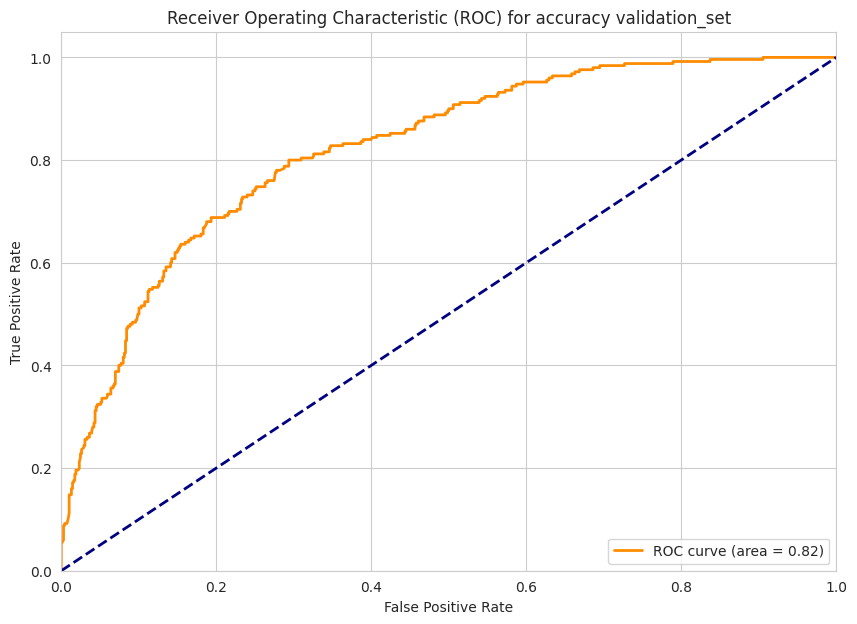

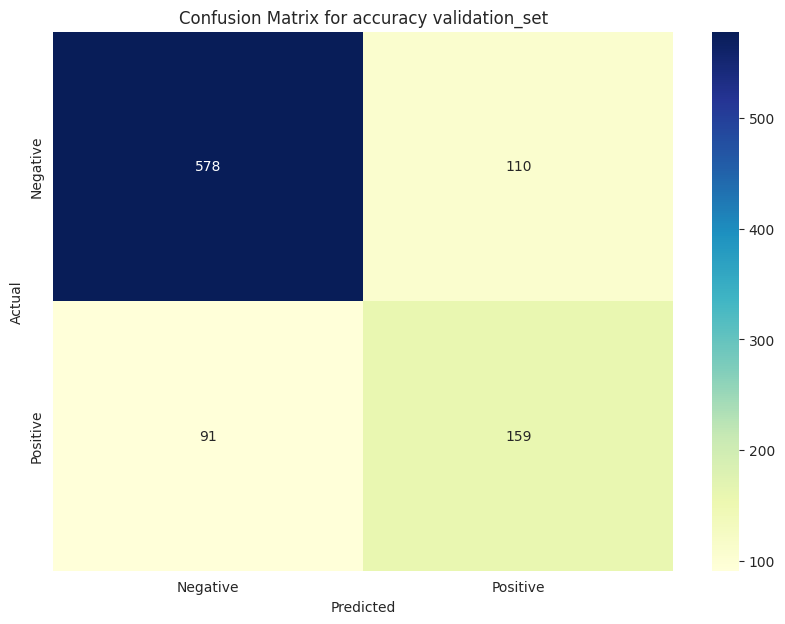

In [ ]:
final_model_evaluation(scoring, best_estimator, X_val, y_val, 'validation_set')

In [ ]:
feat_chos = feature_chosen(best_estimator)
feat_chos

array([5.13903743e+00, 2.98124799e+02, 4.55053854e+01, 8.63416048e+01,
       8.82280088e+01, 5.55335556e+01, 1.11344357e+01, 3.66031527e+02,
       1.28798239e+01, 3.96337298e+02, 2.43203463e+01, 5.54325543e-01,
       2.43203463e+01, 7.12958478e+01, 6.88336520e+00, 2.57656859e+02,
       1.53376559e+02, 4.00017544e+02, 4.00017544e+02, 2.18788204e+02,
       4.04403540e+02, 4.00017544e+02, 1.38172495e+02, 1.94849765e+02,
       4.00017544e+02, 8.86055446e+01, 1.72371947e+02, 4.00017544e+02,
       2.10209115e+02, 3.66237095e+02, 4.00017544e+02, 1.10000000e+01,
       9.13513514e+00, 4.00017544e+02, 1.14486763e+01, 1.06175515e+01,
       4.39024390e+02, 7.45864253e+02, 3.79350748e+02, 4.71145994e+02,
       3.78448381e+01, 3.27901478e+02, 3.01321729e+02, 1.09984179e+02,
       1.51188034e+02])

In [ ]:
selected_indices = best_estimator.named_steps['selector'].get_support(indices=True)
selected_indices

array([ 1,  7,  9, 15, 16, 17, 18, 19, 20, 21, 23, 24, 26, 27, 28, 29, 30,
       33, 36, 37, 38, 39, 41, 42, 44])

In [ ]:
selected_feature_names = [attribute_names[i] for i in selected_indices]
best_features.append(selected_feature_names)
selected_feature_names

['tenure',
 'Partner_Yes',
 'Dependents_Yes',
 "InternetService_'Fiber optic'",
 'InternetService_DSL',
 'InternetService_No',
 "OnlineSecurity_'No internet service'",
 'OnlineSecurity_No',
 'OnlineSecurity_Yes',
 "OnlineBackup_'No internet service'",
 'OnlineBackup_Yes',
 "DeviceProtection_'No internet service'",
 'DeviceProtection_Yes',
 "TechSupport_'No internet service'",
 'TechSupport_No',
 'TechSupport_Yes',
 "StreamingTV_'No internet service'",
 "StreamingMovies_'No internet service'",
 "Contract_'One year'",
 "Contract_'Two year'",
 'Contract_Month-to-month',
 'PaperlessBilling_No',
 "PaymentMethod_'Bank transfer (automatic)'",
 "PaymentMethod_'Credit card (automatic)'",
 "PaymentMethod_'Mailed check'"]

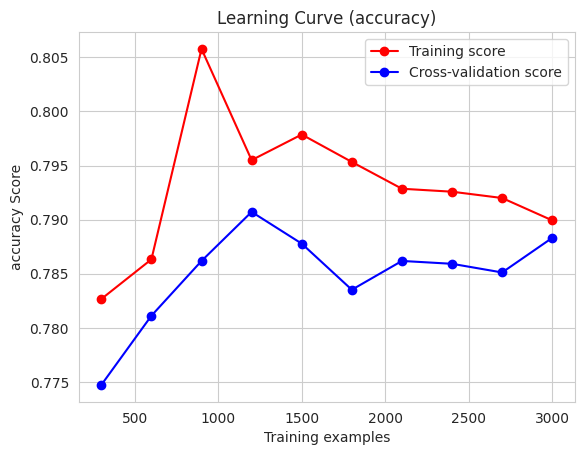

In [ ]:
plot_learning_curve(scoring, best_estimator, X_train, y_train)

## 4.3 FOR AUC

In [ ]:
scoring = "roc_auc"
best_estimator,best_params,results = random_cv(X_train, y_train, scoring, param_grid, iterations)
upload_pipeline()
upload_results()

In [ ]:
best_params

{'selector__n_features_to_select': 30,
 'selector': RFE(estimator=LogisticRegression(C=100, max_iter=1000, random_state=42,
                                  solver='saga'),
     n_features_to_select=30),
 'scaler': MinMaxScaler(),
 'resampler': RandomUnderSampler(),
 'classifier__solver': 'saga',
 'classifier__penalty': 'l2',
 'classifier__C': 100,
 'classifier': LogisticRegression(C=100, max_iter=1000, random_state=42, solver='saga')}

In [ ]:
best_estimator

Pipeline(steps=[('resampler', RandomUnderSampler()), ('scaler', MinMaxScaler()),
                ('selector',
                 RFE(estimator=LogisticRegression(C=100, max_iter=1000,
                                                  random_state=42,
                                                  solver='saga'),
                     n_features_to_select=30)),
                ('classifier',
                 LogisticRegression(C=100, max_iter=1000, random_state=42,
                                    solver='saga'))])

Accuracy: 0.7366737739872068
Precision: 0.5039164490861618
Recall: 0.772
F1 Score: 0.6097946287519748
ROC-AUC: 0.8322674418604652


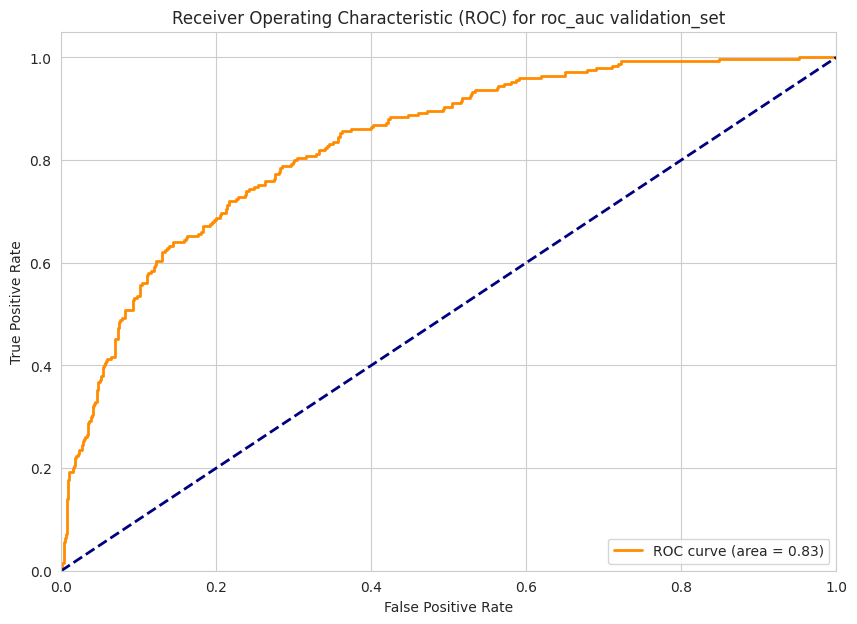

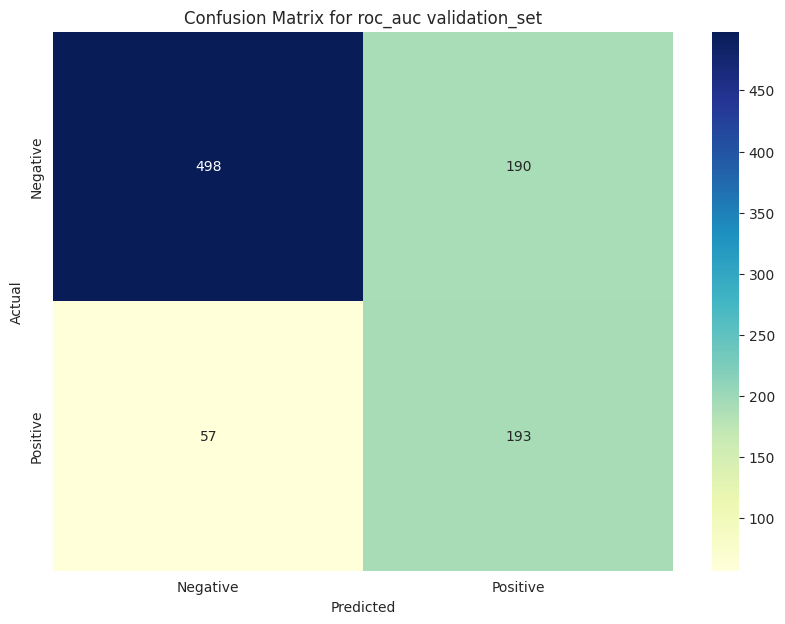

In [ ]:
final_model_evaluation(scoring, best_estimator, X_val, y_val, 'validation_set')

In [ ]:
feat_chos = feature_chosen(best_estimator)
feat_chos

array([ 1,  1,  1,  1, 14, 11,  5,  1,  6,  1, 12, 13,  2,  1,  3,  1,  1,
        1,  4,  1,  1,  1,  1,  9,  1, 10,  8,  1,  1, 16,  1,  1,  1,  1,
       15,  1,  1,  1,  1,  1,  1,  1,  7,  1,  1])

In [ ]:
selected_indices = best_estimator.named_steps['selector'].get_support(indices=True)
selected_indices

array([ 0,  1,  2,  3,  7,  9, 13, 15, 16, 17, 19, 20, 21, 22, 24, 27, 28,
       30, 31, 32, 33, 35, 36, 37, 38, 39, 40, 41, 43, 44])

In [ ]:
selected_feature_names = [attribute_names[i] for i in selected_indices]
best_features.append(selected_feature_names)
selected_feature_names

['SeniorCitizen',
 'tenure',
 'MonthlyCharges',
 'TotalCharges',
 'Partner_Yes',
 'Dependents_Yes',
 'MultipleLines_No',
 "InternetService_'Fiber optic'",
 'InternetService_DSL',
 'InternetService_No',
 'OnlineSecurity_No',
 'OnlineSecurity_Yes',
 "OnlineBackup_'No internet service'",
 'OnlineBackup_No',
 "DeviceProtection_'No internet service'",
 "TechSupport_'No internet service'",
 'TechSupport_No',
 "StreamingTV_'No internet service'",
 'StreamingTV_No',
 'StreamingTV_Yes',
 "StreamingMovies_'No internet service'",
 'StreamingMovies_Yes',
 "Contract_'One year'",
 "Contract_'Two year'",
 'Contract_Month-to-month',
 'PaperlessBilling_No',
 'PaperlessBilling_Yes',
 "PaymentMethod_'Bank transfer (automatic)'",
 "PaymentMethod_'Electronic check'",
 "PaymentMethod_'Mailed check'"]

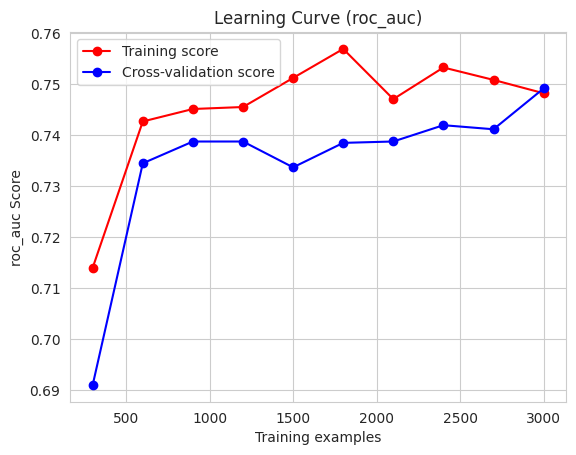

In [ ]:
plot_learning_curve(scoring, best_estimator, X_train, y_train)

## 4.4 FOR F1

In [ ]:
scoring = "f1"
best_estimator,best_params,results = random_cv(X_train, y_train, scoring, param_grid, iterations)
upload_pipeline()
upload_results()

In [ ]:
best_params

{'selector__n_features_to_select': 20,
 'selector': RFE(estimator=LogisticRegression(C=10, max_iter=1000, random_state=42,
                                  solver='liblinear'),
     n_features_to_select=20),
 'scaler': MinMaxScaler(),
 'resampler': RandomUnderSampler(),
 'classifier__solver': 'liblinear',
 'classifier__penalty': 'l2',
 'classifier__C': 10,
 'classifier': LogisticRegression(C=10, max_iter=1000, random_state=42, solver='liblinear')}

In [ ]:
best_estimator

Pipeline(steps=[('resampler', RandomUnderSampler()), ('scaler', MinMaxScaler()),
                ('selector',
                 RFE(estimator=LogisticRegression(C=10, max_iter=1000,
                                                  random_state=42,
                                                  solver='liblinear'),
                     n_features_to_select=20)),
                ('classifier',
                 LogisticRegression(C=10, max_iter=1000, random_state=42,
                                    solver='liblinear'))])

Accuracy: 0.7398720682302772
Precision: 0.5077720207253886
Recall: 0.784
F1 Score: 0.6163522012578617
ROC-AUC: 0.8326337209302326


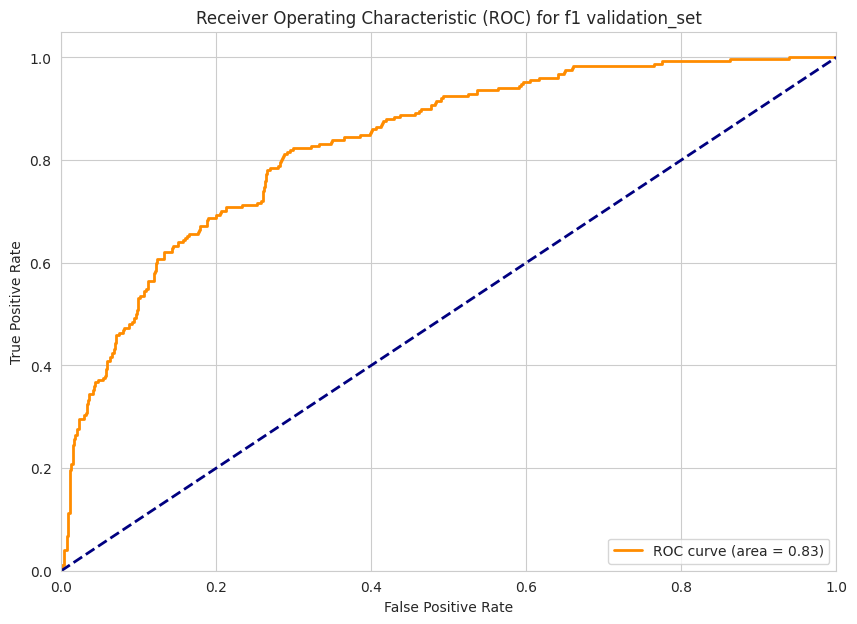

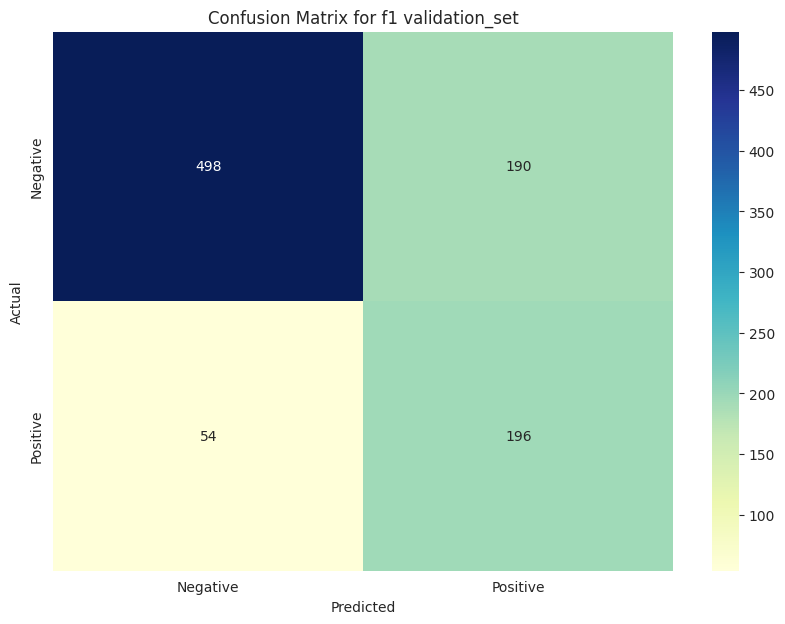

In [ ]:
final_model_evaluation(scoring, best_estimator, X_val, y_val, 'validation_set')

In [ ]:
feat_chos = feature_chosen(best_estimator)
feat_chos

array([ 1,  1,  1,  1, 21, 22, 16,  1,  1, 24,  1,  1,  1,  1, 19,  6,  3,
       10, 18,  2,  1, 13,  4,  1,  5,  1,  9, 17, 26, 20, 15, 12,  1,  7,
        8, 23, 25,  1,  1,  1, 11, 14,  1,  1,  1])

In [ ]:
selected_indices = best_estimator.named_steps['selector'].get_support(indices=True)
selected_indices

array([ 0,  1,  2,  3,  7,  8, 10, 11, 12, 13, 20, 23, 25, 32, 37, 38, 39,
       42, 43, 44])

In [ ]:
selected_feature_names = [attribute_names[i] for i in selected_indices]
best_features.append(selected_feature_names)
selected_feature_names

['SeniorCitizen',
 'tenure',
 'MonthlyCharges',
 'TotalCharges',
 'Partner_Yes',
 'Dependents_No',
 'PhoneService_No',
 'PhoneService_Yes',
 "MultipleLines_'No phone service'",
 'MultipleLines_No',
 'OnlineSecurity_Yes',
 'OnlineBackup_Yes',
 'DeviceProtection_No',
 'StreamingTV_Yes',
 "Contract_'Two year'",
 'Contract_Month-to-month',
 'PaperlessBilling_No',
 "PaymentMethod_'Credit card (automatic)'",
 "PaymentMethod_'Electronic check'",
 "PaymentMethod_'Mailed check'"]

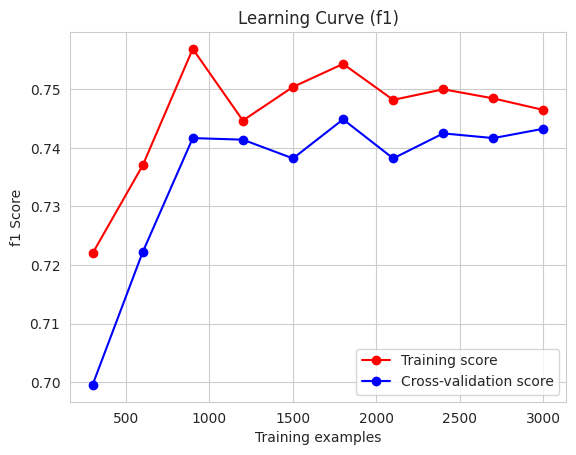

In [ ]:
plot_learning_curve(scoring, best_estimator, X_train, y_train)

## 4.5 FOR PRECISION

In [ ]:
scoring = "precision"
best_estimator,best_params,results = random_cv(X_train, y_train, scoring, param_grid, iterations)
upload_pipeline()
upload_results()

In [ ]:
best_params

{'selector__n_features_to_select': 30,
 'selector': RFE(estimator=LogisticRegression(C=100, max_iter=1000, random_state=42),
     n_features_to_select=30),
 'scaler': MinMaxScaler(),
 'resampler': SMOTE(),
 'classifier__solver': 'lbfgs',
 'classifier__penalty': 'l2',
 'classifier__C': 100,
 'classifier': LogisticRegression(C=100, max_iter=1000, random_state=42)}

In [ ]:
best_estimator

Pipeline(steps=[('resampler', SMOTE()), ('scaler', MinMaxScaler()),
                ('selector',
                 RFE(estimator=LogisticRegression(C=100, max_iter=1000,
                                                  random_state=42),
                     n_features_to_select=30)),
                ('classifier',
                 LogisticRegression(C=100, max_iter=1000, random_state=42))])

Accuracy: 0.7931769722814499
Precision: 0.6296296296296297
Recall: 0.544
F1 Score: 0.5836909871244635
ROC-AUC: 0.8206453488372093


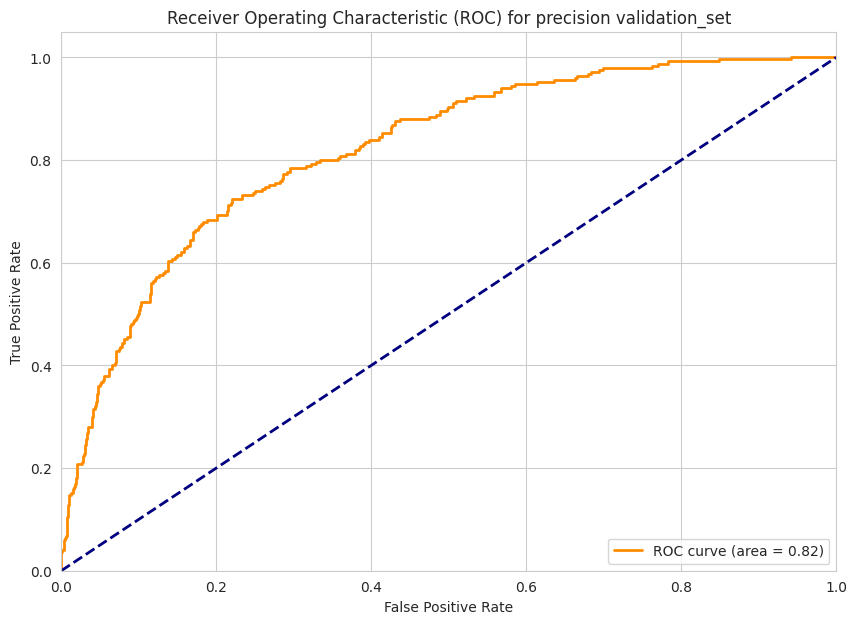

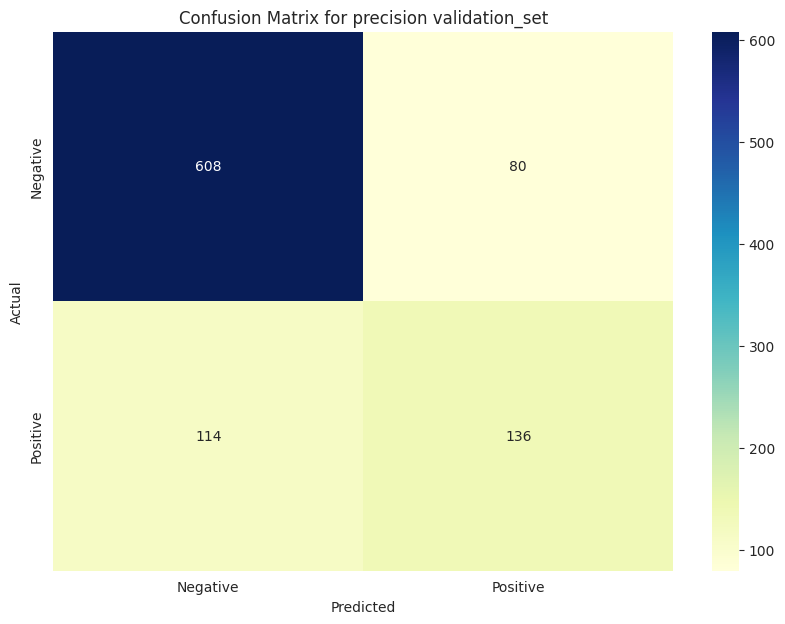

In [ ]:
final_model_evaluation(scoring, best_estimator, X_val, y_val, 'validation_set')

In [ ]:
feat_chos = feature_chosen(best_estimator)
feat_chos

array([14,  1,  3,  1,  1,  1,  1,  1,  1,  1, 12,  9,  6,  4,  5, 13, 16,
        1,  1,  8,  7,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  2,
        1,  1, 11, 10, 15,  1,  1,  1,  1,  1,  1])

In [ ]:
selected_indices = best_estimator.named_steps['selector'].get_support(indices=True)
selected_indices

array([ 1,  3,  4,  5,  6,  7,  8,  9, 17, 18, 21, 22, 23, 24, 25, 26, 27,
       28, 29, 30, 31, 32, 34, 35, 39, 40, 41, 42, 43, 44])

In [ ]:
selected_feature_names = [attribute_names[i] for i in selected_indices]
best_features.append(selected_feature_names)
selected_feature_names

['tenure',
 'TotalCharges',
 'gender_Female',
 'gender_Male',
 'Partner_No',
 'Partner_Yes',
 'Dependents_No',
 'Dependents_Yes',
 'InternetService_No',
 "OnlineSecurity_'No internet service'",
 "OnlineBackup_'No internet service'",
 'OnlineBackup_No',
 'OnlineBackup_Yes',
 "DeviceProtection_'No internet service'",
 'DeviceProtection_No',
 'DeviceProtection_Yes',
 "TechSupport_'No internet service'",
 'TechSupport_No',
 'TechSupport_Yes',
 "StreamingTV_'No internet service'",
 'StreamingTV_No',
 'StreamingTV_Yes',
 'StreamingMovies_No',
 'StreamingMovies_Yes',
 'PaperlessBilling_No',
 'PaperlessBilling_Yes',
 "PaymentMethod_'Bank transfer (automatic)'",
 "PaymentMethod_'Credit card (automatic)'",
 "PaymentMethod_'Electronic check'",
 "PaymentMethod_'Mailed check'"]

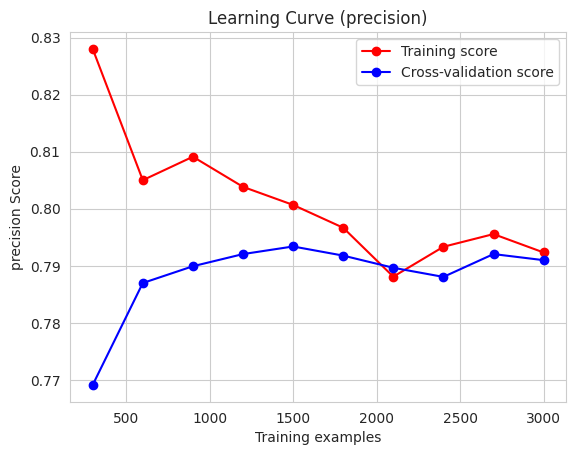

In [ ]:
plot_learning_curve(scoring, best_estimator, X_train, y_train)

## 4.6 FOR RECALL

In [ ]:
scoring = "recall"
best_estimator,best_params,results = random_cv(X_train, y_train, scoring, param_grid, iterations)
upload_pipeline()
upload_results()

In [ ]:
best_params

{'selector__k': 5,
 'selector': SelectKBest(k=5, score_func=<function chi2 at 0x79ab3ec41240>),
 'scaler': MinMaxScaler(),
 'resampler': RandomUnderSampler(),
 'classifier__solver': 'saga',
 'classifier__penalty': 'l2',
 'classifier__C': 0.1,
 'classifier': LogisticRegression(C=0.1, max_iter=1000, random_state=42, solver='saga')}

In [ ]:
best_estimator

Pipeline(steps=[('resampler', RandomUnderSampler()), ('scaler', MinMaxScaler()),
                ('selector',
                 SelectKBest(k=5,
                             score_func=<function chi2 at 0x79ab3ec41240>)),
                ('classifier',
                 LogisticRegression(C=0.1, max_iter=1000, random_state=42,
                                    solver='saga'))])

Accuracy: 0.6918976545842217
Precision: 0.45558086560364464
Recall: 0.8
F1 Score: 0.5805515239477503
ROC-AUC: 0.7523866279069767


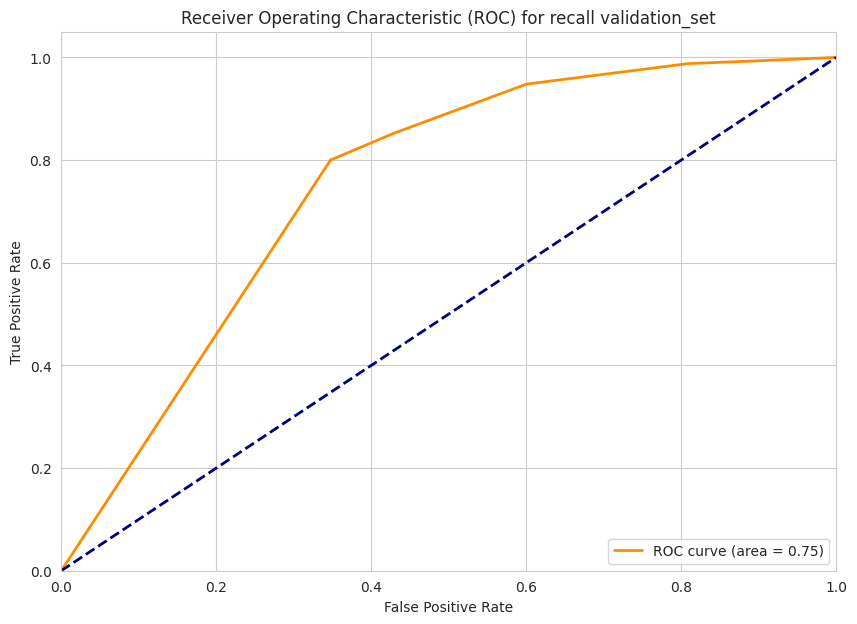

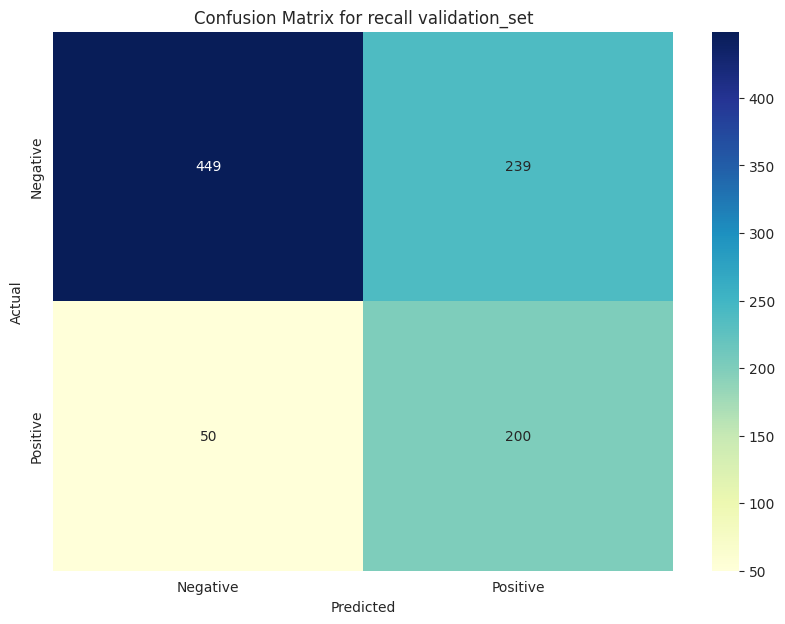

In [ ]:
final_model_evaluation(scoring, best_estimator, X_val, y_val, 'validation_set')

In [ ]:
feat_chos = feature_chosen(best_estimator)
feat_chos

array([5.13720930e+01, 9.61906094e+01, 1.86650234e+01, 2.65190528e+01,
       4.12371134e-03, 3.86847195e-03, 2.39025461e+01, 3.14739884e+01,
       1.78195842e+01, 5.17914230e+01, 1.26903553e-01, 1.38350858e-02,
       1.26903553e-01, 6.05450734e+00, 5.90973036e+00, 1.10899804e+02,
       2.08267717e+01, 1.39148148e+02, 1.39148148e+02, 1.27231760e+02,
       5.51147541e+01, 1.39148148e+02, 1.00787402e+02, 1.53861852e+01,
       1.39148148e+02, 7.36039216e+01, 4.43759874e+00, 1.39148148e+02,
       1.08321368e+02, 3.77329193e+01, 1.39148148e+02, 2.27584650e+01,
       8.13689700e+00, 1.39148148e+02, 2.86284404e+01, 5.08194622e+00,
       8.82564841e+01, 2.32361194e+02, 1.55912254e+02, 6.74094708e+01,
       3.76360809e+01, 3.42732240e+01, 2.63557423e+01, 1.11554070e+02,
       1.92925764e+01])

In [ ]:
selected_indices = best_estimator.named_steps['selector'].get_support(indices=True)
selected_indices

array([27, 30, 33, 37, 38])

In [ ]:
selected_feature_names = [attribute_names[i] for i in selected_indices]
best_features.append(selected_feature_names)
selected_feature_names

["TechSupport_'No internet service'",
 "StreamingTV_'No internet service'",
 "StreamingMovies_'No internet service'",
 "Contract_'Two year'",
 'Contract_Month-to-month']

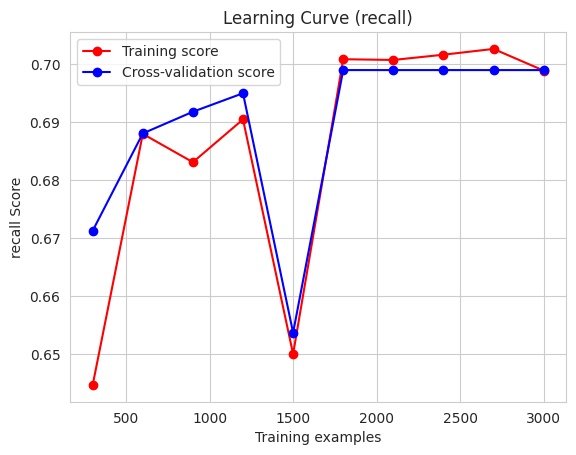

In [ ]:
plot_learning_curve(scoring, best_estimator, X_train, y_train)

# 5. Explain the Features

In [ ]:
flat_list = list(itertools.chain.from_iterable(best_features))
feature_counts = Counter(flat_list)

feature_names = []
counts = []

for feature, count in feature_counts.items():
    feature_names.append(feature)
    counts.append(count)

data = {
    'Feature Name': feature_names,
    'Count': counts
}

feature_df = pd.DataFrame(data)
feature_df = feature_df.sort_values(by='Count', ascending=False)
print(feature_df)

                                 Feature Name  Count
0                                      tenure      4
24               PaymentMethod_'Mailed check'      4
1                                 Partner_Yes      4
21                        PaperlessBilling_No      4
20                    Contract_Month-to-month      4
19                        Contract_'Two year'      4
16          StreamingTV_'No internet service'      4
13          TechSupport_'No internet service'      4
14                             TechSupport_No      3
34           PaymentMethod_'Electronic check'      3
31                            StreamingTV_Yes      3
27                               TotalCharges      3
23    PaymentMethod_'Credit card (automatic)'      3
17      StreamingMovies_'No internet service'      3
22  PaymentMethod_'Bank transfer (automatic)'      3
11     DeviceProtection_'No internet service'      3
10                           OnlineBackup_Yes      3
9          OnlineBackup_'No internet service' 

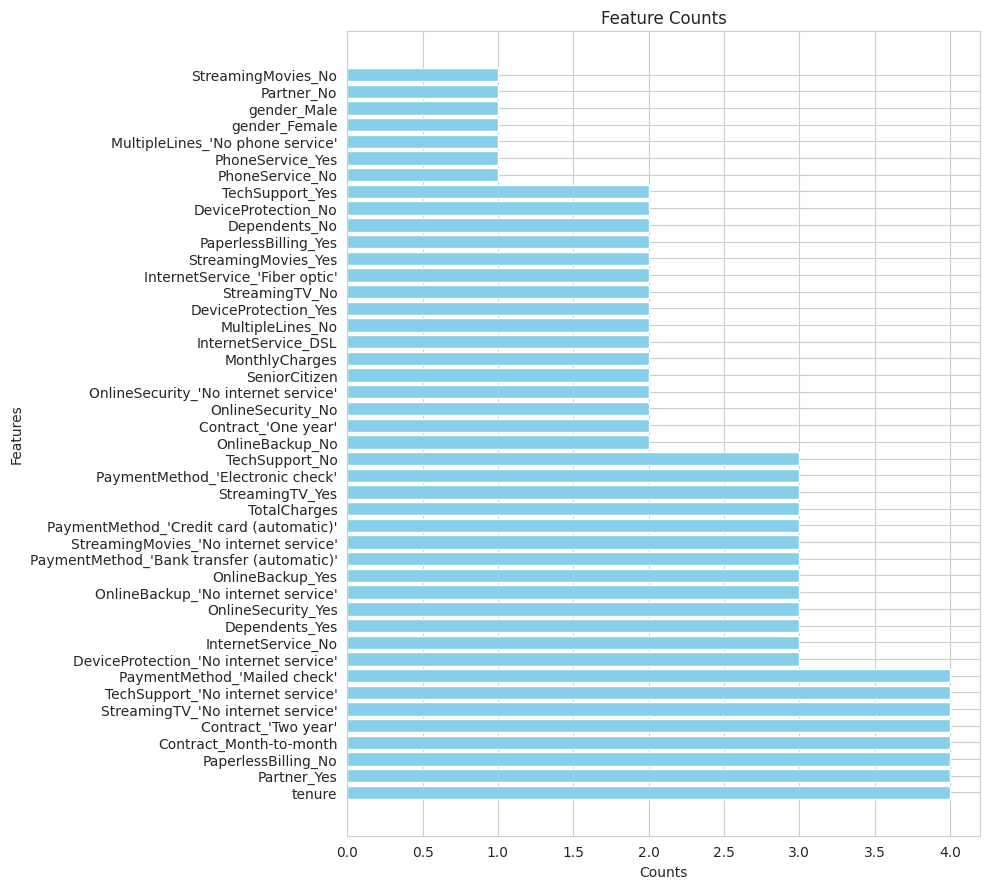

In [ ]:
feature_df = feature_df.sort_values(by='Count', ascending=False)

plt.figure(figsize=(10, 9))
plt.barh(feature_df['Feature Name'], feature_df['Count'], color='skyblue')
plt.xlabel('Counts')
plt.ylabel('Features')
plt.title('Feature Counts')
plt.tight_layout()

save_figure("feature_all_metrics")
plt.show()

# 6. Use the Best Model for solving the Churn Problem

PREDICTING THE 300 customers and the cost

Load the model based on recall

In [ ]:
i = 1
best_estimator, best_params, scoring = best_pipelines[-i]['best_estimator'], best_pipelines[-i]['best_params'], best_pipelines[-i]['scoring_method']
best_estimator, best_params, scoring

(Pipeline(steps=[('resampler', RandomUnderSampler()), ('scaler', MinMaxScaler()),
                 ('selector',
                  SelectKBest(k=5,
                              score_func=<function chi2 at 0x79ab3ec41240>)),
                 ('classifier',
                  LogisticRegression(C=0.1, max_iter=1000, random_state=42,
                                     solver='saga'))]),
 {'selector__k': 5,
  'selector': SelectKBest(k=5, score_func=<function chi2 at 0x79ab3ec41240>),
  'scaler': MinMaxScaler(),
  'resampler': RandomUnderSampler(),
  'classifier__solver': 'saga',
  'classifier__penalty': 'l2',
  'classifier__C': 0.1,
  'classifier': LogisticRegression(C=0.1, max_iter=1000, random_state=42, solver='saga')},
 'recall')

The parameters of the pipeline

In [ ]:
best_params

{'selector__k': 5,
 'selector': SelectKBest(k=5, score_func=<function chi2 at 0x79ab3ec41240>),
 'scaler': MinMaxScaler(),
 'resampler': RandomUnderSampler(),
 'classifier__solver': 'saga',
 'classifier__penalty': 'l2',
 'classifier__C': 0.1,
 'classifier': LogisticRegression(C=0.1, max_iter=1000, random_state=42, solver='saga')}

The best model for recall

In [ ]:
best_estimator

Pipeline(steps=[('resampler', RandomUnderSampler()), ('scaler', MinMaxScaler()),
                ('selector',
                 SelectKBest(k=5,
                             score_func=<function chi2 at 0x79ab3ec41240>)),
                ('classifier',
                 LogisticRegression(C=0.1, max_iter=1000, random_state=42,
                                    solver='saga'))])

In [ ]:
scoring

'recall'

In [ ]:
selected_indices = best_estimator.named_steps['selector'].get_support(indices=True)
selected_indices

array([27, 30, 33, 37, 38])

In [ ]:
selected_feature_names = [attribute_names[i] for i in selected_indices]
# best_features.append(selected_feature_names)
selected_feature_names

["TechSupport_'No internet service'",
 "StreamingTV_'No internet service'",
 "StreamingMovies_'No internet service'",
 "Contract_'Two year'",
 'Contract_Month-to-month']

The test set

In [ ]:
test_df_dummies.columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'gender_Female', 'gender_Male', 'Partner_No', 'Partner_Yes',
       'Dependents_No', 'Dependents_Yes', 'PhoneService_No',
       'PhoneService_Yes', 'MultipleLines_'No phone service'',
       'MultipleLines_No', 'MultipleLines_Yes',
       'InternetService_'Fiber optic'', 'InternetService_DSL',
       'InternetService_No', 'OnlineSecurity_'No internet service'',
       'OnlineSecurity_No', 'OnlineSecurity_Yes',
       'OnlineBackup_'No internet service'', 'OnlineBackup_No',
       'OnlineBackup_Yes', 'DeviceProtection_'No internet service'',
       'DeviceProtection_No', 'DeviceProtection_Yes',
       'TechSupport_'No internet service'', 'TechSupport_No',
       'TechSupport_Yes', 'StreamingTV_'No internet service'',
       'StreamingTV_No', 'StreamingTV_Yes',
       'StreamingMovies_'No internet service'', 'StreamingMovies_No',
       'StreamingMovies_Yes', 'Contract_'One year'', 'Contract_'Two year'',

In [ ]:
y = test_df_dummies['Churn']
X = test_df_dummies.drop('Churn', axis=1)

The evaluation of the model for the test.

Accuracy: 0.70550576184379
Precision: 0.4676131322094055
Recall: 0.8541329011345219
F1 Score: 0.6043577981651376
ROC-AUC: 0.7769291660954305


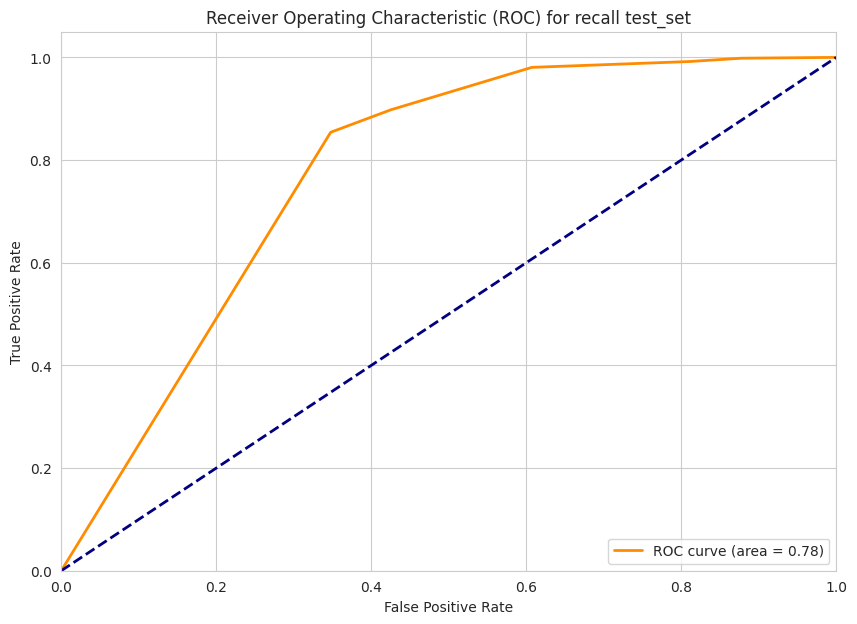

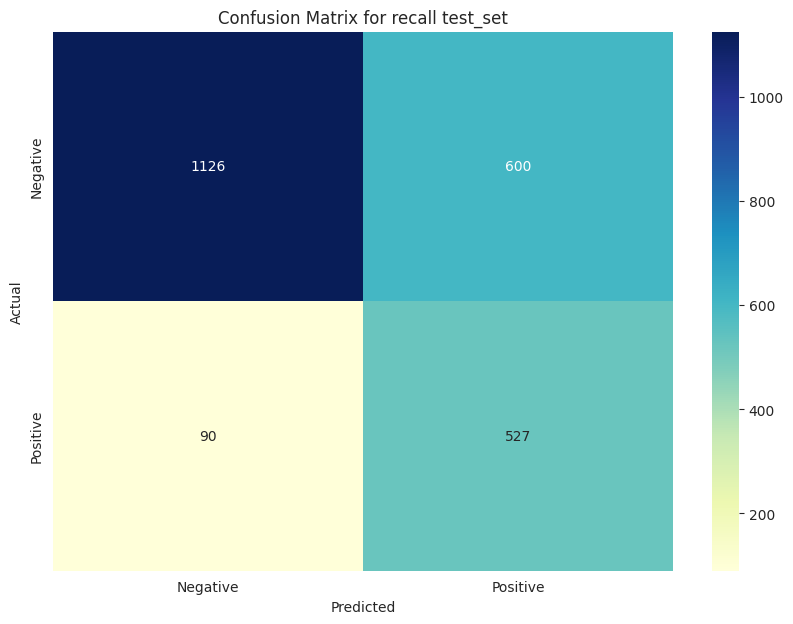

In [ ]:
final_model_evaluation(scoring, best_estimator, X, y, 'test_set')

Lets chose the 300 customers with the highest probabilities to have Churn as 1.

In [ ]:
proba = best_estimator.predict_proba(X)
positive_class_proba = proba[:, 1]

In [ ]:
results = pd.DataFrame({
    'CustomerID': X.index,
    'Probability': positive_class_proba,
    'Churn': y.values
})

In [ ]:
top_300 = results.sort_values(by='Probability', ascending=False).head(300)

In [ ]:
the_top_300 = top_300.reset_index(drop=True)
the_top_300

,CustomerID,Probability,Churn
0,0,0.691741,0
1,1278,0.691741,0
2,1301,0.691741,0
3,1300,0.691741,1
4,1295,0.691741,1
...,...,...,...
295,1079,0.691741,1
296,1076,0.691741,0
297,1101,0.691741,0
298,1074,0.691741,1


Plot the Table

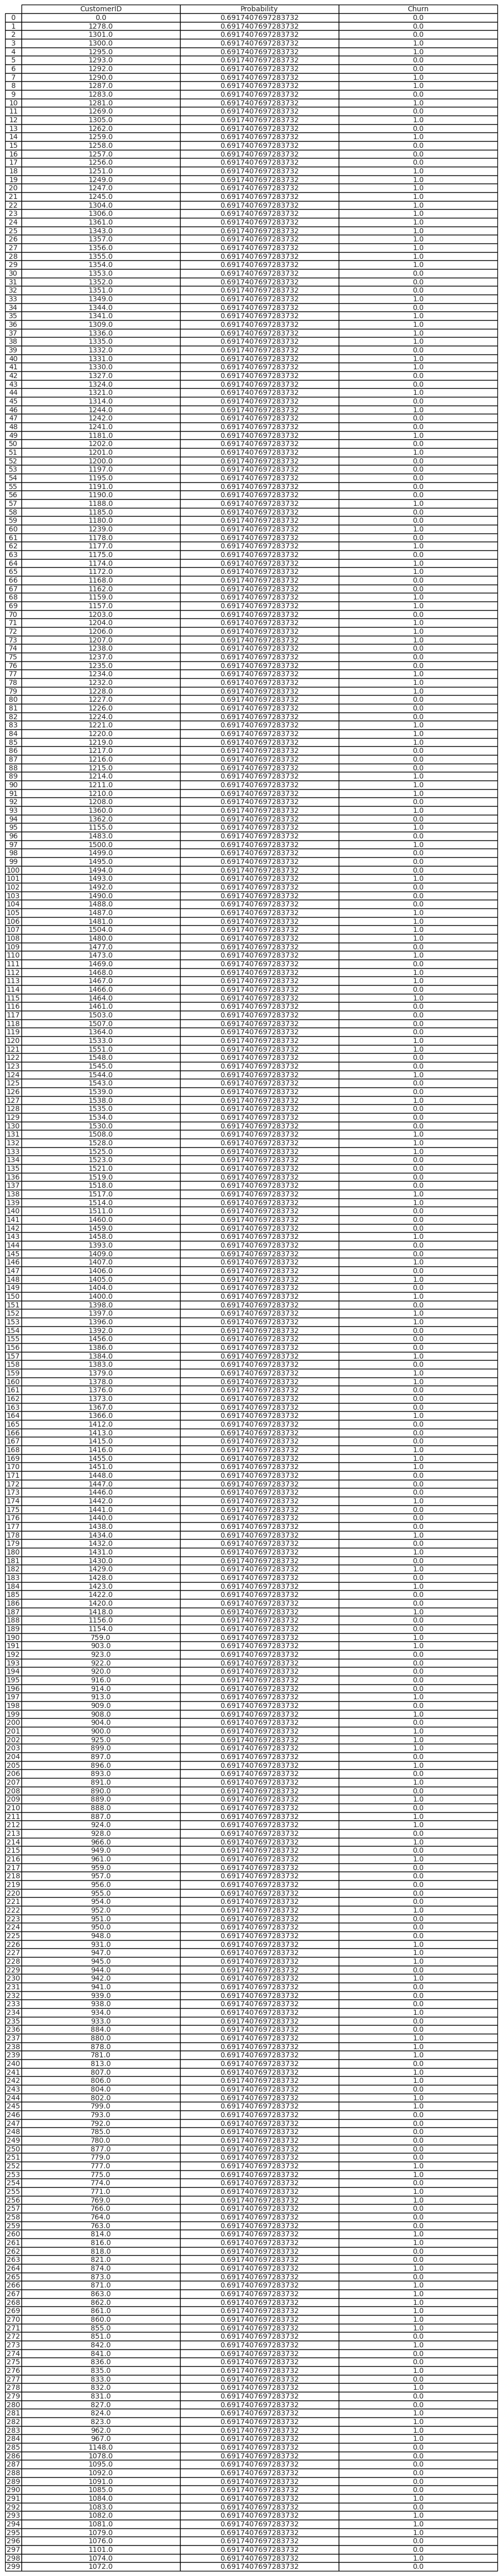

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis('tight')
ax.axis('off')

the_table = table(ax, the_top_300, loc='center', cellLoc = 'center', rowLoc = 'center')

In [ ]:
the_top_300.Churn.sum()

141

141 of 300 Customers predicted well.

Now check the cost to the test set.

In [ ]:
threshold = 0.5
results['PredictedChurn'] = (results['Probability'] >= threshold).astype(int)


fp = ((results['PredictedChurn'] == 1) & (results['Churn'] == 0)).sum()
fn = ((results['PredictedChurn'] == 0) & (results['Churn'] == 1)).sum()
tp = ((results['PredictedChurn'] == 1) & (results['Churn'] == 1)).sum()


cost_per_fp_tp = 10  # Cost for each False and True Positive (gift cost)
cost_per_fn = 64  # Cost for each False Negative (loss per wrong churned customer)

expected_cost = ((fp+tp) * cost_per_fp_tp) + (fn * cost_per_fn)

print(f"The expected cost for Maastricht Telecom for one month is: {expected_cost} euros.")

The expected cost for Maastricht Telecom for one month is: 17030 euros.


# Create the Notebook as pdf

In [20]:
!jupyter nbconvert --to html '/content/drive/MyDrive/Assignment_DM/LAB_Resit/Notebook/Assignment_Lab_Resit.ipynb' --output /content/drive/MyDrive/Assignment_DM/LAB_Resit/Notebook/Assignment_Lab_Resit.html

[NbConvertApp] Converting notebook /content/drive/MyDrive/Assignment_DM/LAB_Resit/Notebook/Assignment_Lab_Resit.ipynb to html
[NbConvertApp] Writing 9672249 bytes to /content/drive/MyDrive/Assignment_DM/LAB_Resit/Notebook/Assignment_Lab_Resit.html


In [21]:
pdfkit.from_file('/content/drive/MyDrive/Assignment_DM/LAB_Resit/Notebook/Assignment_Lab_Resit.html', '/content/drive/MyDrive/Assignment_DM/LAB_Resit/Notebook/Assignment_Lab_Resit.pdf')

True